# 커피 가격: Train EDA와 중장기 시차 살펴보기

2016~2025년 Parquet 12개를 묶고, **2016~2021년만으로 분포·계절성·시차 관계**를 살펴본다. 추가 입력 시차는 0·5·20·60·120거래일, 예측 기간은 7·14·30·120·180·360거래일이다. 가격 피처와 타깃은 Close로 만든다.

앞부분은 데이터 준비 → Train EDA → 시차 진단 순서다. 뒤에는 기존 **5거래일 모델 실험**을 남겼다. 새 시차의 예측 성능을 평가한 결과와 혼동하지 않으려는 구분이다.

예측 기준은 거래일 T의 UTC 23:00. 관측일보다 공개가 늦는 자료는 지연을 두고 붙인다. 과거 수정 전 값은 없는 자료라서, 당시의 데이터 제공 상황을 완전히 재현한 것은 아니다.


In [1]:
import platform
import matplotlib.pyplot as plt

# 한글 폰트 설정
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin":  # macOS
    plt.rc("font", family="AppleGothic")
else:
    # !apt-get -qq install -y fonts-nanum
    plt.rc("font", family="NanumGothic")

plt.rc("axes", unicode_minus=False)


In [2]:
from pathlib import Path
import warnings
import os

os.environ["PYCARET_CUSTOM_LOGGING_PATH"] = os.devnull

import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.sandwich_covariance import S_hac_simple
from catboost import CatBoostRegressor
from IPython.display import HTML, Markdown, display
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd() if (Path.cwd() / "configs").is_dir() else Path.cwd().parent
DATA_DIR = ROOT / "data/processed/2016-01-01_2025-12-31"
SEED = 42
TARGET = "future_log_return_5d"  # 뒤쪽의 기존 모델 실험용
TRAIN_START = pd.Timestamp("2016-01-01")
TRAIN_END = pd.Timestamp("2021-12-31")
INPUT_LAGS = (0, 5, 20, 60, 120)
HORIZONS = (7, 14, 30, 120, 180, 360)

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind", font=plt.rcParams["font.family"][0])
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False, "grid.alpha": 0.25})
pd.set_option("display.max_rows", 25)

region_labels = {
    "br_alta_mogiana": "브라질 알타 모지아나",
    "br_cerrado": "브라질 세라도",
    "br_sul_minas": "브라질 술 지 미나스",
    "co_antioquia": "콜롬비아 안티오키아",
    "co_caldas": "콜롬비아 칼다스",
    "co_huila": "콜롬비아 우일라",
}
source_labels = {
    "coffee": "아라비카 선물 (KC=F)",
    "brl": "브라질 환율 (BRL/USD)",
    "dff": "미국 연방기금금리",
    "dtwexbgs": "광의 달러지수",
    "dcoilwtico": "WTI 현물가격",
    "cot": "투자자 포지션 (COT)",
    **{f"weather_{region}": f"{label} 기상" for region, label in region_labels.items()},
}
feature_labels = {
    "log_return_1d": "1거래일 로그수익률",
    "log_return_5d": "5거래일 로그수익률",
    "log_return_20d": "20거래일 로그수익률",
    "volatility_20d": "20거래일 변동성",
    "brl_close": "브라질 환율 (BRL/USD)",
    "dff": "미국 연방기금금리",
    "dtwexbgs": "광의 달러지수",
    "dcoilwtico": "WTI 현물가격",
    "cot_net_ratio": "매니지드 머니 순매수 비율",
    TARGET: "5거래일 뒤 로그수익률",
}
for region, label in region_labels.items():
    feature_labels[f"{region}_rain_30d"] = f"{label} · 30일 누적 강수량"
    feature_labels[f"{region}_temp_30d"] = f"{label} · 30일 평균 기온"
model_labels = {"Naive Persistence": "가격 유지 (Naive)", "Ridge Regression": "Ridge 회귀", "CatBoost": "CatBoost"}
metric_labels = {
    "MAE": "평균절대오차 (MAE)",
    "RMSE": "제곱평균제곱근오차 (RMSE)",
    "Directional Accuracy (%)": "방향성 정확도 (%)",
}

sources = {}
for path in sorted(DATA_DIR.glob("*.parquet")):
    frame = pd.read_parquet(path).sort_values("date").reset_index(drop=True)
    frame["date"] = pd.to_datetime(frame["date"]).astype("datetime64[ns]")
    assert frame["date"].notna().all() and frame["date"].is_unique, path.name
    sources[path.stem] = frame
assert len(sources) == 12

display(
    pd.DataFrame(
        [
            {
                "source": source_labels[name],
                "rows": len(frame),
                "start": frame.date.min().date(),
                "end": frame.date.max().date(),
                "missing_cells": int(frame.isna().sum().sum()),
            }
            for name, frame in sources.items()
        ]
    )
    .set_index("source")
    .rename_axis("데이터")
    .rename(
        columns={
            "rows": "행 수",
            "start": "시작일",
            "end": "종료일",
            "missing_cells": "결측치 수",
        }
    )
)


,행 수,시작일,종료일,결측치 수
데이터,,,,
브라질 환율 (BRL/USD),2609,2016-01-01,2025-12-31,28
아라비카 선물 (KC=F),2519,2016-01-04,2025-12-31,16
투자자 포지션 (COT),522,2016-01-05,2025-12-30,0
WTI 현물가격,2609,2016-01-01,2025-12-31,108
미국 연방기금금리,3653,2016-01-01,2025-12-31,0
광의 달러지수,2609,2016-01-01,2025-12-31,117
브라질 알타 모지아나 기상,3713,2015-12-02,2026-01-30,0
브라질 세라도 기상,3713,2015-12-02,2026-01-30,0
브라질 술 지 미나스 기상,3713,2015-12-02,2026-01-30,0


### 가공 전에 원자료부터 보기

[EDA 참고 글](https://dacon.io/competitions/official/235871/codeshare/4494)처럼 분포를 먼저 보고 처리할 값을 정한다. 여기서는 학습 기간인 2016~2021년만 확인한다. 단위가 달라서 축을 나눴다. 아래 IQR 범위 밖 값은 **삭제 대상이 아니라 확인할 값**이다. 강수량 0이나 실제로 음수가 된 WTI를 일괄 제거하면 원래 현상을 잃는다.

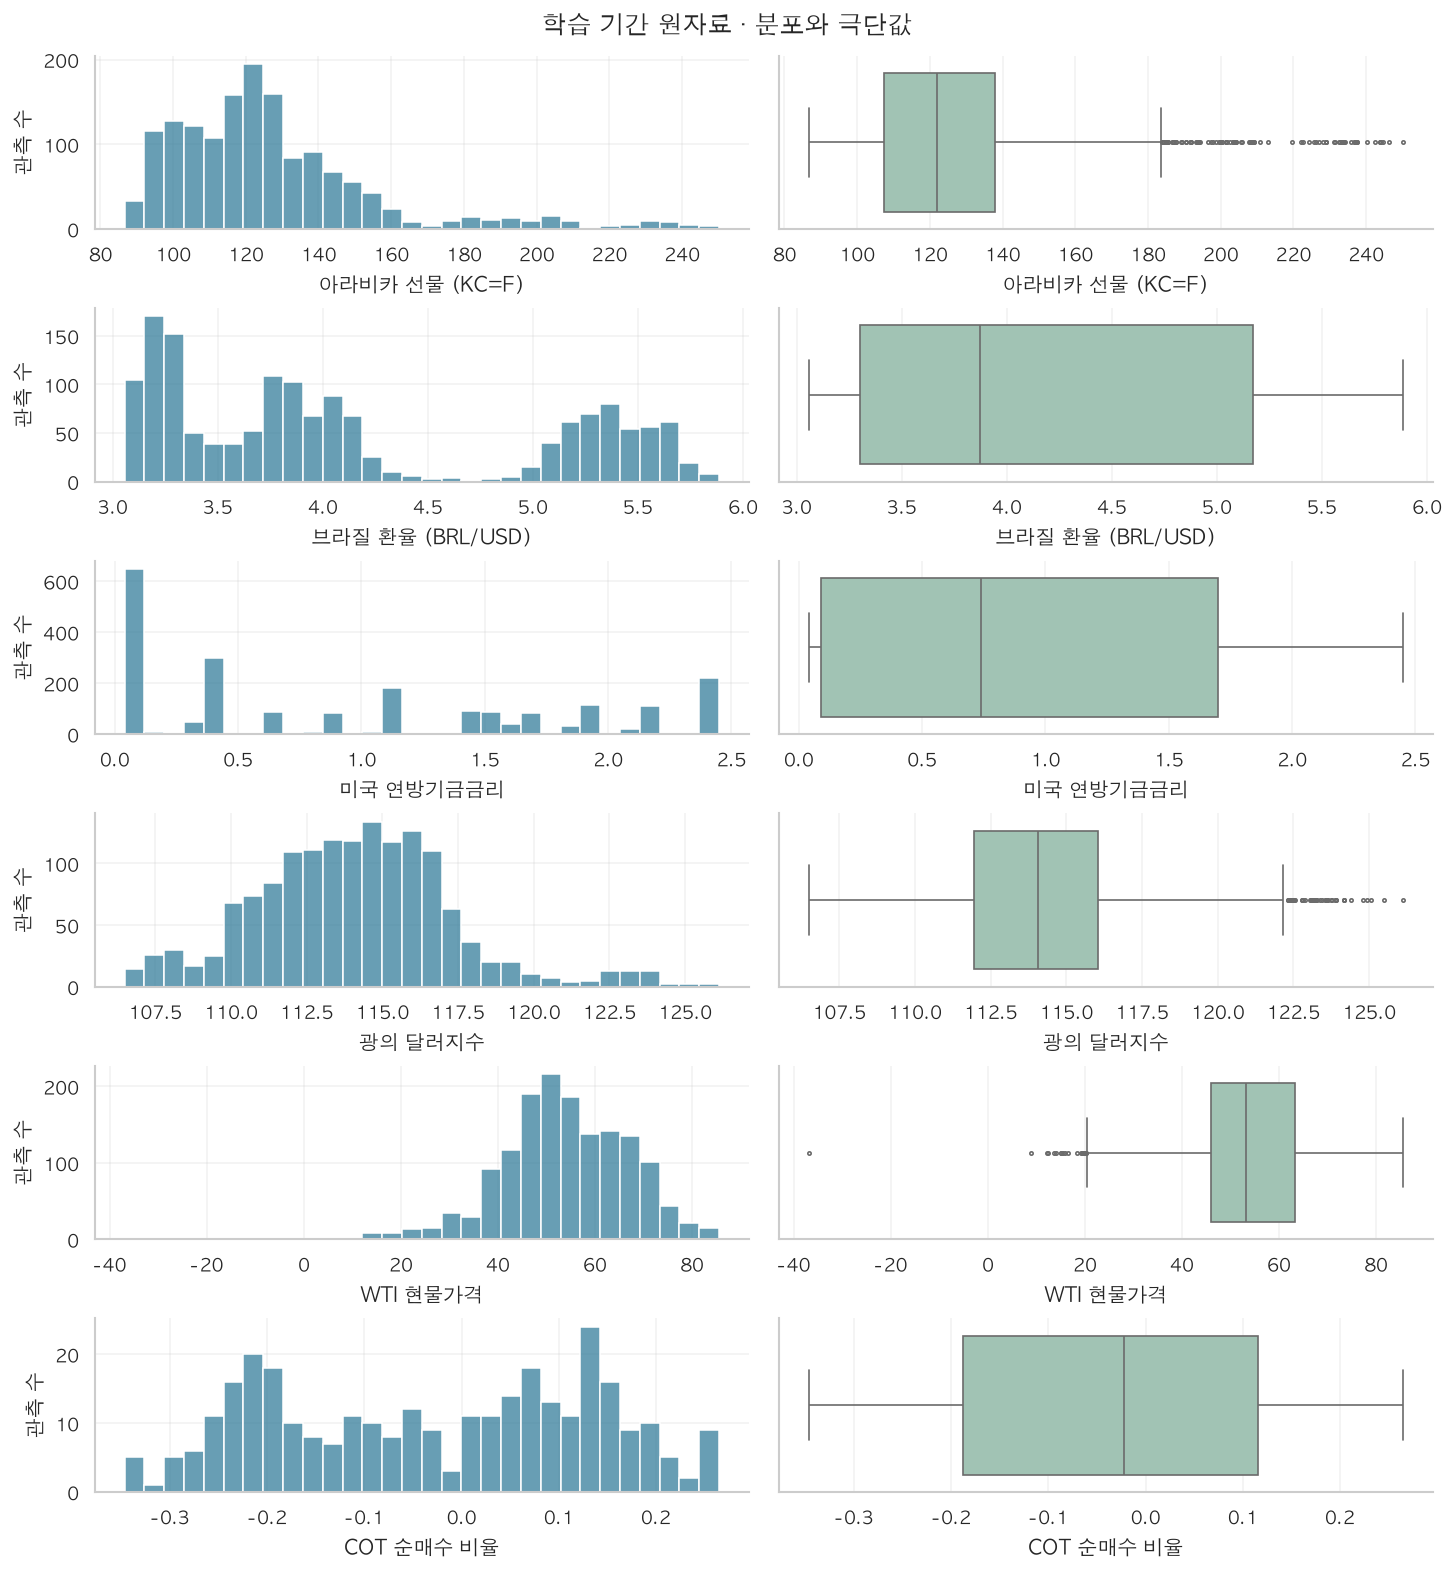

,관측 수,결측 수,0인 값,왜도,IQR 범위 밖
자료,,,,,
아라비카 선물 (KC=F),1509,2,0,1.687,95
브라질 환율 (BRL/USD),1563,3,0,0.544,0
미국 연방기금금리,2192,0,0,0.405,0
광의 달러지수,1492,74,0,0.460,45
WTI 현물가격,1504,62,0,-0.460,19
COT 순매수 비율,313,0,0,-0.080,0


In [3]:
raw_series = {}
for source, column in [("coffee", "close"), ("brl", "close"), ("dff", "value"),
                       ("dtwexbgs", "value"), ("dcoilwtico", "value")]:
    frame = sources[source]
    raw_series[source_labels[source]] = frame.loc[frame.date.between(TRAIN_START, TRAIN_END), column]
raw_cot = sources["cot"].loc[lambda x: x.date.between(TRAIN_START, TRAIN_END)]
raw_series["COT 순매수 비율"] = (raw_cot.managed_money_long - raw_cot.managed_money_short) / raw_cot.open_interest

raw_rows = []
fig, axes = plt.subplots(6, 2, figsize=(12, 13), layout="constrained")
for row, (label, values) in enumerate(raw_series.items()):
    observed = values.dropna()
    q1, q3 = observed.quantile([0.25, 0.75])
    outside = ~observed.between(q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1))
    raw_rows.append({"자료": label, "관측 수": len(observed), "결측 수": values.isna().sum(),
                     "0인 값": observed.eq(0).sum(), "왜도": observed.skew(), "IQR 범위 밖": outside.sum()})
    sns.histplot(x=observed, bins=30, ax=axes[row, 0], color="#357e9b")
    sns.boxplot(x=observed, ax=axes[row, 1], color="#9bc9b5", fliersize=2)
    for ax in axes[row]:
        ax.set(xlabel=label, ylabel="")
    axes[row, 0].set_ylabel("관측 수")
fig.suptitle("학습 기간 원자료 · 분포와 극단값", fontsize=15)
plt.show()
display(pd.DataFrame(raw_rows).set_index("자료").round(3))


FRED 휴일 결측은 뒤에서 공개 지연을 적용한 뒤 과거 값으로 채운다. 커피는 거래일 칸을 먼저 맞추고, 빠진 가격은 그대로 둔다. 기상 원자료에는 결측이 없으므로 30일 집계의 초기 빈칸만 수집 버퍼로 해결한다. 기상 분포와 계절성은 아래 EDA에서 따로 본다.

## 1. 날짜부터 맞추기

결측 행을 먼저 지우면 `shift(-5)`가 원래보다 먼 날짜를 가리킬 수 있다. 그래서 거래일 칸부터 만들고, 빠진 가격은 NaN으로 남긴다. 가격을 앞으로 채워 가짜 수익률을 만들지는 않는다.

미국 공통 휴장일은 NYSE 달력을 바탕으로 잡고, ICE가 개장한 [2018-12-05](https://www.ice.com/publicdocs/clear_us/notices/18-054_IFUS_ICUS_President_HW_Bush.pdf)와 [2025-01-09](https://www.ice.com/publicdocs/clear_us/notices/25-002_ICUS_President_Jimmy_Carter.pdf)는 따로 더했다. Yahoo에 값이 있는 [2023년 추수감사절](https://www.ice.com/publicdocs/futures_us/exchange_notices/ICE_Futures_US_2023Thanksgiving_Holiday_20230921.pdf)과 [2025년 독립기념일](https://www.ice.com/publicdocs/futures_us/exchange_notices/ICE_Futures_US_2025_IndDayHoliday_20250508.pdf)은 Coffee 휴장일이라 제외한다. 아래 표는 이 달력과 원본의 차이다. 원본 Parquet는 바꾸지 않는다.

In [4]:
coffee = sources["coffee"].set_index("date")
sessions = mcal.get_calendar("NYSE").valid_days("2016-01-01", "2025-12-31").tz_localize(None)
sessions = sessions.union(pd.to_datetime(["2018-12-05", "2025-01-09"])).sort_values()
sessions = sessions.as_unit("ns")
excluded = coffee.index.difference(sessions)
missing = sessions.difference(coffee.index)
display(
    pd.concat(
        [
            pd.DataFrame({"date": excluded, "status": "휴장일 행 제외"}),
            pd.DataFrame({"date": missing, "status": "누락 거래일은 결측으로 유지"}),
        ]
    )
    .sort_values("date")
    .reset_index(drop=True)
    .rename(columns={"date": "날짜", "status": "처리 내용"})
)

prices = coffee[["close"]].reindex(sessions).rename_axis("date").reset_index()
log_close = np.log(prices["close"].where(prices["close"] > 0))
PRICE_FEATURES = ["log_return_1d", "log_return_5d", "log_return_20d", "volatility_20d"]
for lag in (1, 5, 20):
    prices[f"log_return_{lag}d"] = log_close.diff(lag)
prices["volatility_20d"] = prices["log_return_1d"].rolling(20, min_periods=20).std()
prices[TARGET] = log_close.shift(-5) - log_close
prices["target_date"] = prices["date"].shift(-5)
prices["future_close"] = prices["close"].shift(-5)
prices["prediction_at"] = prices["date"] + pd.Timedelta(hours=23)  # 시각은 모두 UTC
assert prices["target_date"].iloc[:-5].reset_index(drop=True).equals(prices["date"].iloc[5:].reset_index(drop=True))

,날짜,처리 내용
0,2016-01-18,휴장일 행 제외
1,2016-02-15,휴장일 행 제외
2,2016-10-10,누락 거래일은 결측으로 유지
3,2016-11-11,누락 거래일은 결측으로 유지
4,2018-12-05,누락 거래일은 결측으로 유지
5,2023-11-23,휴장일 행 제외
6,2025-05-26,휴장일 행 제외
7,2025-06-19,휴장일 행 제외
8,2025-07-04,휴장일 행 제외


## 2. 관측일과 쓸 수 있는 날짜 구분하기

날짜가 같다고 바로 붙이기에는 공개 주기가 다르다. [광의 달러지수는 전주 자료를 주 단위로 공개](https://www.federalreserve.gov/releases/h10/about.htm)하고, [COT는 보통 화요일 포지션을 금요일에 공개](https://www.cftc.gov/MarketReports/CommitmentsofTraders/ReleaseSchedule/index.htm)한다. [NASA 기상 자료도 며칠 늦게 들어오며](https://power.larc.nasa.gov/docs/faqs/data/), [나중에 자료가 교체될 수 있다](https://power.larc.nasa.gov/docs/methodology/data/sources/).

아래 일수는 정확한 발표시각 대신 여유를 둔 **달력일 기준 가정**이다. BRL 1일, DFF 4일, 달러지수 14일, WTI 7일, 기상 4일, COT 7일. FRED는 과거 방향으로만 채우고, `merge_asof(direction="backward")`로 T 이전에 사용 가능한 마지막 값을 가져온다.

COT의 큰 발표 지연은 [2019년 재개 일정](https://www.cftc.gov/PressRoom/PressReleases/7864-19)과 [2023·2025년 특별 공지](https://www.cftc.gov/MarketReports/CommitmentsofTraders/HistoricalSpecialAnnouncements/index.htm)를 반영했다. 해당 보고서는 기본 지연일과 공지된 발표일 다음 날 중 더 늦은 날부터 사용한다.

### 기상 원자료는 멀쩡한데 왜 NaN이 생겼을까?

2016년 1월부터 잘라서 30일 평균을 계산하면 첫 29일에는 관측값이 모자란다. 우일라의 기온을 예로 들어 버퍼 전후를 다시 계산해 봤다. 아래는 **기상 관측일 기준 비교**다. 모델에는 이후 4일의 공개 지연을 적용한다.

2015년 12월 관측값을 함께 넣으면 1월 집계에도 30일이 채워진다. 미래 값을 당겨 채우거나 계절을 무시한 중앙값을 넣을 필요가 없었다.

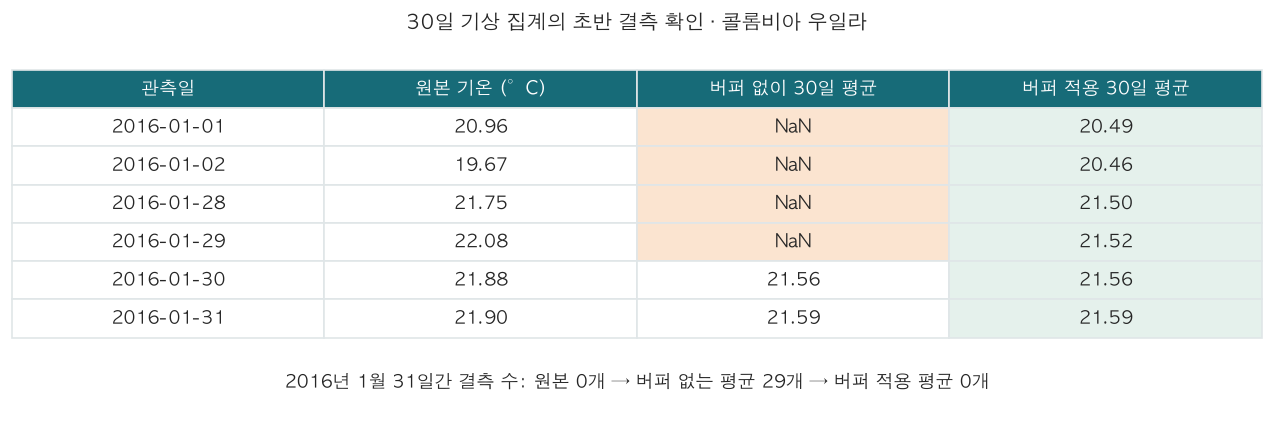

In [5]:
daily_temp = sources["weather_co_huila"].set_index("date")["T2M"].asfreq("D")
january_temp = daily_temp.loc["2016-01-01":"2016-01-31"]
before_buffer = january_temp.rolling("30D", min_periods=30).mean()
after_buffer = daily_temp.rolling("30D", min_periods=30).mean().reindex(january_temp.index)
assert january_temp.notna().all()
assert before_buffer.isna().sum() == 29 and after_buffer.notna().all()

warmup_comparison = pd.DataFrame(
    {
        "원본 기온 (°C)": january_temp,
        "버퍼 없이 30일 평균": before_buffer,
        "버퍼 적용 30일 평균": after_buffer,
    }
)
# 시작일과 30개 관측값이 처음 쌓이는 경계를 함께 본다.
sample = warmup_comparison.loc[
    pd.to_datetime(["2016-01-01", "2016-01-02", "2016-01-28", "2016-01-29", "2016-01-30", "2016-01-31"])
].map(lambda value: "NaN" if pd.isna(value) else f"{value:.2f}")
sample.insert(0, "관측일", sample.index.strftime("%Y-%m-%d"))
fig, ax = plt.subplots(figsize=(10.5, 3.4), layout="constrained")
ax.axis("off")
ax.set_title("30일 기상 집계의 초반 결측 확인 · 콜롬비아 우일라", pad=14)
table = ax.table(cellText=sample.values, colLabels=sample.columns, cellLoc="center", bbox=[0, 0.2, 1, 0.75])
table.auto_set_font_size(False)
table.set_fontsize(11)
for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor("#E0E6E8")
    if row == 0:
        cell.set_facecolor("#176B78")
        cell.get_text().set_color("white")
    elif cell.get_text().get_text() == "NaN":
        cell.set_facecolor("#FBE4D0")
    elif column == 3:
        cell.set_facecolor("#E5F1EC")
ax.text(
    0.5,
    0.06,
    f"2016년 1월 31일간 결측 수: 원본 {january_temp.isna().sum()}개 → 버퍼 없는 평균 {before_buffer.isna().sum()}개 → 버퍼 적용 평균 {after_buffer.isna().sum()}개",
    ha="center",
    transform=ax.transAxes,
    fontsize=11,
)
plt.show()


In [6]:
LAG_DAYS = {"brl": 1, "dff": 4, "dtwexbgs": 14, "dcoilwtico": 7, "weather": 4, "cot": 7}
joined = prices.copy()
FEATURES = PRICE_FEATURES.copy()
join_checks = []


def join_source(left, right, name, columns, lag_days):
    right = right.copy()
    if "available_at" not in right:
        right["available_at"] = right["date"] + pd.Timedelta(days=lag_days)
    observed, available = f"{name}_observed_at", f"{name}_available_at"
    right = right.rename(columns={"date": observed, "available_at": available})
    result = pd.merge_asof(
        left.sort_values("prediction_at"),
        right[[observed, available, *columns]].sort_values(available),
        left_on="prediction_at",
        right_on=available,
        direction="backward",
    )
    matched = result[available].notna()
    assert len(result) == len(left)
    assert (result.loc[matched, available] <= result.loc[matched, "prediction_at"]).all()
    assert (result.loc[matched, observed] <= result.loc[matched, available]).all()
    join_checks.append({"source": name, "matched_rows": int(matched.sum()), "total_rows": len(result)})
    return result


brl = sources["brl"][["date", "close"]].rename(columns={"close": "brl_close"}).dropna()
joined = join_source(joined, brl, "brl", ["brl_close"], LAG_DAYS["brl"])
FEATURES.append("brl_close")
for name in ("dff", "dtwexbgs", "dcoilwtico"):
    fred = sources[name][["date", "value"]].copy()
    fred[name] = fred.pop("value").ffill()  # 휴일의 빈칸도 이전 값만 사용한다
    joined = join_source(joined, fred, name, [name], LAG_DAYS[name])
    FEATURES.append(name)

for name, frame in sources.items():
    if not name.startswith("weather_"):
        continue
    region = name.removeprefix("weather_")
    daily = frame.set_index("date").asfreq("D")
    rain, temp = f"{region}_rain_30d", f"{region}_temp_30d"
    # 앞뒤 30일 버퍼를 포함해 계산한다. 현재 관측일까지의 30달력일만 쓴다.
    weather = pd.DataFrame(
        {
            rain: daily["PRECTOTCORR"].rolling("30D", min_periods=30).sum(),
            temp: daily["T2M"].rolling("30D", min_periods=30).mean(),
        }
    ).reset_index()
    joined = join_source(joined, weather, name, [rain, temp], LAG_DAYS["weather"])
    FEATURES.extend([rain, temp])

In [7]:
cot = sources["cot"].copy()
cot["cot_net_ratio"] = (cot["managed_money_long"] - cot["managed_money_short"]) / cot["open_interest"].replace(
    0, np.nan
)
cot["available_at"] = cot["date"] + pd.Timedelta(days=LAG_DAYS["cot"])

# 보고 기준일 순서의 발표 일정. 발표가 멈춘 동안 새 포지션을 미리 쓰지 않는다.
cot_release_delays = [
    (
        "2018-12-24",
        "2019-03-05",
        "2019-02-01 2019-02-05 2019-02-08 2019-02-12 2019-02-15 2019-02-19 "
        "2019-02-22 2019-02-26 2019-03-01 2019-03-05 2019-03-08",
    ),
    ("2023-01-31", "2023-03-14", "2023-02-24 2023-03-03 2023-03-08 2023-03-10 2023-03-14 2023-03-16 2023-03-21"),
    (
        "2025-09-30",
        "2025-12-23",
        "2025-11-19 2025-11-21 2025-11-25 2025-12-02 2025-12-05 2025-12-09 "
        "2025-12-10 2025-12-12 2025-12-15 2025-12-17 2025-12-19 2025-12-23 2025-12-29",
    ),
]
for start, end, release_days in cot_release_delays:
    mask = cot["date"].between(start, end)
    release_after = pd.to_datetime(release_days.split()) + pd.Timedelta(days=1)
    assert mask.sum() == len(release_after)
    cot.loc[mask, "available_at"] = np.maximum(cot.loc[mask, "available_at"].to_numpy(), release_after.to_numpy())

joined = join_source(joined, cot, "cot", ["cot_net_ratio"], LAG_DAYS["cot"])
FEATURES.append("cot_net_ratio")
assert len(FEATURES) == len(set(FEATURES)) == 21
assert TARGET not in FEATURES and "future_close" not in FEATURES
# 가격 피처의 초기 구간과 정답이 없는 행만 제외한다. 기상은 버퍼로 집계해 대치하지 않는다.
data = joined.dropna(subset=["close", "target_date", TARGET, *PRICE_FEATURES]).copy()
assert np.isfinite(data[FEATURES].to_numpy()).all(), "피처 결측이 생기면 원인을 먼저 확인한다."
display(
    pd.DataFrame(join_checks)
    .set_index("source")
    .rename(index=source_labels)
    .rename_axis("데이터")
    .rename(columns={"matched_rows": "연결된 행 수", "total_rows": "전체 행 수"})
)

,연결된 행 수,전체 행 수
데이터,,
브라질 환율 (BRL/USD),2516,2516
미국 연방기금금리,2515,2516
광의 달러지수,2507,2516
WTI 현물가격,2512,2516
브라질 알타 모지아나 기상,2516,2516
브라질 세라도 기상,2516,2516
브라질 술 지 미나스 기상,2516,2516
콜롬비아 안티오키아 기상,2516,2516
콜롬비아 칼다스 기상,2516,2516


## 3. Train에서 분포와 관계 살펴보기

EDA는 **2016~2021년**으로 제한한다. 아래 분할 표의 Validation·Test는 뒤쪽의 기존 5일 실험에 쓰는 구간이다. EDA의 평균·분포·상관·회귀에는 사용하지 않는다.

기상 원자료에는 결측이 없었다. 30일 집계를 위해 2015년 12월 버퍼를 받아 대치를 없앴다. 뒤쪽 기상 버퍼는 과거 예측에 쓰지 않는다. 가격의 20거래일 피처와 5일 정답까지 있는 Train 표본은 2월부터 시작한다.

먼저 종가와의 관계를 보고 미래 수익률로 바꾸면 얼마나 달라지는지 확인한다. 유의한 관계를 찾아야 성공하는 분석은 아니다.


In [8]:
VAL_START = pd.Timestamp("2022-01-01")
TEST_START = pd.Timestamp("2024-01-01")
TEST_END = pd.Timestamp("2025-12-31")
train = data.loc[(data["date"] < VAL_START) & (data["target_date"] < VAL_START)]
val = data.loc[data["date"].between(VAL_START, TEST_START, inclusive="left") & (data["target_date"] < TEST_START)]
dev = data.loc[(data["date"] < TEST_START) & (data["target_date"] < TEST_START)]
test = data.loc[data["date"].between(TEST_START, TEST_END) & (data["target_date"] <= TEST_END)]
assert train["target_date"].max() < val["date"].min()
assert dev["target_date"].max() < test["date"].min()
assert set(dev.index).isdisjoint(test.index)

display(
    pd.DataFrame(
        [
            {
                "split": name,
                "rows": len(frame),
                "first_origin": frame.date.min().date(),
                "last_origin": frame.date.max().date(),
                "last_target": frame.target_date.max().date(),
            }
            for name, frame in [("학습", train), ("검증", val), ("재학습 (2016~2023)", dev), ("테스트", test)]
        ]
    )
    .set_index("split")
    .rename_axis("구간")
    .rename(
        columns={
            "rows": "행 수",
            "first_origin": "첫 예측 기준일",
            "last_origin": "마지막 예측 기준일",
            "last_target": "마지막 정답 날짜",
        }
    )
)
eda_train = train.copy()
assert eda_train.date.between(TRAIN_START, TRAIN_END).all()
assert eda_train.target_date.le(TRAIN_END).all()

eda_columns = [*PRICE_FEATURES, "cot_net_ratio", TARGET]
display(
    eda_train[eda_columns]
    .describe(percentiles=[0.05, 0.5, 0.95])
    .T.round(4)
    .rename(
        index=feature_labels,
        columns={
            "count": "관측 수",
            "mean": "평균",
            "std": "표준편차",
            "min": "최솟값",
            "5%": "5% 분위",
            "50%": "중앙값",
            "95%": "95% 분위",
            "max": "최댓값",
        },
    )
    .rename_axis("피처")
)
weather_features = [name for name in FEATURES if name.endswith(("_rain_30d", "_temp_30d"))]
assert joined[weather_features].notna().all().all()
print(f"기상 피처 결측: {int(joined[weather_features].isna().sum().sum())}개 | 대치한 값: 0개")


,행 수,첫 예측 기준일,마지막 예측 기준일,마지막 정답 날짜
구간,,,,
학습,1422,2016-02-02,2021-12-23,2021-12-31
검증,496,2022-01-03,2023-12-21,2023-12-29
재학습 (2016~2023),1923,2016-02-02,2023-12-21,2023-12-29
테스트,498,2024-01-02,2025-12-23,2025-12-31


,관측 수,평균,표준편차,최솟값,5% 분위,중앙값,95% 분위,최댓값
피처,,,,,,,,
1거래일 로그수익률,1422.0,0.0005,0.0198,-0.0902,-0.0313,0.0000,0.0322,0.0956
5거래일 로그수익률,1422.0,0.0028,0.0447,-0.1844,-0.0630,0.0000,0.0769,0.2915
20거래일 로그수익률,1422.0,0.0116,0.0831,-0.2585,-0.1121,0.0027,0.1549,0.2787
20거래일 변동성,1422.0,0.0188,0.0059,0.0078,0.0117,0.0174,0.0279,0.0467
매니지드 머니 순매수 비율,1422.0,-0.0361,0.1570,-0.3471,-0.2756,-0.0261,0.1851,0.2653
5거래일 뒤 로그수익률,1422.0,0.0024,0.0448,-0.1844,-0.0631,-0.0005,0.0769,0.2915


기상 피처 결측: 0개 | 대치한 값: 0개


### 분포와 계절성

단위가 다른 변수를 한 축에 올리면 작은 값은 잘 보이지 않는다. 가격·환율·거시지표는 축을 나누고, 기상은 같은 단위끼리 묶었다. 박스 밖 점은 지우지 않는다. 수익률의 큰 움직임이나 WTI 음수 관측도 먼저 원자료와 맥락을 확인할 대상이다.

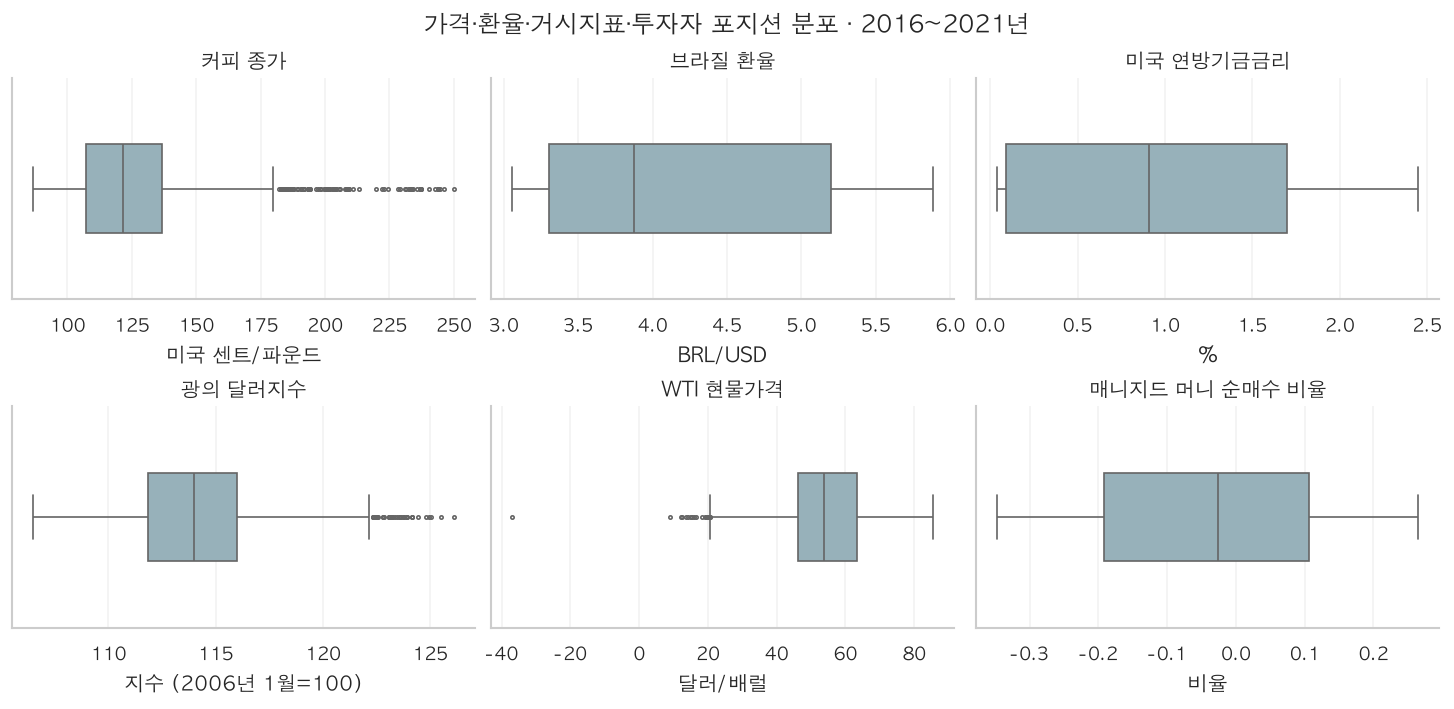

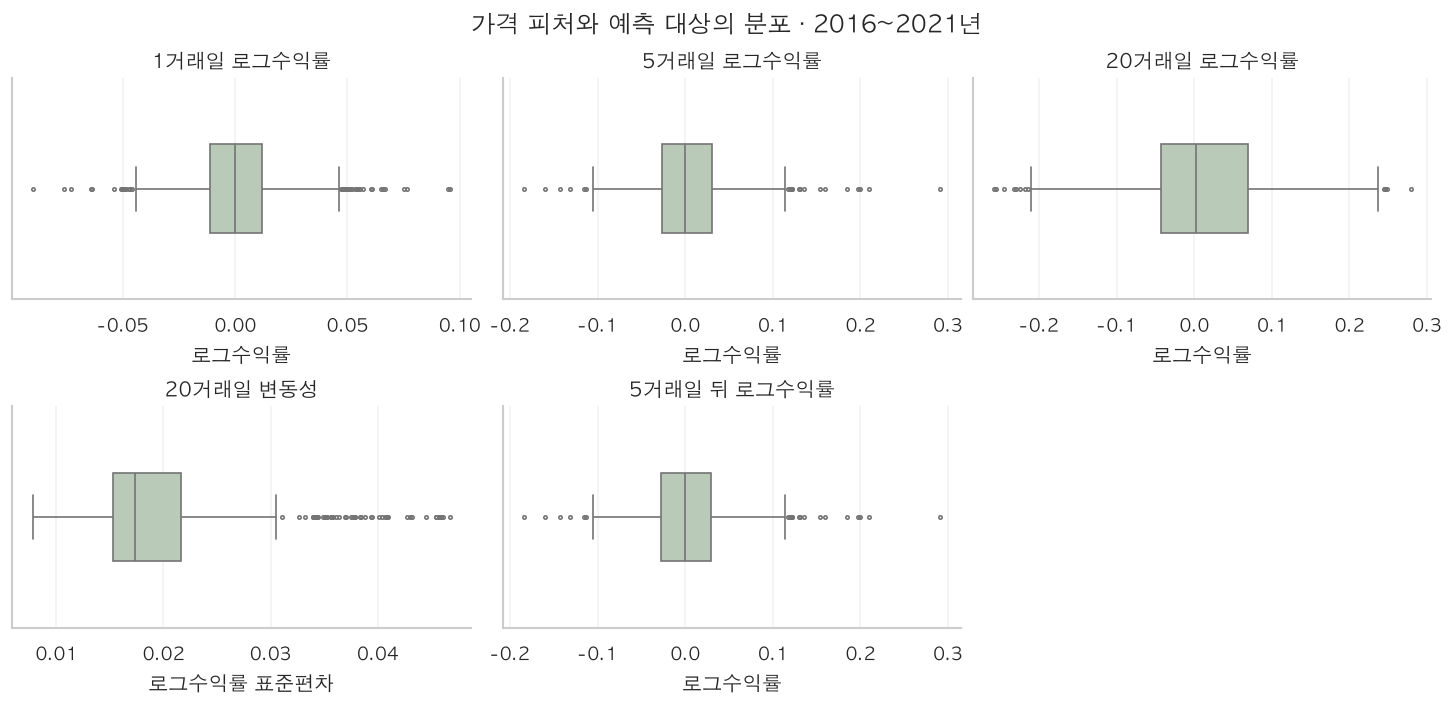

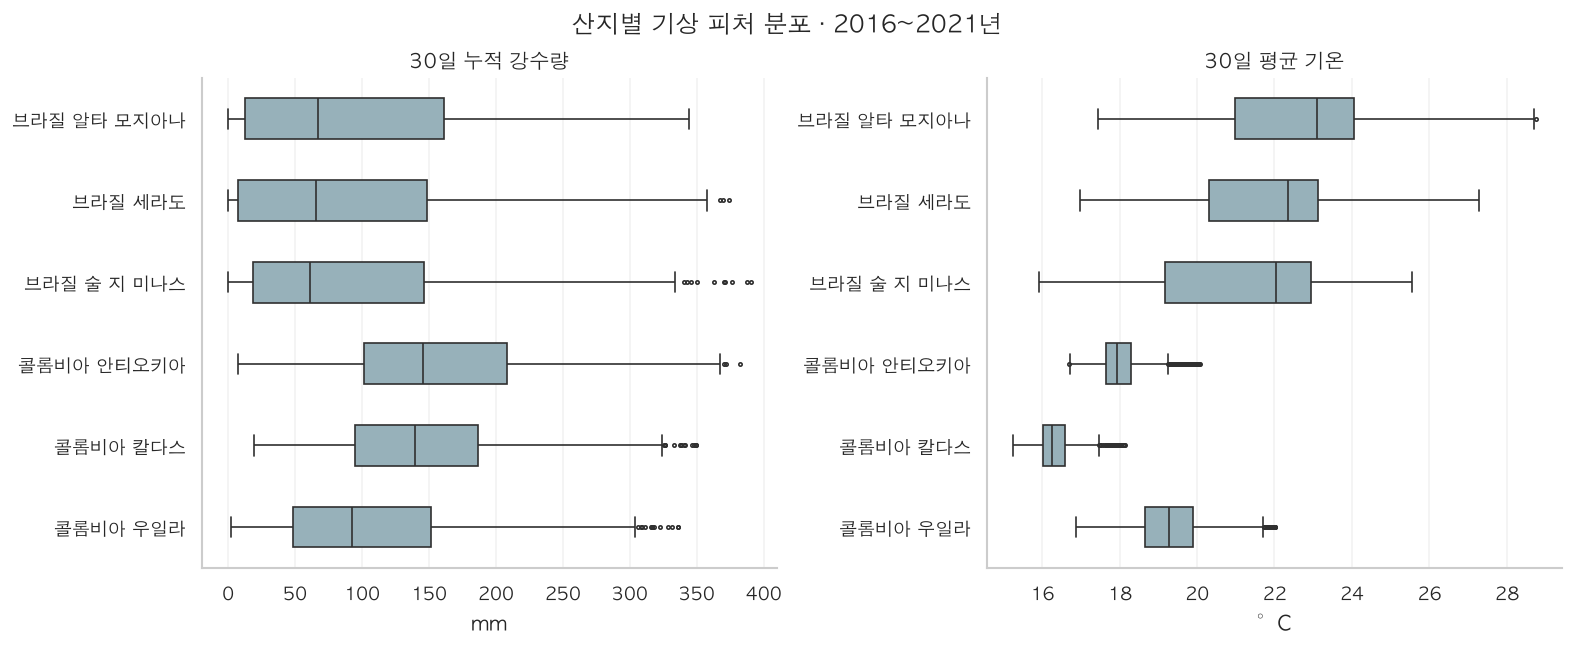

In [9]:
short_labels = {
    **feature_labels,
    "close": "커피 종가",
    "brl_close": "브라질 환율",
    "dff": "미국 연방기금금리",
    "dtwexbgs": "광의 달러지수",
    "dcoilwtico": "WTI 현물가격",
    "cot_net_ratio": "매니지드 머니 순매수 비율",
}
for region, label in region_labels.items():
    short_labels[f"{region}_rain_30d"] = label + " 강수량"
    short_labels[f"{region}_temp_30d"] = label + " 기온"
units = {
    "close": "미국 센트/파운드",
    "brl_close": "BRL/USD",
    "dff": "%",
    "dtwexbgs": "지수 (2006년 1월=100)",
    "dcoilwtico": "달러/배럴",
    "cot_net_ratio": "비율",
    **{name: "로그수익률" for name in [*PRICE_FEATURES[:3], TARGET]},
    "volatility_20d": "로그수익률 표준편차",
    **{name: "mm" if name.endswith("_rain_30d") else "°C" for name in weather_features},
}
level_features = ["close", "brl_close", "dff", "dtwexbgs", "dcoilwtico", "cot_net_ratio"]
fig, axes = plt.subplots(2, 3, figsize=(12, 5.8), layout="constrained")
for ax, name in zip(axes.flat, level_features):
    sns.boxplot(x=eda_train[name], ax=ax, color="#91B4C0", width=0.4, fliersize=2)
    ax.set(title=short_labels[name], xlabel=units[name], ylabel="")
fig.suptitle("가격·환율·거시지표·투자자 포지션 분포 · 2016~2021년")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 5.8), layout="constrained")
for ax, name in zip(axes.flat, [*PRICE_FEATURES, TARGET]):
    sns.boxplot(x=eda_train[name], ax=ax, color="#B6CDB5", width=0.4, fliersize=2)
    ax.set(title=short_labels[name], xlabel=units[name], ylabel="")
axes.flat[-1].set_visible(False)
fig.suptitle("가격 피처와 예측 대상의 분포 · 2016~2021년")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3), layout="constrained")
for ax, suffix, title, unit in zip(
    axes, ["rain_30d", "temp_30d"], ["30일 누적 강수량", "30일 평균 기온"], ["mm", "°C"]
):
    columns = [f"{region}_{suffix}" for region in region_labels]
    table = eda_train[columns].rename(columns={f"{region}_{suffix}": label for region, label in region_labels.items()})
    sns.boxplot(data=table, orient="h", ax=ax, color="#91B4C0", fliersize=2, width=0.5)
    ax.set(title=title, xlabel=unit, ylabel="")
fig.suptitle("산지별 기상 피처 분포 · 2016~2021년")
plt.show()


### 수익률의 꼬리는 정규분포보다 두꺼울까?

1·5·20거래일 수익률과 예측 대상인 미래 5거래일 수익률의 **왜도·첨도·Jarque–Bera(JB)**를 비교한다. 정규분포의 기준은 왜도 0, 첨도 3, 초과첨도 0이다. JB는 왜도와 첨도를 함께 확인하므로, 작은 p값만 보고 팻 테일이라고 결론 내리지 않고 초과첨도와 Q–Q plot도 같이 본다.

[SciPy의 JB 설명](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.jarque_bera.html)은 2,000개보다 큰 표본에서의 근사를 안내한다. 여기서는 2,000개 미만의 Train 표본을 쓰고, 5·20일 수익률은 이웃한 구간이 겹친다. 아래 p값은 독립·대표본 가정하의 탐색적 근사로 읽는다.


,표본 수,왜도,첨도,초과첨도,JB 통계량,JB p값 (근사),정규성 · 5% 기준
수익률,,,,,,,
1거래일 로그수익률,"1,422",0.197,4.602,1.602,161.343,9.22e-36,기각 (근사)
5거래일 로그수익률,"1,422",0.494,5.178,2.178,338.932,2.52e-74,기각 (근사)
20거래일 로그수익률,"1,422",0.163,3.068,0.068,6.538,3.80e-02,기각 (근사)
5거래일 뒤 로그수익률,"1,422",0.511,5.162,2.162,338.769,2.74e-74,기각 (근사)


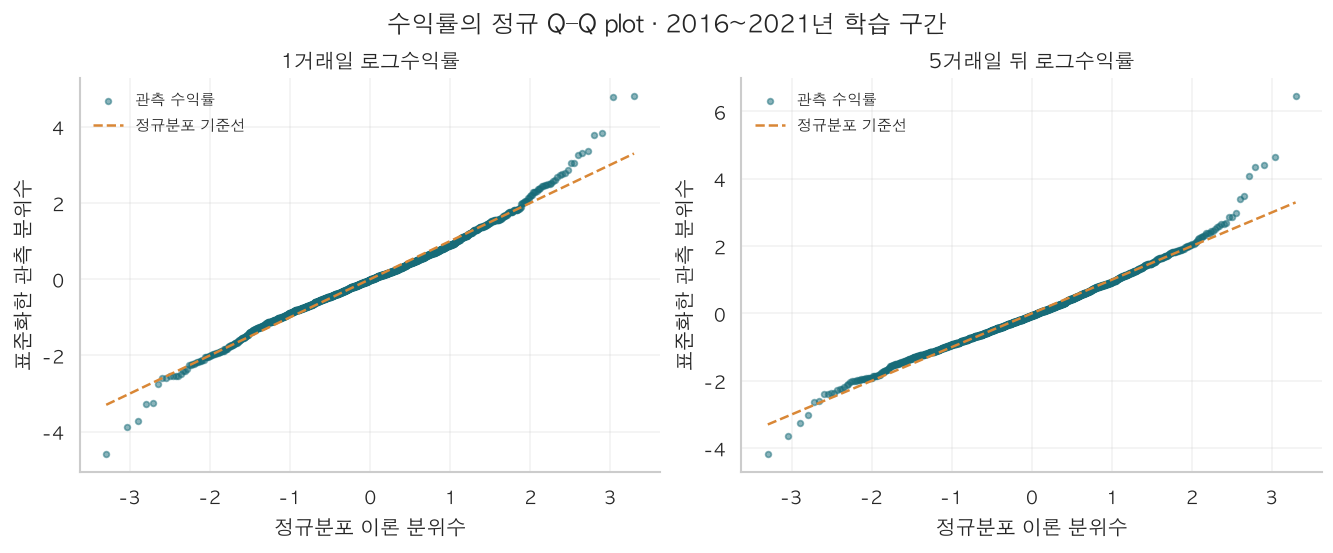

In [10]:
return_columns = ["log_return_1d", "log_return_5d", "log_return_20d", TARGET]
normality_rows = []
for name in return_columns:
    values = eda_train[name].to_numpy()
    jb = stats.jarque_bera(values)
    excess = stats.kurtosis(values, fisher=True, bias=True)
    normality_rows.append(
        {
            "수익률": feature_labels[name],
            "표본 수": len(values),
            "왜도": stats.skew(values, bias=True),
            "첨도": excess + 3,
            "초과첨도": excess,
            "JB 통계량": jb.statistic,
            "JB p값 (근사)": jb.pvalue,
            "정규성 · 5% 기준": "기각 (근사)" if jb.pvalue < 0.05 else "기각 못함",
        }
    )
normality = pd.DataFrame(normality_rows).set_index("수익률")
display(
    normality.style.format(
        {
            "표본 수": "{:,.0f}",
            "왜도": "{:.3f}",
            "첨도": "{:.3f}",
            "초과첨도": "{:.3f}",
            "JB 통계량": "{:.3f}",
            "JB p값 (근사)": "{:.2e}",
        }
    )
)

# 같은 평균·분산의 정규분포와 비교한다. 양 끝이 기준선에서 얼마나 벌어지는지 본다.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
for ax, name in zip(axes, ["log_return_1d", TARGET]):
    values = eda_train[name]
    standardized = (values - values.mean()) / values.std(ddof=0)
    theoretical, observed = stats.probplot(standardized, dist="norm", fit=False)
    ax.scatter(theoretical, observed, s=12, alpha=0.5, color="#176B78", label="관측 수익률")
    ax.plot(theoretical, theoretical, color="#D98736", linestyle="--", label="정규분포 기준선")
    ax.set(title=feature_labels[name], xlabel="정규분포 이론 분위수", ylabel="표준화한 관측 분위수")
    ax.legend(frameon=False, fontsize=9)
fig.suptitle("수익률의 정규 Q–Q plot · 2016~2021년 학습 구간")
plt.show()


In [11]:
tail_row = normality.loc[feature_labels[TARGET]]
display(Markdown(
    f"미래 5일 수익률의 초과첨도는 **{tail_row['초과첨도']:.3f}**, "
    f"JB 근사 p값은 **{tail_row['JB p값 (근사)']:.2e}**다. "
    "표본의 꼬리 모양과 Q–Q plot을 같이 본다. 겹치는 수익률이라 p값만으로 분포를 확정하지 않는다."
))


미래 5일 수익률의 초과첨도는 **2.162**, JB 근사 p값은 **2.74e-74**다. 표본의 꼬리 모양과 Q–Q plot을 같이 본다. 겹치는 수익률이라 p값만으로 분포를 확정하지 않는다.

### 가격 수준과 5거래일 수익률의 정상성

정규성은 분포의 모양이고, 정상성은 시간이 지나도 평균·공분산 같은 성질이 일정한가의 문제다. **[ADF](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html)의 귀무가설은 단위근이 있다는 것**, **[KPSS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html)의 귀무가설은 정상성**이다. 두 검정은 p값을 읽는 방향이 반대다.

누락된 거래일을 지운 뒤 앞뒤를 이어 붙이지 않으려고, Train 기간 중 종가·과거 5일 수익률·미래 5일 수익률이 모두 있는 가장 긴 연속 거래일 구간을 사용한다. 상수항을 포함하고, ADF 지연 수는 AIC, KPSS 지연 수는 자동 선택으로 고정한다. 과거 수익률은 `ln(Pt / Pt-5)`, 예측 타깃은 `ln(Pt+5 / Pt)`다.


In [12]:
def longest_complete_block(frame, columns):
    complete = np.isfinite(frame[columns]).all(axis=1)
    breaks = ~complete | frame.index.to_series().diff().ne(1)
    blocks = breaks.cumsum()
    lengths = complete.groupby(blocks).sum()
    sample = frame.loc[complete & blocks.eq(lengths.idxmax())]
    assert len(sample) and np.all(np.diff(sample.index) == 1)
    return sample


def stationarity_row(sample, name, label):
    values = sample[name]
    adf = adfuller(values, regression="c", autolag="AIC", result_object=True)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        kp = kpss(values, regression="c", nlags="auto", result_object=True)
    kp_p = "<0.01" if kp.statistic > kp.critical_values["1%"] else (
        ">0.10" if kp.statistic < kp.critical_values["10%"] else f"{kp.pvalue:.3f}"
    )
    return {
        "시계열": label, "표본 수": len(sample),
        "시작일": sample.date.min().date(), "종료일": sample.date.max().date(),
        "ADF 통계량": adf.statistic, "ADF p값": adf.pvalue, "ADF 지연 수": adf.lags,
        "KPSS 통계량": kp.statistic, "KPSS p값": kp_p, "KPSS 지연 수": kp.lags,
    }


stationarity_columns = ["close", "log_return_5d", TARGET]
calendar_train = prices.loc[prices.date.between(TRAIN_START, TRAIN_END) & prices.target_date.le(TRAIN_END)]
stationarity_sample = longest_complete_block(calendar_train, stationarity_columns)
stationarity = pd.DataFrame([
    stationarity_row(stationarity_sample, name, short_labels[name]) for name in stationarity_columns
]).set_index("시계열")
display(stationarity.style.format({"ADF 통계량": "{:.3f}", "ADF p값": "{:.2e}", "KPSS 통계량": "{:.3f}"}))


,표본 수,시작일,종료일,ADF 통계량,ADF p값,ADF 지연 수,KPSS 통계량,KPSS p값,KPSS 지연 수
시계열,,,,,,,,,
커피 종가,764,2018-12-13,2021-12-23,0.869,9.93e-01,5,3.019,<0.01,17
5거래일 로그수익률,764,2018-12-13,2021-12-23,-5.018,2.04e-05,20,0.225,>0.10,13
5거래일 뒤 로그수익률,764,2018-12-13,2021-12-23,-4.998,2.24e-05,20,0.192,>0.10,13


In [13]:
display(Markdown(
    f"종가의 ADF p값은 **{stationarity.loc[short_labels['close'], 'ADF p값']:.3f}**, "
    f"미래 5일 수익률은 **{stationarity.loc[short_labels[TARGET], 'ADF p값']:.2e}**였다. "
    "KPSS와 함께 읽되 이 구간의 검정 결과를 모든 기간의 정상성 보장으로 옮기지는 않는다."
))


종가의 ADF p값은 **0.993**, 미래 5일 수익률은 **2.24e-05**였다. KPSS와 함께 읽되 이 구간의 검정 결과를 모든 기간의 정상성 보장으로 옮기지는 않는다.

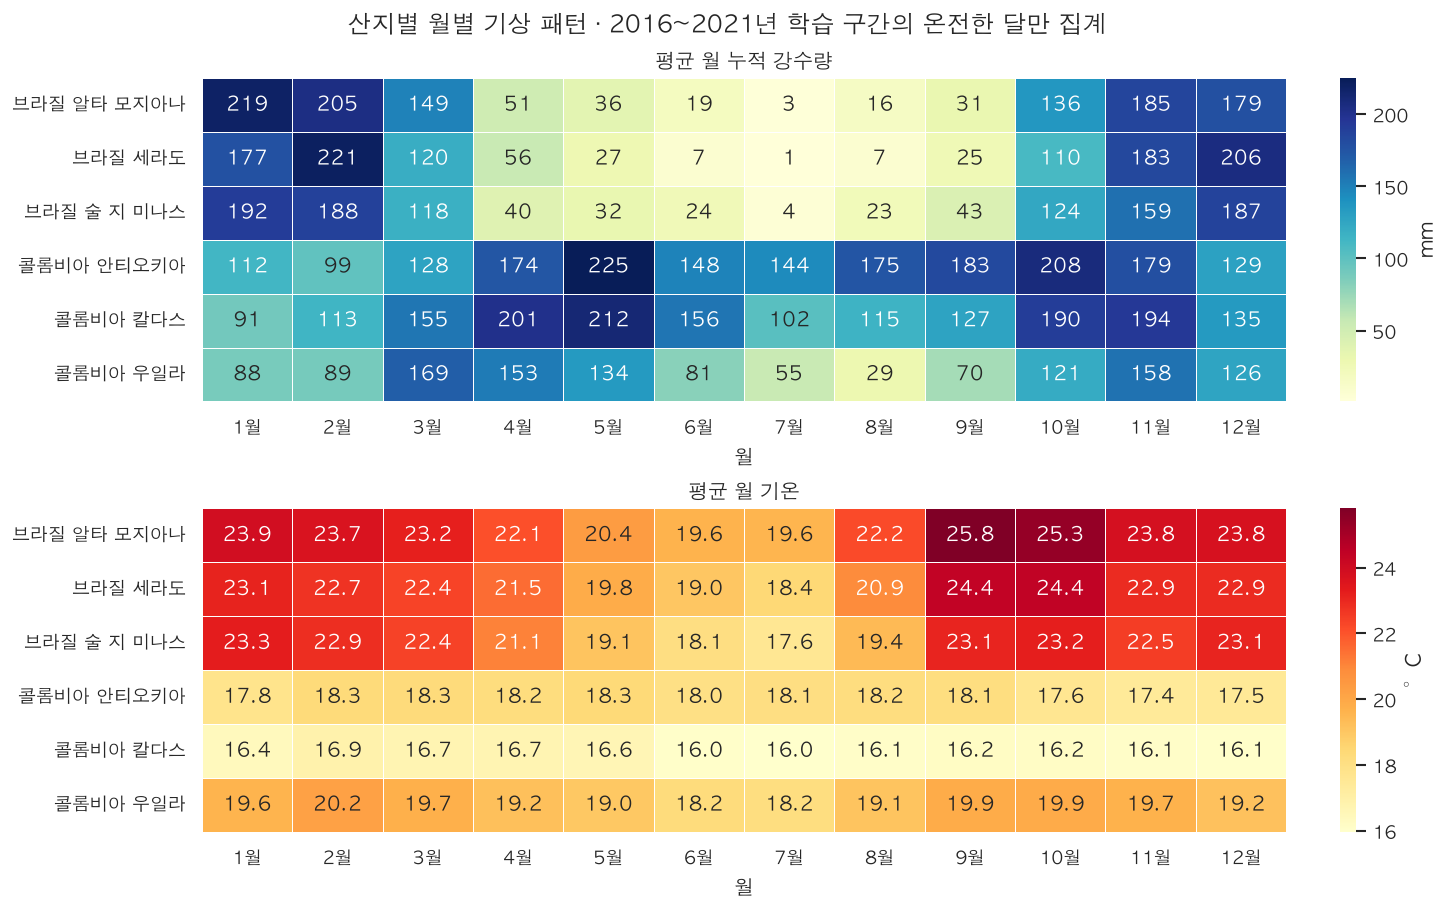

In [14]:
# 기상은 거래일로 붙이기 전의 일별 원자료로 본다. 덜 모인 달은 월 비교에서 뺀다.
monthly_climate = []
for region in region_labels:
    raw = sources[f"weather_{region}"]
    raw = raw.loc[(raw["date"] >= TRAIN_START) & (raw["date"] + pd.Timedelta(days=LAG_DAYS["weather"]) <= TRAIN_END)]
    monthly = (
        raw.set_index("date")
        .resample("MS")
        .agg(rain=("PRECTOTCORR", "sum"), temp=("T2M", "mean"), days=("T2M", "count"))
    )
    monthly = monthly.loc[monthly["days"] == monthly.index.days_in_month].copy()
    monthly["month"] = monthly.index.month
    monthly["region"] = region_labels[region]
    monthly_climate.append(monthly)
climate = pd.concat(monthly_climate).groupby(["region", "month"])[["rain", "temp"]].mean()
fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), layout="constrained")
for ax, name, title, unit, color in zip(
    axes, ["rain", "temp"], ["평균 월 누적 강수량", "평균 월 기온"], ["mm", "°C"], ["YlGnBu", "YlOrRd"]
):
    table = climate[name].unstack("month").reindex(region_labels.values())
    table.columns = [f"{month}월" for month in table.columns]
    sns.heatmap(
        table,
        ax=ax,
        annot=True,
        fmt=".0f" if name == "rain" else ".1f",
        cmap=color,
        cbar_kws={"label": unit},
        linewidths=0.3,
    )
    ax.set(title=title, xlabel="월", ylabel="")
    ax.tick_params(axis="y", rotation=0)
fig.suptitle("산지별 월별 기상 패턴 · 2016~2021년 학습 구간의 온전한 달만 집계")
plt.show()


### 변수 사이의 관계

Pearson은 선형 관계, Spearman은 값의 순서가 함께 움직이는 정도를 본다. 종가와 어떤 변수가 같이 상승했다고 해서 다음 주 수익률까지 설명되는 것은 아니다. 그래서 **종가와의 관계 / 실제 예측 대상과의 관계**를 함께 비교한다. 기상 피처끼리 비슷하게 움직이는지도 본다.

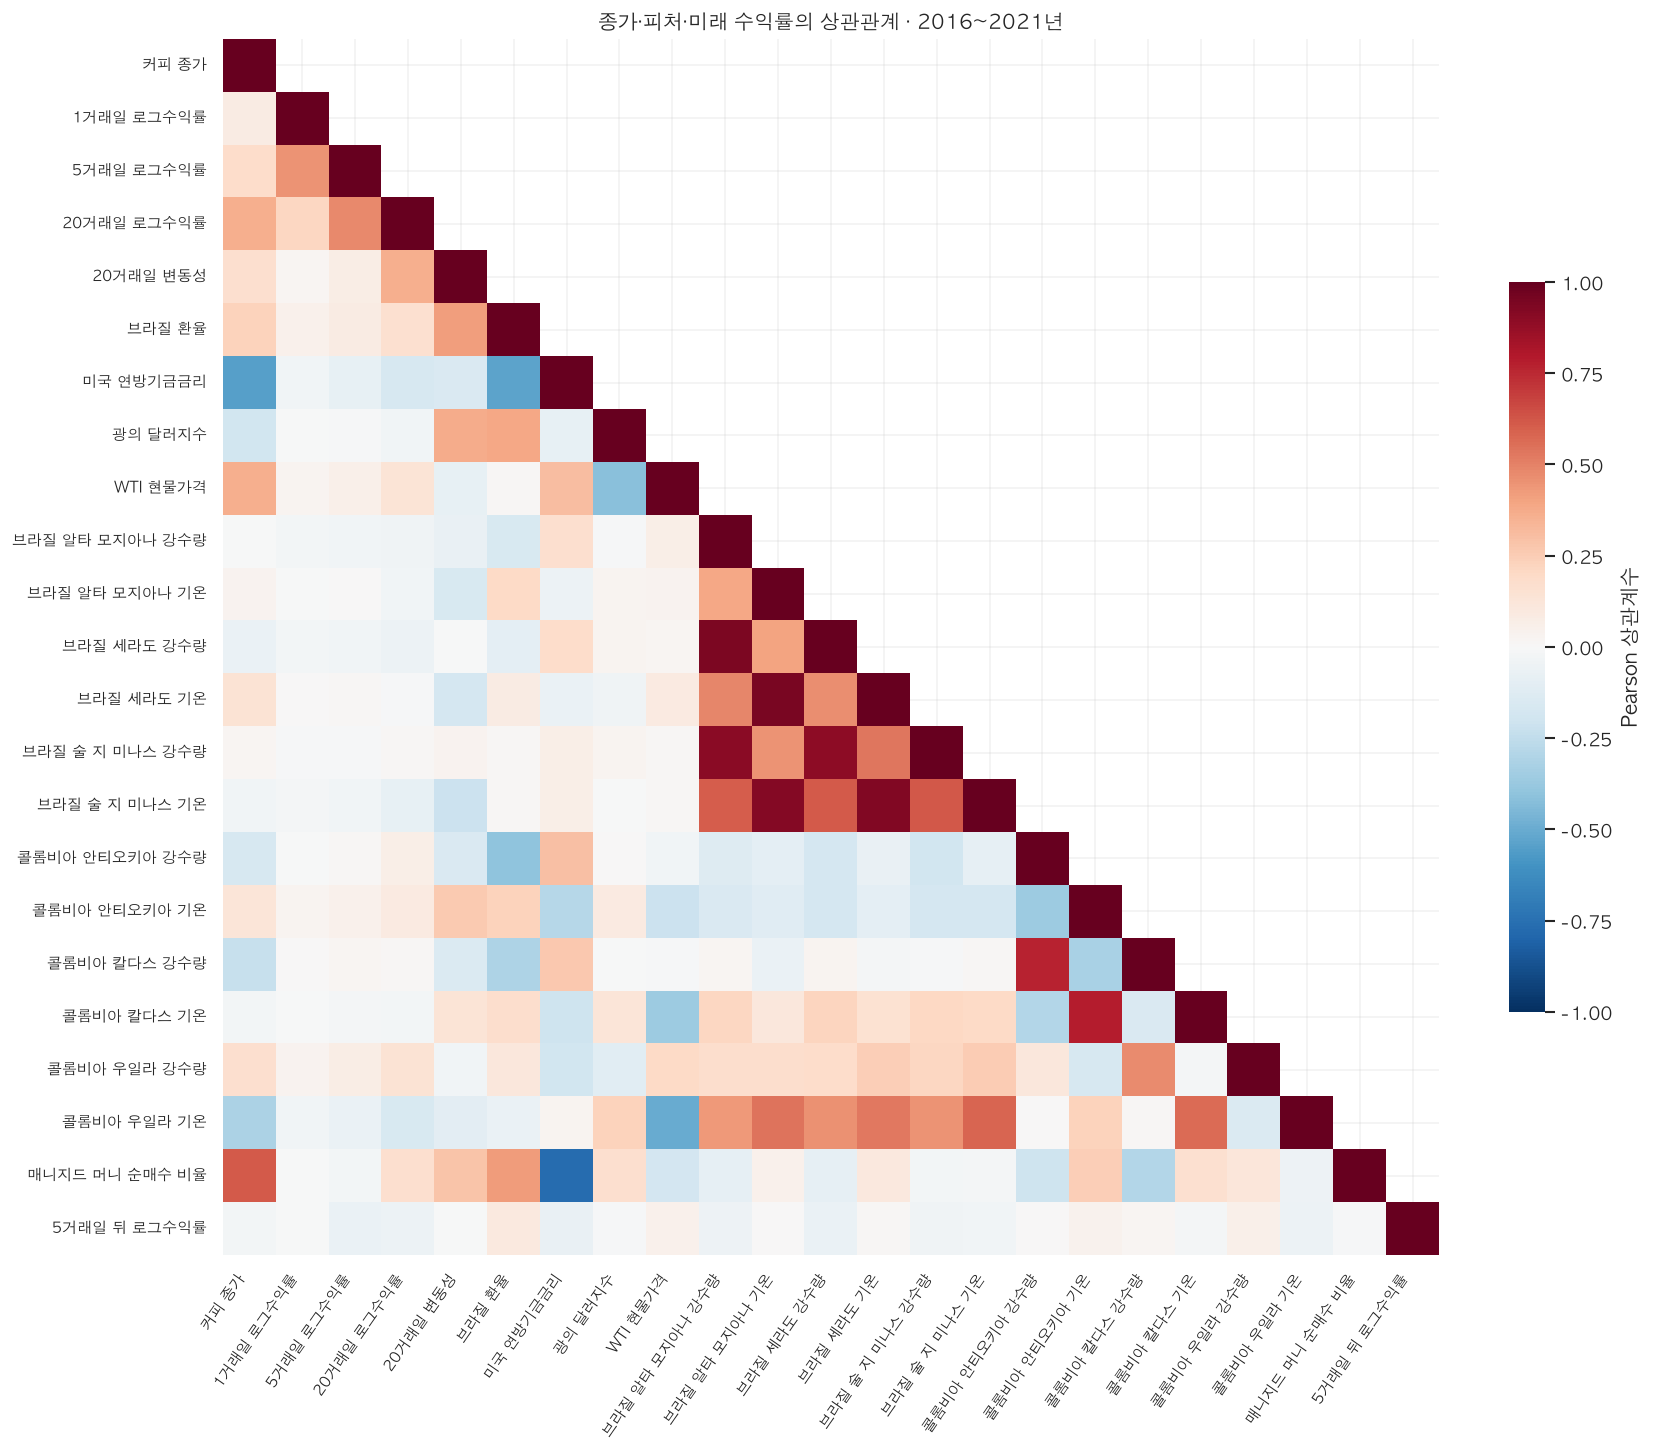

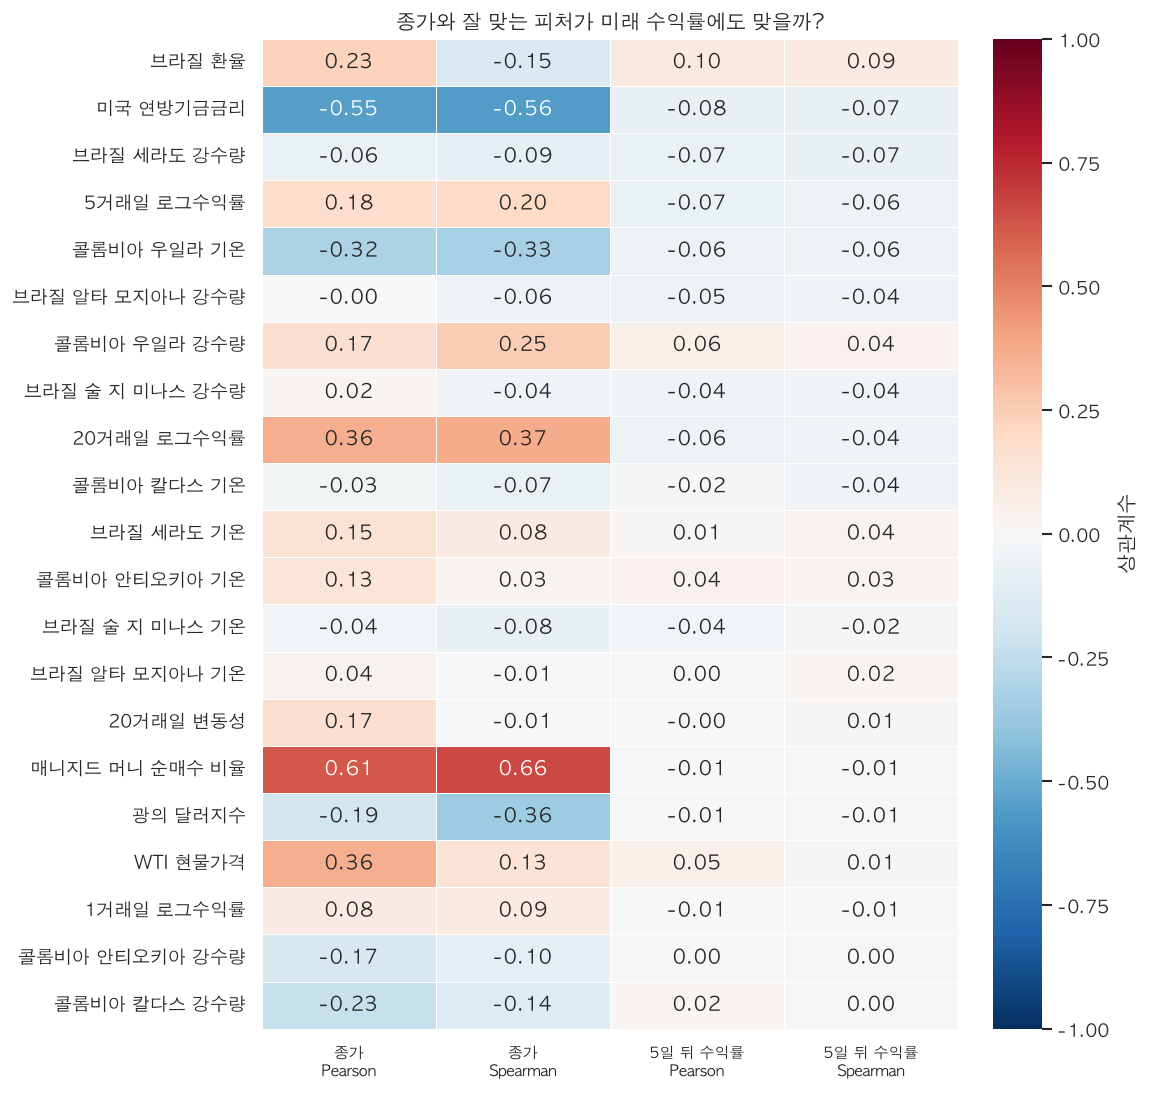

In [15]:
corr_columns = ["close", *FEATURES, TARGET]
pearson = eda_train[corr_columns].corr(method="pearson")
spearman = eda_train[corr_columns].corr(method="spearman")
fig, ax = plt.subplots(figsize=(14, 12), layout="constrained")
sns.heatmap(
    pearson.rename(index=short_labels, columns=short_labels),
    mask=np.triu(np.ones_like(pearson, dtype=bool), k=1),
    vmin=-1,
    vmax=1,
    center=0,
    cmap="RdBu_r",
    square=True,
    ax=ax,
    cbar_kws={"label": "Pearson 상관계수", "shrink": 0.6},
)
ax.set(title="종가·피처·미래 수익률의 상관관계 · 2016~2021년", xlabel="", ylabel="")
ax.tick_params(axis="x", labelrotation=55, labelsize=9)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)
plt.setp(ax.get_xticklabels(), ha="right")
plt.show()

relationships = pd.DataFrame(
    {
        "종가 · Pearson": pearson.loc[FEATURES, "close"],
        "종가 · Spearman": spearman.loc[FEATURES, "close"],
        "5일 뒤 수익률 · Pearson": pearson.loc[FEATURES, TARGET],
        "5일 뒤 수익률 · Spearman": spearman.loc[FEATURES, TARGET],
    }
)
order = relationships["5일 뒤 수익률 · Spearman"].abs().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9.5, 9), layout="constrained")
sns.heatmap(
    relationships.loc[order].rename(index=short_labels, columns=lambda name: name.replace(" · ", "\n")),
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    cmap="RdBu_r",
    linewidths=0.4,
    ax=ax,
    cbar_kws={"label": "상관계수"},
)
ax.set(title="종가와 잘 맞는 피처가 미래 수익률에도 맞을까?", xlabel="", ylabel="")
ax.tick_params(axis="x", labelrotation=0, labelsize=9)
ax.tick_params(axis="y", labelrotation=0)
plt.show()


### 기상 피처의 다중공선성 사전 점검

6개 산지의 30일 평균 기온·누적 강수량, 총 12개만 따로 본다. **Pearson |r|≥0.8**인 조합을 추리고 Spearman도 함께 표시한다. 여러 피처가 합쳐져 겹치는 경우도 보려고 [VIF](https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html)를 계산했다. VIF는 이 기상 12개를 함께 넣었을 때의 값이며, 5 이상을 추가로 살펴볼 기준으로 잡았다.

상관이 높으면 선형 계수나 개별 피처 중요도를 해석할 때 주의가 필요하다. 이번에는 진단 결과를 남기고, 실제 피처 선택은 학습·검증 구간에서 별도로 비교하려 한다.

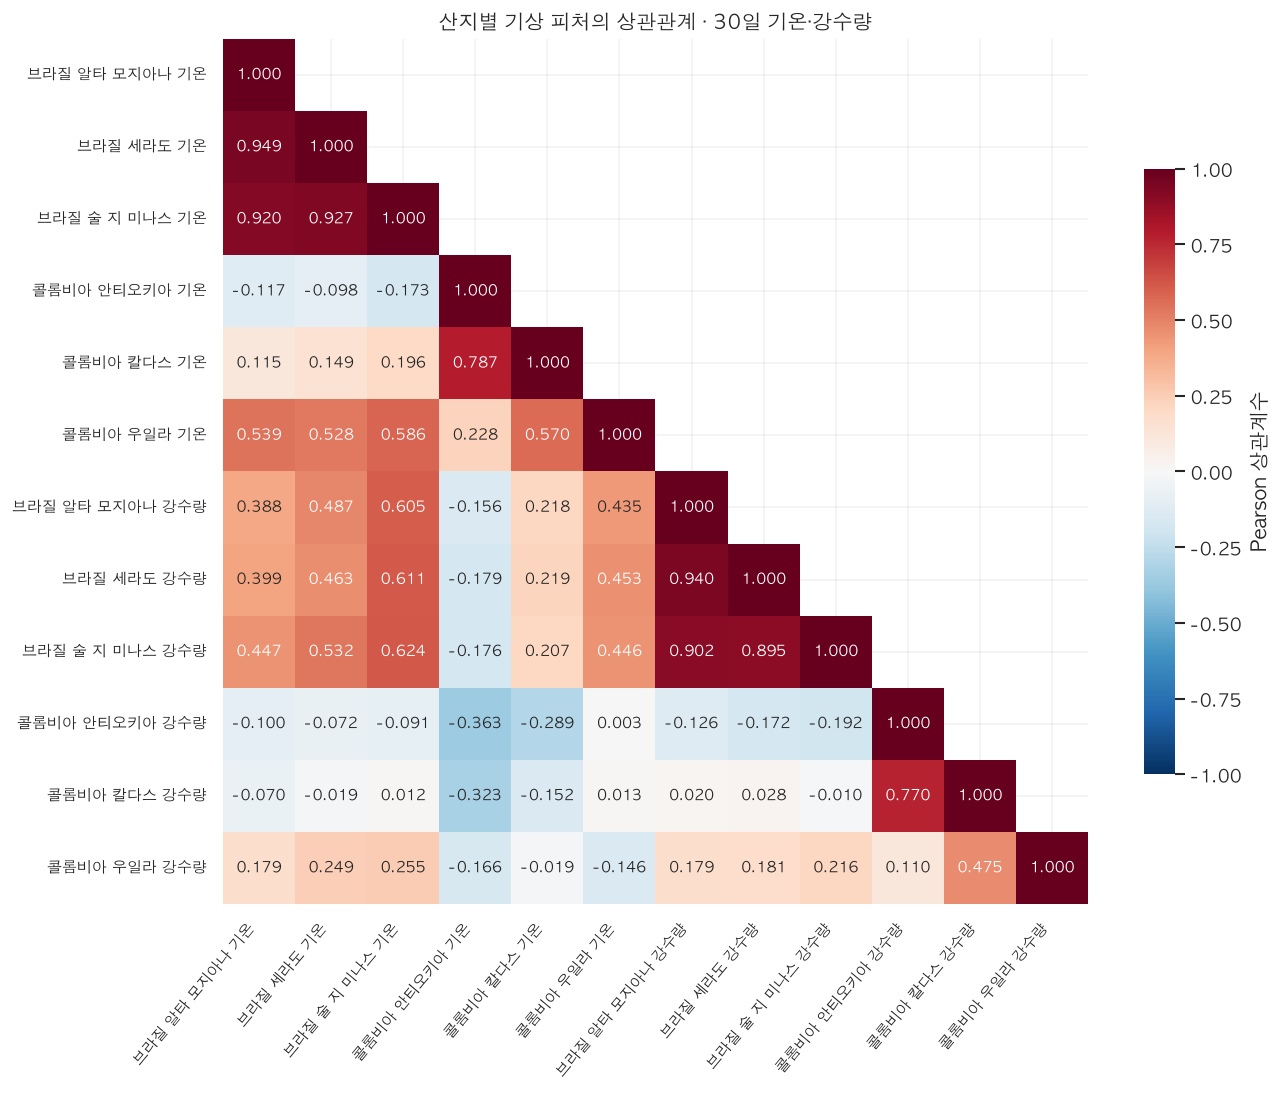

기상 피처 1,기상 피처 2,Pearson 상관계수,Spearman 상관계수
브라질 알타 모지아나 기온,브라질 세라도 기온,0.949,0.943
브라질 알타 모지아나 강수량,브라질 세라도 강수량,0.940,0.964
브라질 세라도 기온,브라질 술 지 미나스 기온,0.927,0.915
브라질 알타 모지아나 기온,브라질 술 지 미나스 기온,0.920,0.905
브라질 알타 모지아나 강수량,브라질 술 지 미나스 강수량,0.902,0.944
브라질 세라도 강수량,브라질 술 지 미나스 강수량,0.895,0.929


,VIF,점검
기상 피처,,
브라질 술 지 미나스 기온,19.33,5 이상 · 함께 확인
브라질 알타 모지아나 기온,18.71,5 이상 · 함께 확인
브라질 세라도 기온,16.46,5 이상 · 함께 확인
브라질 알타 모지아나 강수량,12.55,5 이상 · 함께 확인
브라질 세라도 강수량,11.92,5 이상 · 함께 확인
콜롬비아 칼다스 기온,7.61,5 이상 · 함께 확인
브라질 술 지 미나스 강수량,7.17,5 이상 · 함께 확인
콜롬비아 안티오키아 기온,6.78,5 이상 · 함께 확인
콜롬비아 칼다스 강수량,4.71,5 미만


술 지 미나스–세라도 기온 상관: 0.927 | |r|≥0.8인 기상 조합: 6개


In [16]:
weather_order = [f"{region}_{kind}" for kind in ["temp_30d", "rain_30d"] for region in region_labels]
weather_corr = eda_train[weather_order].corr(method="pearson")
weather_rank_corr = eda_train[weather_order].corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 9), layout="constrained")
sns.heatmap(
    weather_corr.rename(index=short_labels, columns=short_labels),
    mask=np.triu(np.ones_like(weather_corr, dtype=bool), k=1),
    annot=True,
    fmt=".3f",
    annot_kws={"fontsize": 9},
    vmin=-1,
    vmax=1,
    center=0,
    cmap="RdBu_r",
    square=True,
    ax=ax,
    cbar_kws={"label": "Pearson 상관계수", "shrink": 0.7},
)
ax.set(title="산지별 기상 피처의 상관관계 · 30일 기온·강수량", xlabel="", ylabel="")
ax.tick_params(axis="x", labelrotation=50, labelsize=9)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)
plt.setp(ax.get_xticklabels(), ha="right")
plt.show()

# 자기 자신과 중복 조합을 뺀다. 0.8은 자동 삭제 기준이 아니라 살펴볼 조합을 고르는 기준이다.
upper = weather_corr.where(np.triu(np.ones_like(weather_corr, dtype=bool), k=1))
weather_pairs = upper.stack().dropna().rename("pearson").rename_axis(["feature_a", "feature_b"]).reset_index()
high_weather_pairs = weather_pairs.loc[weather_pairs["pearson"].abs() >= 0.8].copy()
high_weather_pairs["spearman"] = [
    weather_rank_corr.loc[a, b] for a, b in zip(high_weather_pairs["feature_a"], high_weather_pairs["feature_b"])
]
high_weather_pairs = high_weather_pairs.sort_values("pearson", key=lambda column: column.abs(), ascending=False)
display(
    high_weather_pairs.assign(
        feature_a=lambda table: table["feature_a"].map(short_labels),
        feature_b=lambda table: table["feature_b"].map(short_labels),
    )
    .rename(
        columns={
            "feature_a": "기상 피처 1",
            "feature_b": "기상 피처 2",
            "pearson": "Pearson 상관계수",
            "spearman": "Spearman 상관계수",
        }
    )
    .style.hide(axis="index")
    .format({"Pearson 상관계수": "{:.3f}", "Spearman 상관계수": "{:.3f}"})
)

weather_design = sm.add_constant(eda_train[weather_order])
weather_vif = pd.Series(
    {
        name: variance_inflation_factor(weather_design.to_numpy(), i)
        for i, name in enumerate(weather_design.columns)
        if name != "const"
    },
    name="VIF",
)
weather_vif = weather_vif.sort_values(ascending=False)
display(
    weather_vif.rename(index=short_labels)
    .rename_axis("기상 피처")
    .to_frame()
    .assign(점검=lambda table: np.where(table["VIF"] >= 5, "5 이상 · 함께 확인", "5 미만"))
    .style.format({"VIF": "{:.2f}"})
)
sul_cerrado_corr = weather_corr.loc["br_sul_minas_temp_30d", "br_cerrado_temp_30d"]
print(f"술 지 미나스–세라도 기온 상관: {sul_cerrado_corr:.3f} | |r|≥0.8인 기상 조합: {len(high_weather_pairs)}개")


In [17]:
display(Markdown(
    f"술 지 미나스–세라도 기온 상관은 **{sul_cerrado_corr:.3f}**, "
    f"기상 12개 묶음의 최대 VIF는 **{weather_vif.max():.2f}**였다. "
    "비슷한 산지와 집계 기간을 쓰니 겹치는 부분이 크다. "
    "이 수치만으로 트리 모델에서 제거할 변수를 정하지는 않는다."
))


술 지 미나스–세라도 기온 상관은 **0.927**, 기상 12개 묶음의 최대 VIF는 **19.33**였다. 비슷한 산지와 집계 기간을 쓰니 겹치는 부분이 크다. 이 수치만으로 트리 모델에서 제거할 변수를 정하지는 않는다.

### 회귀선으로 확인하기

각 피처 하나를 x, 종가를 y로 놓았다. 선은 Train 구간에 맞춘 단순 회귀선이다. 패널의 R²도 같은 구간에서의 설명력이라 예측 성능과는 다르다. 날짜가 이어진 데이터여서 일반적인 독립 표본 부트스트랩 신뢰구간은 표시하지 않았다. 아래에는 미래 수익률과의 Spearman 상관이 큰 6개도 따로 그린다.


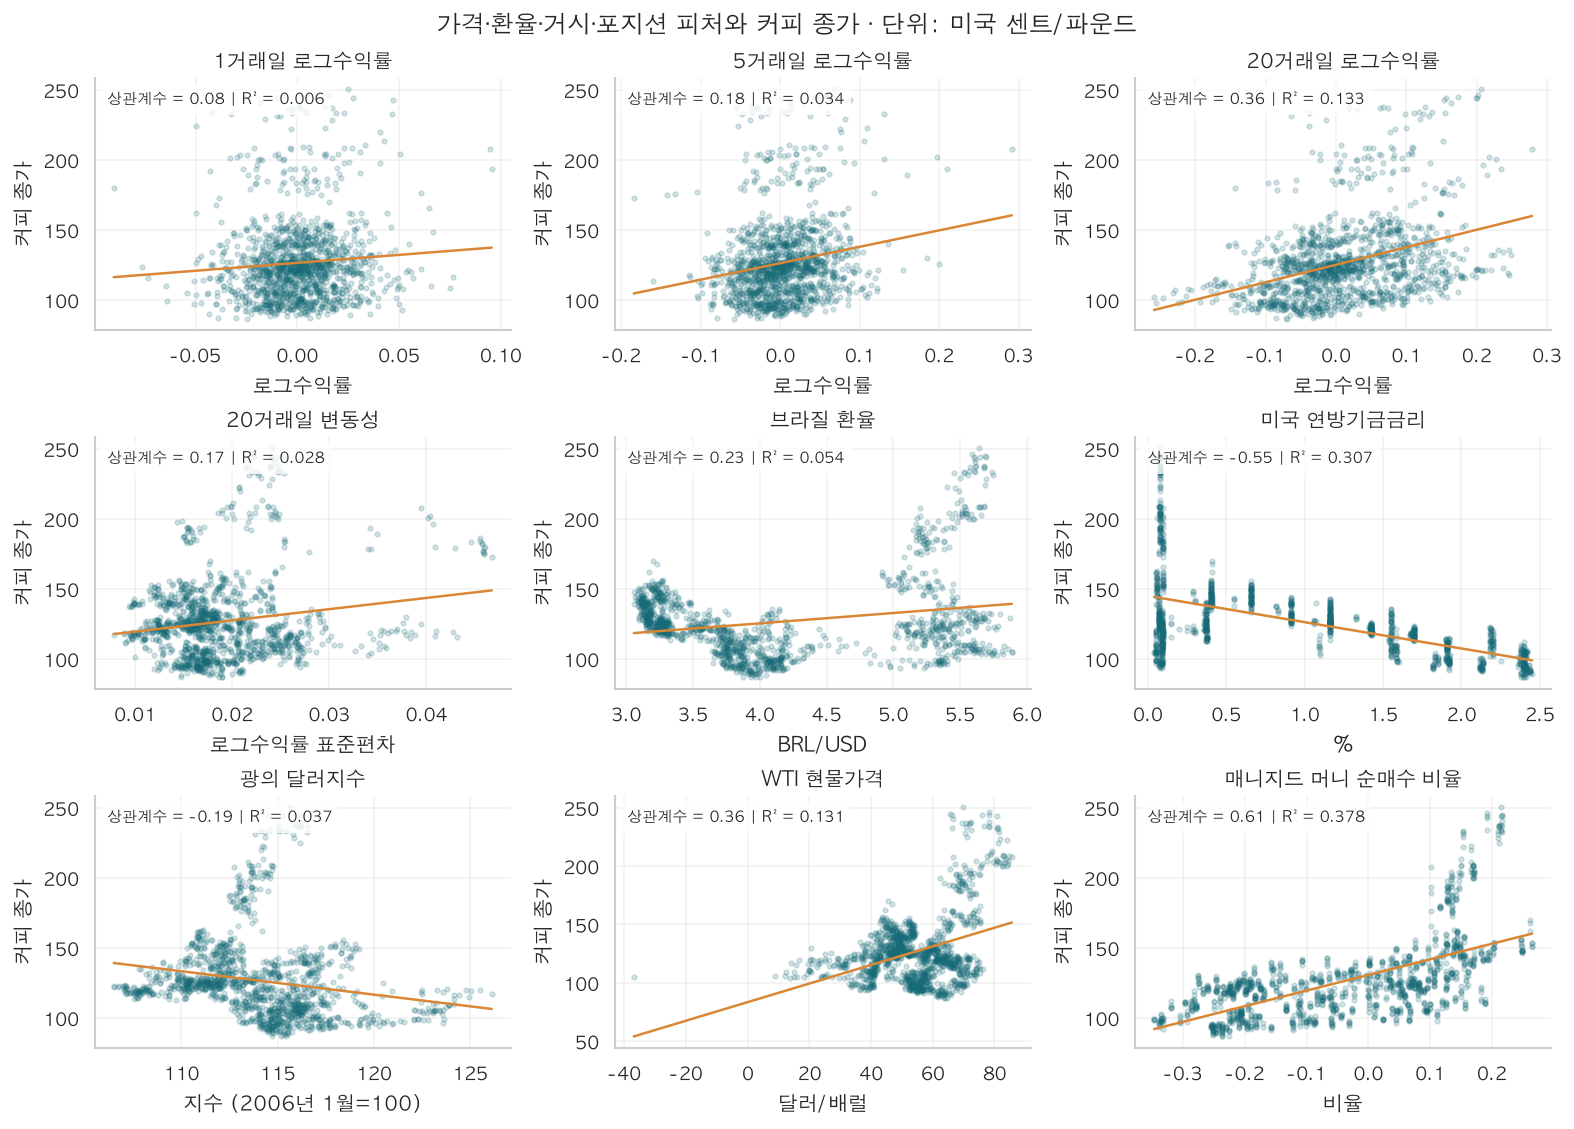

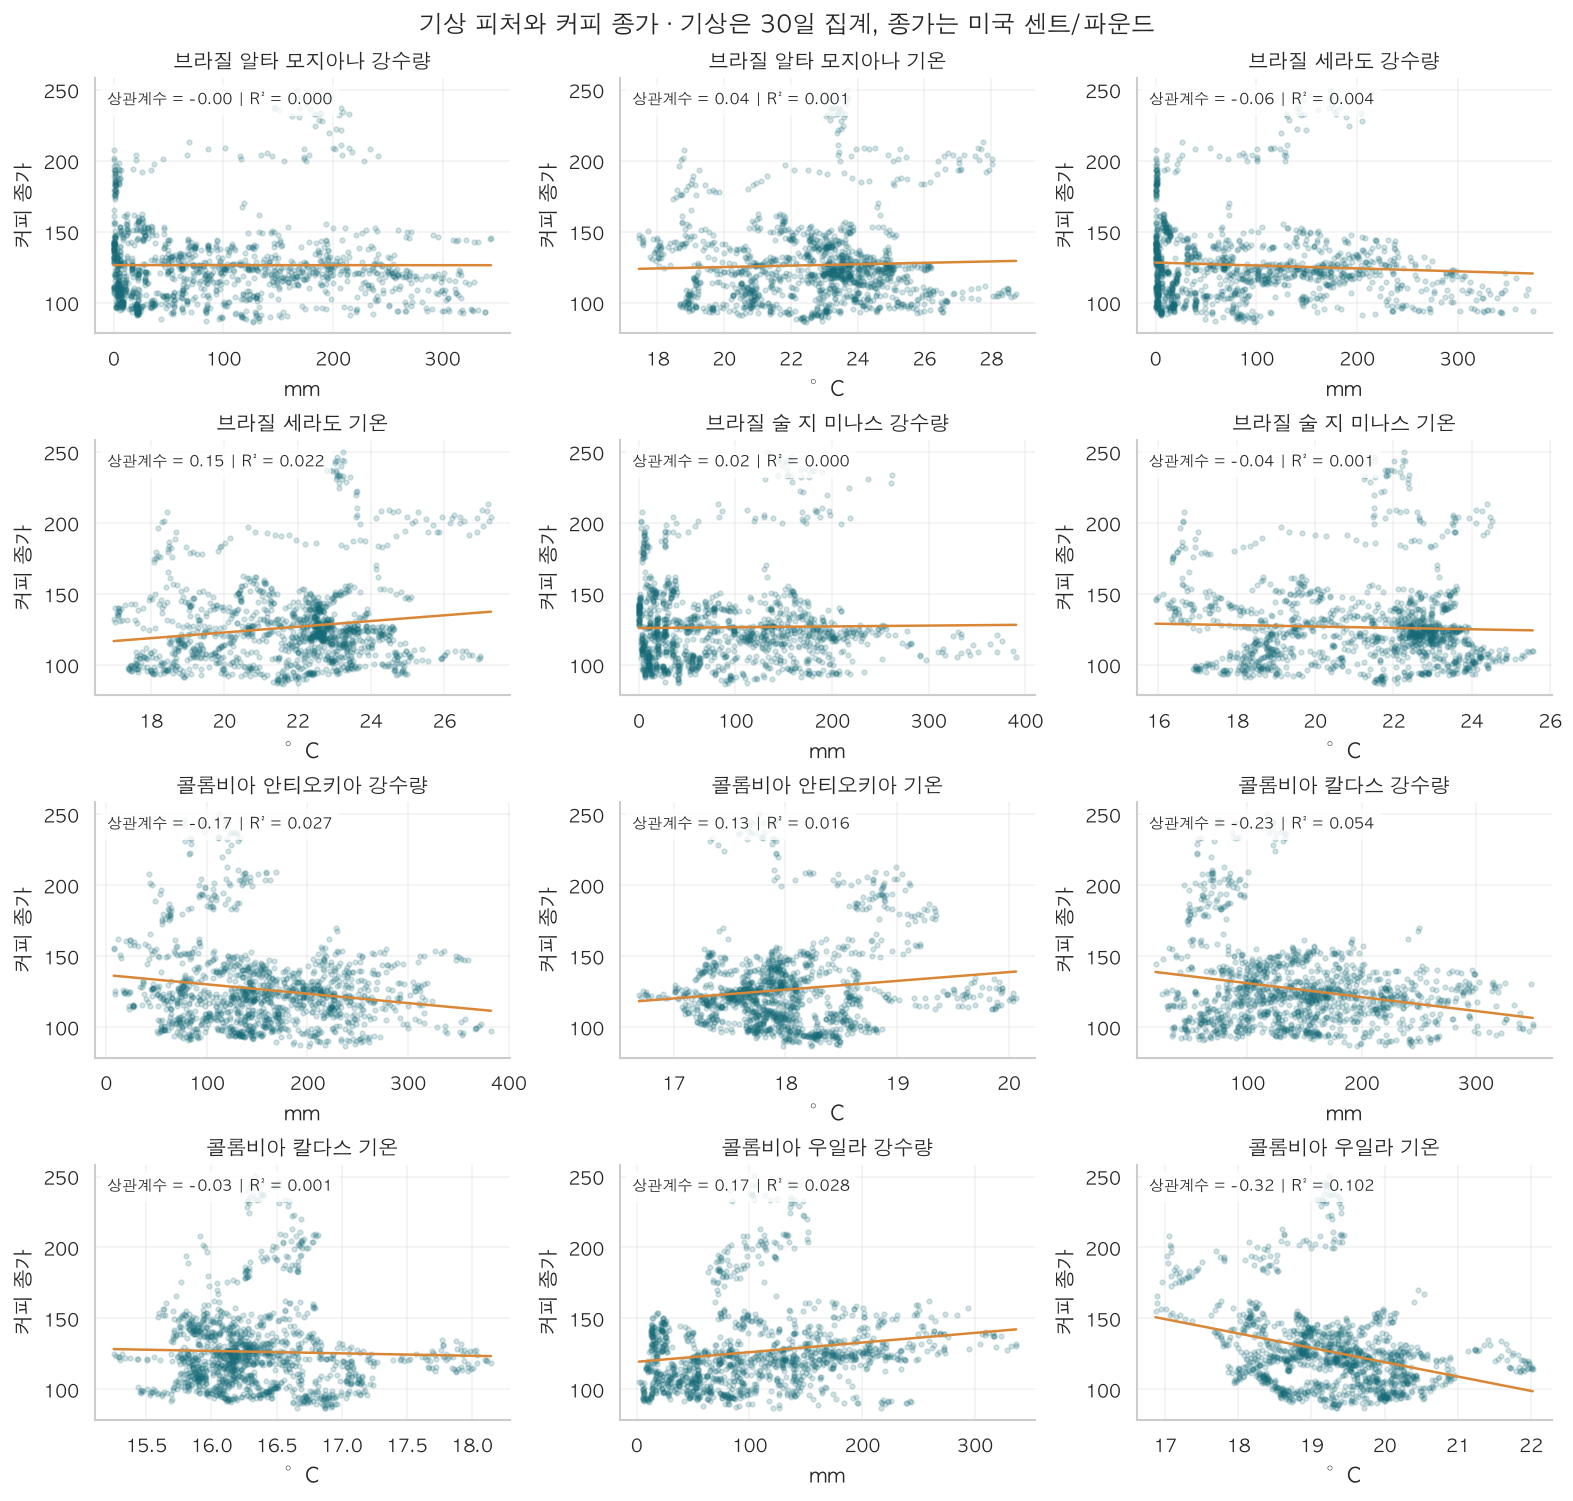

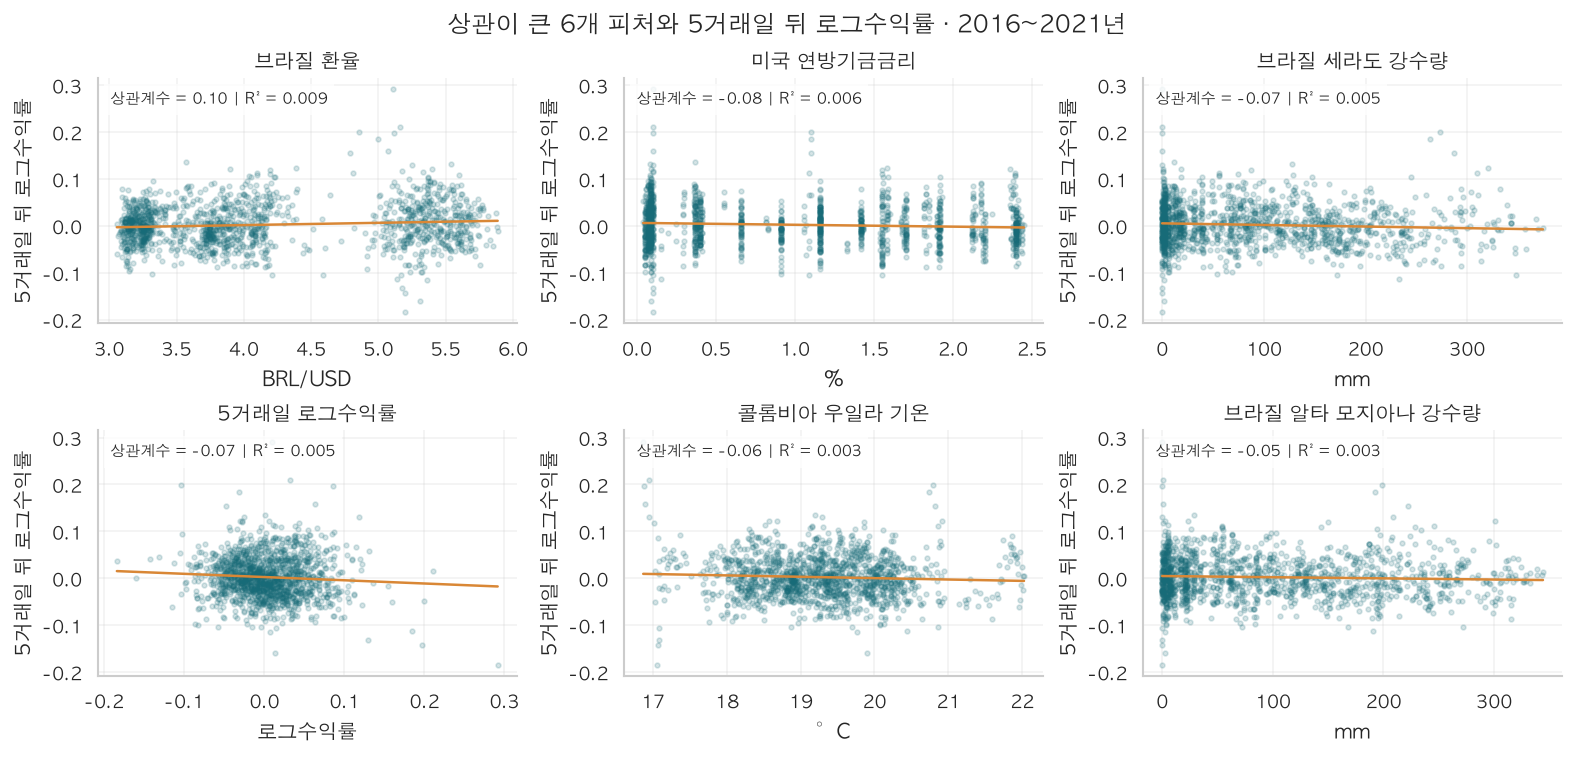

In [18]:
def plot_relationships(frame, columns, target, title):
    rows = (len(columns) + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(13, rows * 3.1), layout="constrained")
    for ax, name in zip(axes.flat, columns):
        sns.regplot(
            data=frame,
            x=name,
            y=target,
            ci=None,
            ax=ax,
            scatter_kws={"s": 8, "alpha": 0.18, "color": "#176B78"},
            line_kws={"color": "#D98736", "linewidth": 1.5},
        )
        r = frame[name].corr(frame[target])
        ax.set(title=short_labels[name], xlabel=units[name], ylabel=short_labels[target])
        ax.text(
            0.03,
            0.95,
            f"상관계수 = {r:.2f} | R² = {r**2:.3f}",
            transform=ax.transAxes,
            va="top",
            fontsize=9,
            bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
        )
    for ax in axes.flat[len(columns) :]:
        ax.set_visible(False)
    fig.suptitle(title)
    plt.show()


non_weather = [name for name in FEATURES if name not in weather_features]
plot_relationships(eda_train, non_weather, "close", "가격·환율·거시·포지션 피처와 커피 종가 · 단위: 미국 센트/파운드")
plot_relationships(eda_train, weather_features, "close", "기상 피처와 커피 종가 · 기상은 30일 집계, 종가는 미국 센트/파운드")
plot_relationships(eda_train, list(order[:6]), TARGET, "상관이 큰 6개 피처와 5거래일 뒤 로그수익률 · 2016~2021년")


### 단순 회귀의 적합도와 검정

R²는 같은 Train 구간에서 회귀선이 변동을 얼마나 설명하는지 나타낸다. 종가에는 추세가 섞이기 쉬워 p값을 붙이지 않는다. 미래 5일 수익률은 기울기가 0인지 HAC 표준오차로 살펴보고 21개 검정에 FDR 보정을 적용한다.

HAC 지연은 20거래일이다. 빠진 거래일을 앞뒤로 붙이면 잔차 사이의 간격도 바뀌므로 원래 거래일 위치를 유지한다. 검증 구간 R²는 뒤쪽의 기존 모델 실험에서 확인한다.


In [19]:
def calendar_hac(fit, session_positions, maxlags):
    # 결측 가격을 0으로 채우는 게 아니다. 회귀에 없는 날은 잔차 점수에 기여하지 않는다.
    positions = np.asarray(session_positions, dtype=int)
    positions = positions - positions.min()
    assert np.all(np.diff(positions) > 0)
    scores = np.zeros((positions.max() + 1, fit.model.exog.shape[1]))
    scores[positions] = fit.model.exog * np.asarray(fit.resid)[:, None]
    bread = np.asarray(fit.normalized_cov_params)
    covariance = bread @ S_hac_simple(scores, nlags=maxlags) @ bread
    return covariance * fit.nobs / fit.df_resid


def univariate_eda(frame, columns, target):
    rows = []
    for name in columns:
        design = sm.add_constant(frame[[name]], has_constant="add")
        price_fit = sm.OLS(frame.close, design).fit()
        return_fit = sm.OLS(frame[target], design).fit()
        covariance = calendar_hac(return_fit, frame.index, maxlags=20)
        slope_se = np.sqrt(covariance[1, 1])
        rows.append({"feature": name, "price_r2": price_fit.rsquared,
                     "return_r2": return_fit.rsquared,
                     "hac_p": 2 * stats.norm.sf(abs(return_fit.params[name] / slope_se))})
    result = pd.DataFrame(rows).set_index("feature")
    result["fdr_p"] = multipletests(result.hac_p, method="fdr_bh")[1]
    return result


regression = univariate_eda(eda_train, FEATURES, TARGET).loc[order]
display(regression.rename(index=short_labels, columns={
    "price_r2": "종가 R²", "return_r2": "수익률 R²",
    "hac_p": "기울기 p값 (HAC)", "fdr_p": "보정 p값 (FDR)",
}).rename_axis("피처").style.format("{:.4f}"))


,종가 R²,수익률 R²,기울기 p값 (HAC),보정 p값 (FDR)
피처,,,,
브라질 환율,0.0536,0.0093,0.0464,0.7611
미국 연방기금금리,0.3066,0.0056,0.1606,0.7611
브라질 세라도 강수량,0.0042,0.0047,0.1813,0.7611
5거래일 로그수익률,0.0339,0.0047,0.1609,0.7611
콜롬비아 우일라 기온,0.1019,0.0034,0.3184,0.7611
브라질 알타 모지아나 강수량,0.0000,0.0026,0.2923,0.7611
콜롬비아 우일라 강수량,0.0284,0.0037,0.2177,0.7611
브라질 술 지 미나스 강수량,0.0003,0.0016,0.4031,0.7696
20거래일 로그수익률,0.1332,0.0032,0.2527,0.7611


In [20]:
display(Markdown(
    "### 여기까지 보고 든 생각\n\n"
    f"Train에서 5일 뒤 수익률과의 최대 |Pearson 상관|은 "
    f"**{pearson.loc[FEATURES, TARGET].abs().max():.3f}**였다. "
    f"단순 회귀에서 HAC·FDR 보정 p값이 0.05보다 작은 피처는 "
    f"**{int(regression.fdr_p.lt(0.05).sum())}개**다. "
    "종가와 같이 움직였다는 것만으로 미래 변화까지 예측하기는 어렵다. "
    "기상이 쓸모없다고 결론 내리기 전에, 계절 편차와 더 긴 시차도 살펴본다."
))


### 여기까지 보고 든 생각

Train에서 5일 뒤 수익률과의 최대 |Pearson 상관|은 **0.097**였다. 단순 회귀에서 HAC·FDR 보정 p값이 0.05보다 작은 피처는 **0개**다. 종가와 같이 움직였다는 것만으로 미래 변화까지 예측하기는 어렵다. 기상이 쓸모없다고 결론 내리기 전에, 계절 편차와 더 긴 시차도 살펴본다.

## 4. 입력 시차와 예측 기간 나눠 보기

5일 뒤만 봐서 관계를 놓쳤을까? 추가 입력 시차는 **0·5·20·60·120거래일**, 예측 기간은 **7·14·30·120·180·360거래일**로 고정한다. 기상 집계는 기존 30달력일을 유지한다. 시차 0도 그날 관측값을 바로 쓴다는 뜻은 아니다. 기존 공개 지연을 적용한 뒤 이용 가능한 최신 값이다.

종가 수준의 추세를 피하려고 `ln(P[t+h] / P[t])`를 타깃으로 쓴다. 기상은 관측 월의 Train 평균에서 뺀 편차, 환율·달러지수는 20거래일 로그변화, 금리·WTI·COT 비율은 20거래일 차이를 사용한다. WTI에는 음수가 있어 로그를 취하지 않는다.

이 절은 **Train 내부의 탐색**이다. 월별 기준도 Train에서 추정한 값이며, 당시 실시간으로 계산된 평년값이나 식별된 경제 충격을 뜻하지 않는다. 2015년 기상은 30일 집계의 버퍼로만 쓴다.

180·360도 달력일이 아니라 거래일이다. 1년을 약 252거래일로 보면 약 9개월·17개월 앞이다. 입력 시차는 늘리지 않고 예측 기간만 확장한다. 긴 기간에 상관이 커져도 기상의 영향이나 예측력이 커졌다고 단정하지 않는다.


In [21]:
def lag_columns(feature, lags):
    return [f"{feature}__lag_{lag}" for lag in lags]


def prepare_lag_data(frame, external_features, price_features, lags, horizons, start, end):
    # 기존 5일 타깃이나 dropna 결과를 가져오면 다른 horizon의 날짜까지 잘린다.
    source_names = {"brl_close": "brl", "dff": "dff", "dtwexbgs": "dtwexbgs",
                    "dcoilwtico": "dcoilwtico", "cot_net_ratio": "cot"}
    for name in external_features:
        if name.endswith(("_rain_30d", "_temp_30d")):
            source_names[name] = "weather_" + name.rsplit("_", 2)[0]
    time_columns = [f"{source}_{kind}" for source in dict.fromkeys(source_names.values())
                    for kind in ("observed_at", "available_at")]
    base_columns = ["date", "prediction_at", "close", *price_features, *external_features, *time_columns]
    calendar = frame.loc[frame.date.between(start, end), base_columns].copy().reset_index(drop=True)
    assert calendar.date.is_unique and calendar.date.is_monotonic_increasing
    values, references = {}, []
    for name in external_features:
        source = source_names[name]
        observed, available = calendar[f"{source}_observed_at"], calendar[f"{source}_available_at"]
        matched = available.notna()
        assert ((observed <= available) & (available <= calendar.prediction_at)).loc[matched].all()
        assert (calendar[name].isna() | matched).all()
        if name.endswith(("_rain_30d", "_temp_30d")):
            # 같은 관측일이 여러 번 붙어도 월별 기준에는 한 번만 포함한다.
            reference = calendar.loc[observed.ge(start), [f"{source}_observed_at", name]].drop_duplicates(
                f"{source}_observed_at"
            )
            monthly_mean = reference.groupby(reference[f"{source}_observed_at"].dt.month)[name].mean()
            values[name] = calendar[name] - observed.dt.month.map(monthly_mean)
            references.extend({"feature": name, "month": month, "mean": mean}
                              for month, mean in monthly_mean.items())
        elif name in ("brl_close", "dtwexbgs"):
            assert calendar[name].dropna().gt(0).all()
            values[name] = np.log(calendar[name]).diff(20)
        else:
            values[name] = calendar[name].diff(20)
    inputs = pd.DataFrame(values, index=calendar.index)
    result = calendar[["date", "prediction_at", "close", *price_features]].copy()
    result["session_id"] = np.arange(len(calendar))
    shifted = {}
    for name in external_features:
        for lag, column in zip(lags, lag_columns(name, lags)):
            shifted[column] = inputs[name].shift(lag)
            available = calendar[f"{source_names[name]}_available_at"].shift(lag)
            matched = shifted[column].notna()
            assert available.loc[matched].le(result.loc[matched, "prediction_at"]).all()
    log_price = np.log(calendar.close.where(calendar.close.gt(0)))
    for horizon in horizons:
        shifted[f"future_log_return_{horizon}d"] = log_price.shift(-horizon) - log_price
        shifted[f"target_date_{horizon}"] = calendar.date.shift(-horizon)
    return pd.concat([result, pd.DataFrame(shifted)], axis=1), inputs, pd.DataFrame(references)


def lag_samples(frame, external_features, price_features, lags, horizons, end):
    columns = [*price_features, *[column for name in external_features for column in lag_columns(name, lags)]]
    common = np.isfinite(frame[["close", *columns]]).all(axis=1)
    samples = {}
    for horizon in horizons:
        target, target_date = f"future_log_return_{horizon}d", f"target_date_{horizon}"
        valid = common & np.isfinite(frame[target]) & frame[target_date].le(end)
        samples[horizon] = frame.loc[valid].copy()
        assert len(samples[horizon]) and samples[horizon][target_date].le(end).all()
        assert (samples[horizon].session_id + horizon).lt(len(frame)).all()
    return samples


In [22]:
lag_external_features = [name for name in FEATURES if name not in PRICE_FEATURES]
assert len(lag_external_features) == 17
lag_frame, lag_inputs, lag_monthly_reference = prepare_lag_data(
    joined, lag_external_features, PRICE_FEATURES, INPUT_LAGS, HORIZONS, TRAIN_START, TRAIN_END
)
lag_train_samples = lag_samples(lag_frame, lag_external_features, PRICE_FEATURES, INPUT_LAGS, HORIZONS, TRAIN_END)
lag_periods = pd.DataFrame([
    {"예측 기간 (거래일)": horizon, "공통 행 수": len(sample),
     "첫 예측 기준일": sample.date.min().date(), "마지막 예측 기준일": sample.date.max().date(),
     "마지막 정답 날짜": sample[f"target_date_{horizon}"].max().date()}
    for horizon, sample in lag_train_samples.items()
]).set_index("예측 기간 (거래일)")
display(lag_periods)
print("모든 변수와 시차는 같은 horizon 안에서 동일한 행으로 비교한다. 초기 시차 구간은 대치하지 않는다.")

lag_labels = {name: short_labels[name] + (" · 월별 편차" if name in weather_features else " · 20거래일 변화")
              for name in lag_external_features}


,공통 행 수,첫 예측 기준일,마지막 예측 기준일,마지막 정답 날짜
예측 기간 (거래일),,,,
7,1290,2016-08-08,2021-12-21,2021-12-31
14,1283,2016-08-08,2021-12-10,2021-12-31
30,1266,2016-08-08,2021-11-17,2021-12-31
120,1178,2016-08-08,2021-07-13,2021-12-31
180,1118,2016-08-08,2021-04-16,2021-12-31
360,938,2016-08-08,2020-07-29,2021-12-31


모든 변수와 시차는 같은 horizon 안에서 동일한 행으로 비교한다. 초기 시차 구간은 대치하지 않는다.


### 기간을 늘려도 수익률의 정상성은 유지될까?

각 타깃에 대해 결측이 없는 가장 긴 연속 거래일 구간을 사용한다. 아래 표본은 정상성 진단용이라 모든 입력 시차가 갖춰져야 하는 회귀 표본과 다르다. 120·180·360일 수익률은 이웃한 값들이 오래 겹친다. ADF·KPSS의 p값이 작거나 크다는 이유만으로 예측 가능성을 판단하지 않는다.


In [23]:
lag_stationarity = pd.DataFrame([
    stationarity_row(longest_complete_block(lag_frame, [f"future_log_return_{horizon}d"]),
                     f"future_log_return_{horizon}d", f"미래 {horizon}거래일 로그수익률")
    for horizon in HORIZONS
]).set_index("시계열")
display(lag_stationarity.style.format({"ADF 통계량": "{:.3f}", "ADF p값": "{:.2e}", "KPSS 통계량": "{:.3f}"}))


stationarity_notes = []
for horizon in HORIZONS:
    row = lag_stationarity.loc[f"미래 {horizon}거래일 로그수익률"]
    adf_note = "단위근 기각" if row["ADF p값"] < 0.05 else "단위근 기각 못함"
    kpss_p = row["KPSS p값"]
    kpss_reject = kpss_p == "<0.01" or (not kpss_p.startswith(("<", ">")) and float(kpss_p) < 0.05)
    kpss_note = "수준 정상성 기각" if kpss_reject else "수준 정상성 기각 못함"
    stationarity_notes.append(f"- **{horizon}거래일**: ADF {adf_note}, KPSS {kpss_note} (각 5% 기준).")
display(Markdown("\n".join(stationarity_notes)))
display(Markdown("검정 결과가 엇갈리거나 정상성을 뒷받침하지 못하는 기간은 큰 상관이나 작은 회귀 p값만으로 해석하지 않는다."))


,표본 수,시작일,종료일,ADF 통계량,ADF p값,ADF 지연 수,KPSS 통계량,KPSS p값,KPSS 지연 수
시계열,,,,,,,,,
미래 7거래일 로그수익률,767,2018-12-06,2021-12-21,-5.718,7.06e-07,16,0.221,>0.10,15
미래 14거래일 로그수익률,760,2018-12-06,2021-12-10,-4.868,4.02e-05,20,0.283,>0.10,16
미래 30거래일 로그수익률,744,2018-12-06,2021-11-17,-5.317,5.05e-06,19,0.509,0.040,17
미래 120거래일 로그수익률,654,2018-12-06,2021-07-13,-2.201,2.06e-01,0,1.900,<0.01,16
미래 180거래일 로그수익률,594,2018-12-06,2021-04-16,-1.738,4.11e-01,0,2.144,<0.01,16
미래 360거래일 로그수익률,414,2018-12-06,2020-07-29,-0.855,8.02e-01,5,2.458,<0.01,12


- **7거래일**: ADF 단위근 기각, KPSS 수준 정상성 기각 못함 (각 5% 기준).
- **14거래일**: ADF 단위근 기각, KPSS 수준 정상성 기각 못함 (각 5% 기준).
- **30거래일**: ADF 단위근 기각, KPSS 수준 정상성 기각 (각 5% 기준).
- **120거래일**: ADF 단위근 기각 못함, KPSS 수준 정상성 기각 (각 5% 기준).
- **180거래일**: ADF 단위근 기각 못함, KPSS 수준 정상성 기각 (각 5% 기준).
- **360거래일**: ADF 단위근 기각 못함, KPSS 수준 정상성 기각 (각 5% 기준).

검정 결과가 엇갈리거나 정상성을 뒷받침하지 못하는 기간은 큰 상관이나 작은 회귀 p값만으로 해석하지 않는다.

### 시차상관: 과거 입력과 이후 수익률

`corr(x[t−시차], 미래 h일 수익률)`을 계산한다. 양의 시차는 과거 입력을 뜻한다. 거래일 위치를 유지한 채 정렬해 계산하는 CCF 방식의 시차상관이며, 자기상관을 제거한 충격 반응 분석은 아니다.

총 510개 조합을 살펴보므로 우연히 큰 값도 나올 수 있다. Pearson은 선형 관계, Spearman은 순위 관계 확인용으로 함께 보고, 가장 큰 값을 자동 채택할 시차로 읽지는 않는다.


In [24]:
def lag_correlations(samples, features, lags):
    rows = []
    for horizon, sample in samples.items():
        target = sample[f"future_log_return_{horizon}d"]
        for name in features:
            for lag, column in zip(lags, lag_columns(name, lags)):
                rows.append({"horizon": horizon, "feature": name, "lag": lag, "n": len(sample),
                             "pearson": sample[column].corr(target),
                             "spearman": sample[column].corr(target, method="spearman")})
    return pd.DataFrame(rows)


lag_corr = lag_correlations(lag_train_samples, lag_external_features, INPUT_LAGS)
assert len(lag_corr) == len(lag_external_features) * len(INPUT_LAGS) * len(HORIZONS)
lag_peaks = (lag_corr.assign(strength=lag_corr.pearson.abs())
             .sort_values(["horizon", "feature", "strength", "lag"], ascending=[True, True, False, True])
             .drop_duplicates(["horizon", "feature"]).drop(columns="strength"))


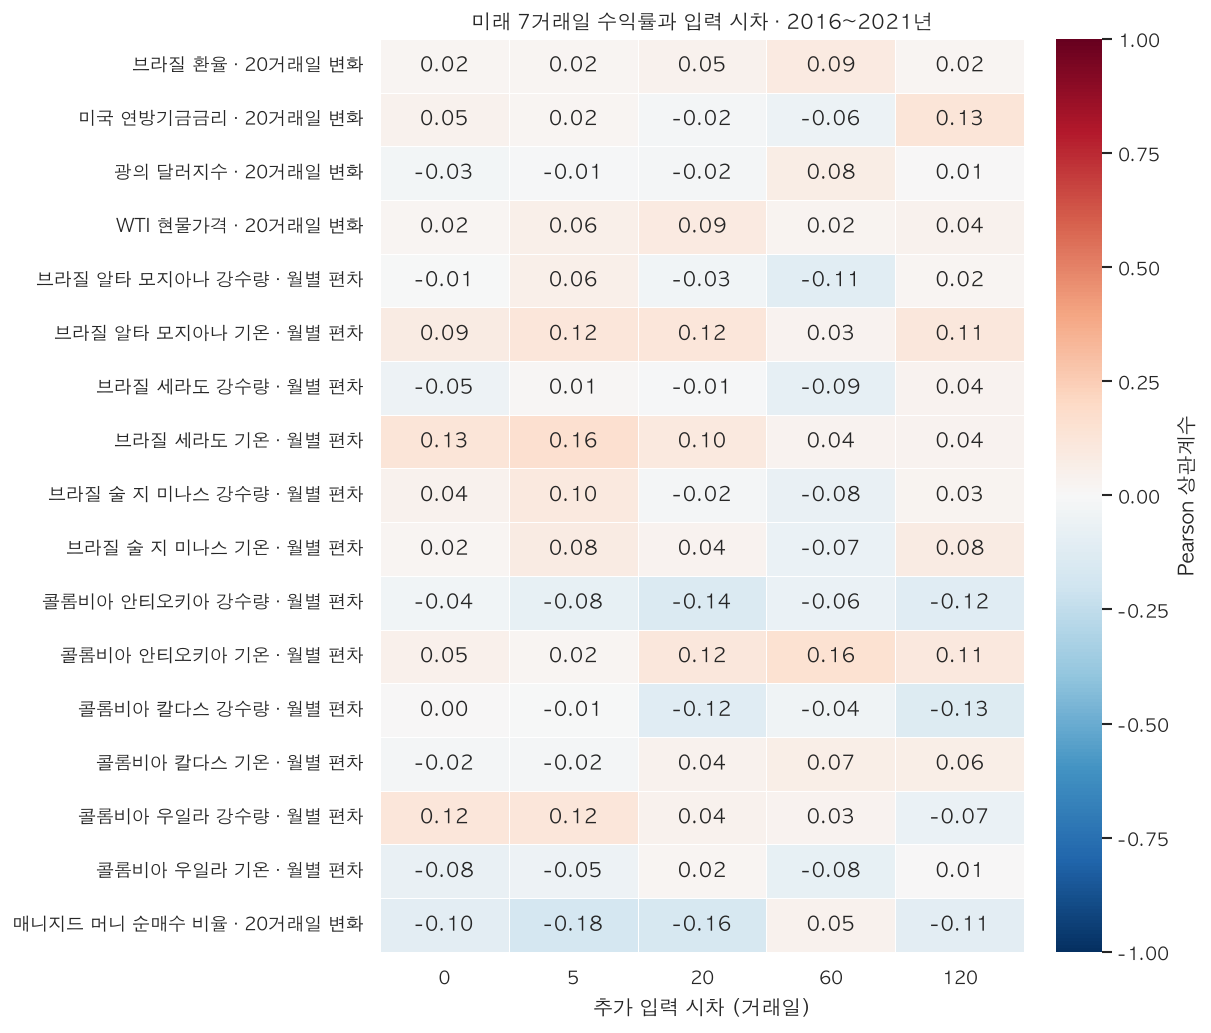

**7거래일 · Spearman으로 다시 확인**

,시차 0일,시차 5일,시차 20일,시차 60일,시차 120일
입력 변수,,,,,
브라질 환율 · 20거래일 변화,0.026,0.027,0.095,0.049,0.037
미국 연방기금금리 · 20거래일 변화,0.008,-0.026,-0.027,-0.095,0.011
광의 달러지수 · 20거래일 변화,-0.008,0.008,0.010,0.031,0.045
WTI 현물가격 · 20거래일 변화,0.027,0.016,0.051,0.064,-0.030
브라질 알타 모지아나 강수량 · 월별 편차,0.003,0.036,-0.050,-0.130,-0.027
브라질 알타 모지아나 기온 · 월별 편차,0.085,0.136,0.123,0.029,0.111
브라질 세라도 강수량 · 월별 편차,-0.036,-0.010,0.011,-0.147,-0.025
브라질 세라도 기온 · 월별 편차,0.107,0.162,0.097,0.052,0.055
브라질 술 지 미나스 강수량 · 월별 편차,0.014,0.036,-0.022,-0.086,-0.067


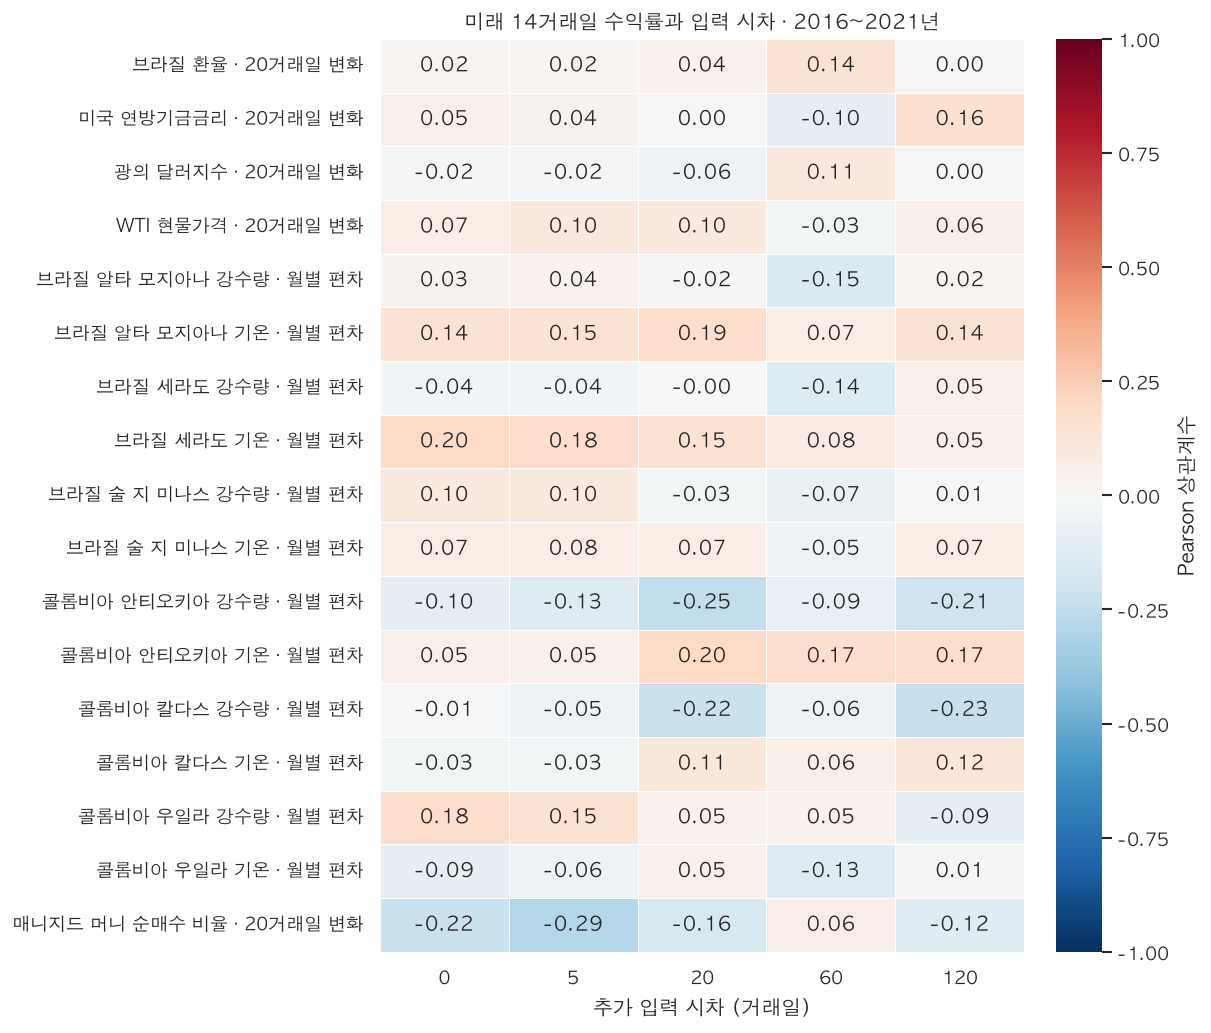

**14거래일 · Spearman으로 다시 확인**

,시차 0일,시차 5일,시차 20일,시차 60일,시차 120일
입력 변수,,,,,
브라질 환율 · 20거래일 변화,0.033,0.060,0.089,0.082,0.046
미국 연방기금금리 · 20거래일 변화,-0.040,-0.072,-0.039,-0.157,0.027
광의 달러지수 · 20거래일 변화,0.024,0.023,-0.041,0.027,0.059
WTI 현물가격 · 20거래일 변화,0.050,0.033,0.045,0.024,0.003
브라질 알타 모지아나 강수량 · 월별 편차,0.021,0.045,-0.010,-0.143,-0.011
브라질 알타 모지아나 기온 · 월별 편차,0.156,0.167,0.199,0.070,0.161
브라질 세라도 강수량 · 월별 편차,-0.035,-0.018,0.051,-0.167,0.027
브라질 세라도 기온 · 월별 편차,0.194,0.197,0.168,0.074,0.060
브라질 술 지 미나스 강수량 · 월별 편차,0.027,0.045,0.009,-0.071,-0.041


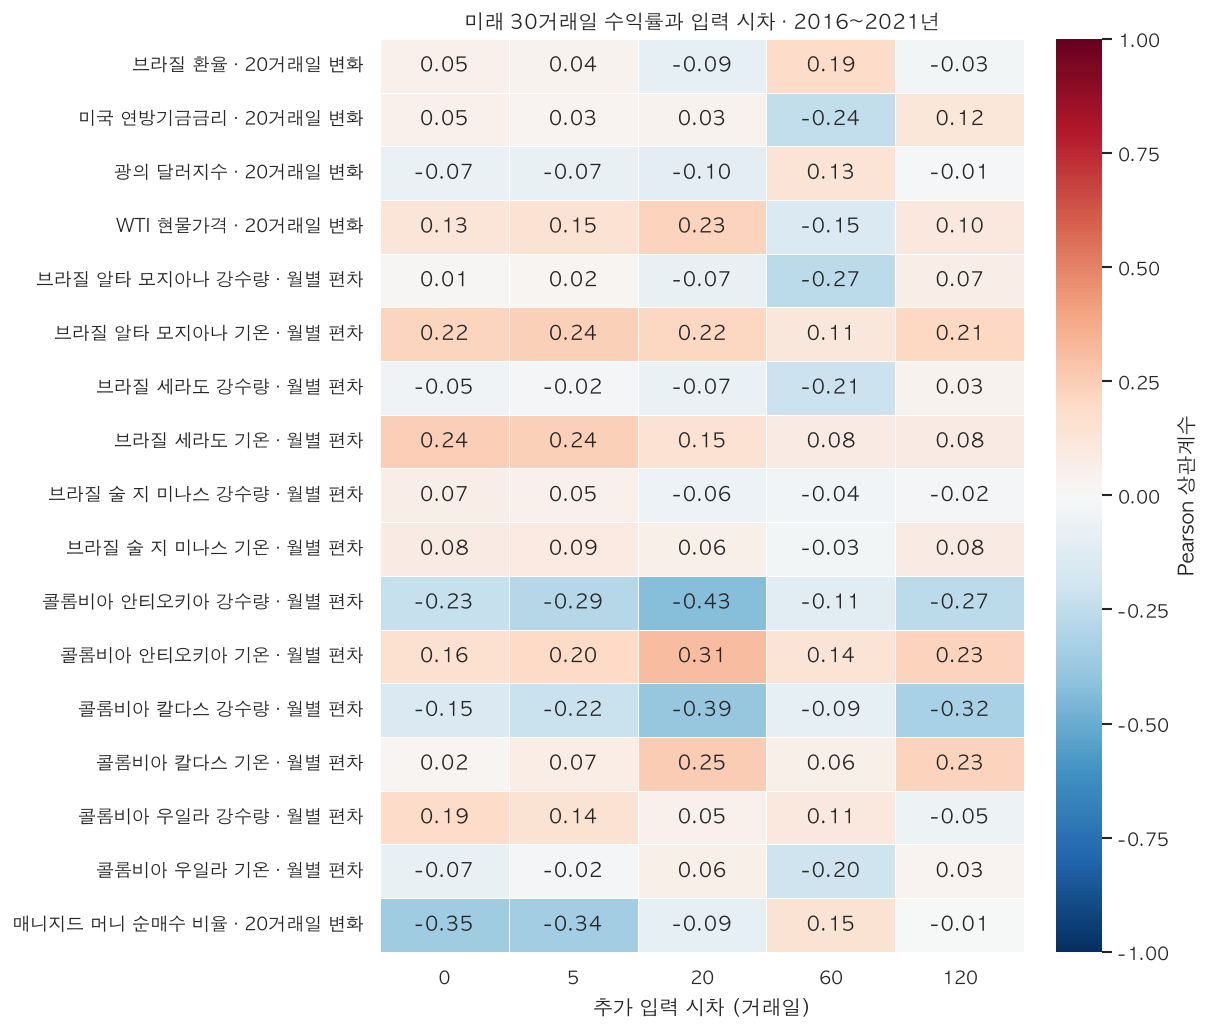

**30거래일 · Spearman으로 다시 확인**

,시차 0일,시차 5일,시차 20일,시차 60일,시차 120일
입력 변수,,,,,
브라질 환율 · 20거래일 변화,0.097,0.103,-0.042,0.110,0.022
미국 연방기금금리 · 20거래일 변화,-0.053,-0.077,-0.146,-0.245,-0.006
광의 달러지수 · 20거래일 변화,0.016,-0.009,-0.064,0.052,0.003
WTI 현물가격 · 20거래일 변화,0.104,0.107,0.150,-0.051,0.071
브라질 알타 모지아나 강수량 · 월별 편차,0.035,0.050,-0.077,-0.258,0.034
브라질 알타 모지아나 기온 · 월별 편차,0.238,0.263,0.246,0.185,0.215
브라질 세라도 강수량 · 월별 편차,0.011,0.040,-0.048,-0.244,0.061
브라질 세라도 기온 · 월별 편차,0.271,0.277,0.201,0.137,0.082
브라질 술 지 미나스 강수량 · 월별 편차,0.061,0.072,-0.023,-0.035,0.013


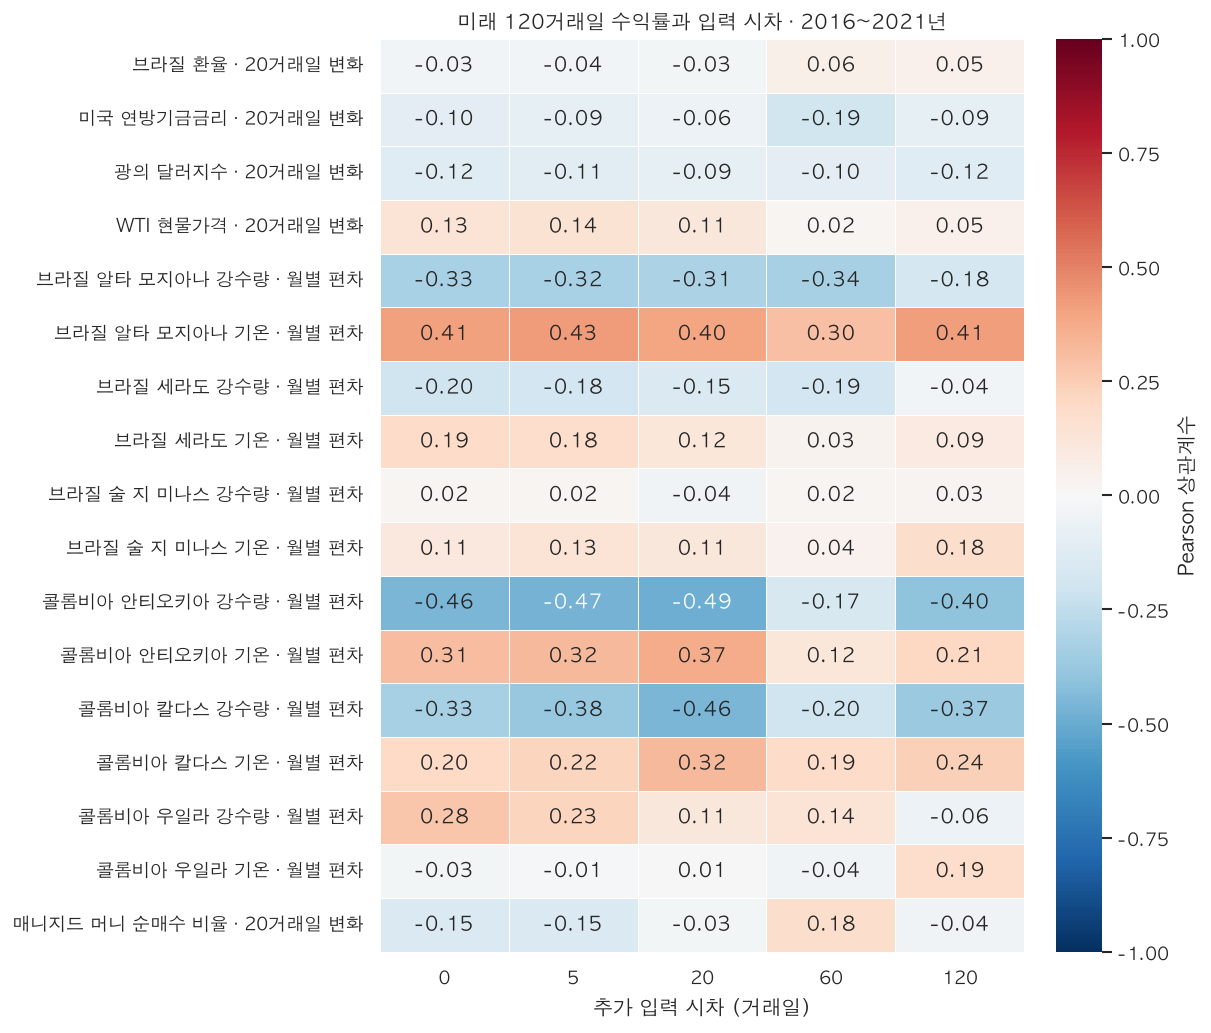

**120거래일 · Spearman으로 다시 확인**

,시차 0일,시차 5일,시차 20일,시차 60일,시차 120일
입력 변수,,,,,
브라질 환율 · 20거래일 변화,0.024,0.027,0.026,0.051,0.115
미국 연방기금금리 · 20거래일 변화,-0.249,-0.267,-0.248,-0.209,-0.112
광의 달러지수 · 20거래일 변화,-0.112,-0.092,-0.055,-0.156,-0.046
WTI 현물가격 · 20거래일 변화,0.107,0.079,0.070,0.080,0.035
브라질 알타 모지아나 강수량 · 월별 편차,-0.280,-0.289,-0.311,-0.311,-0.127
브라질 알타 모지아나 기온 · 월별 편차,0.403,0.427,0.427,0.257,0.388
브라질 세라도 강수량 · 월별 편차,-0.128,-0.132,-0.101,-0.171,0.002
브라질 세라도 기온 · 월별 편차,0.175,0.185,0.161,0.008,0.109
브라질 술 지 미나스 강수량 · 월별 편차,0.016,-0.007,-0.050,-0.024,0.054


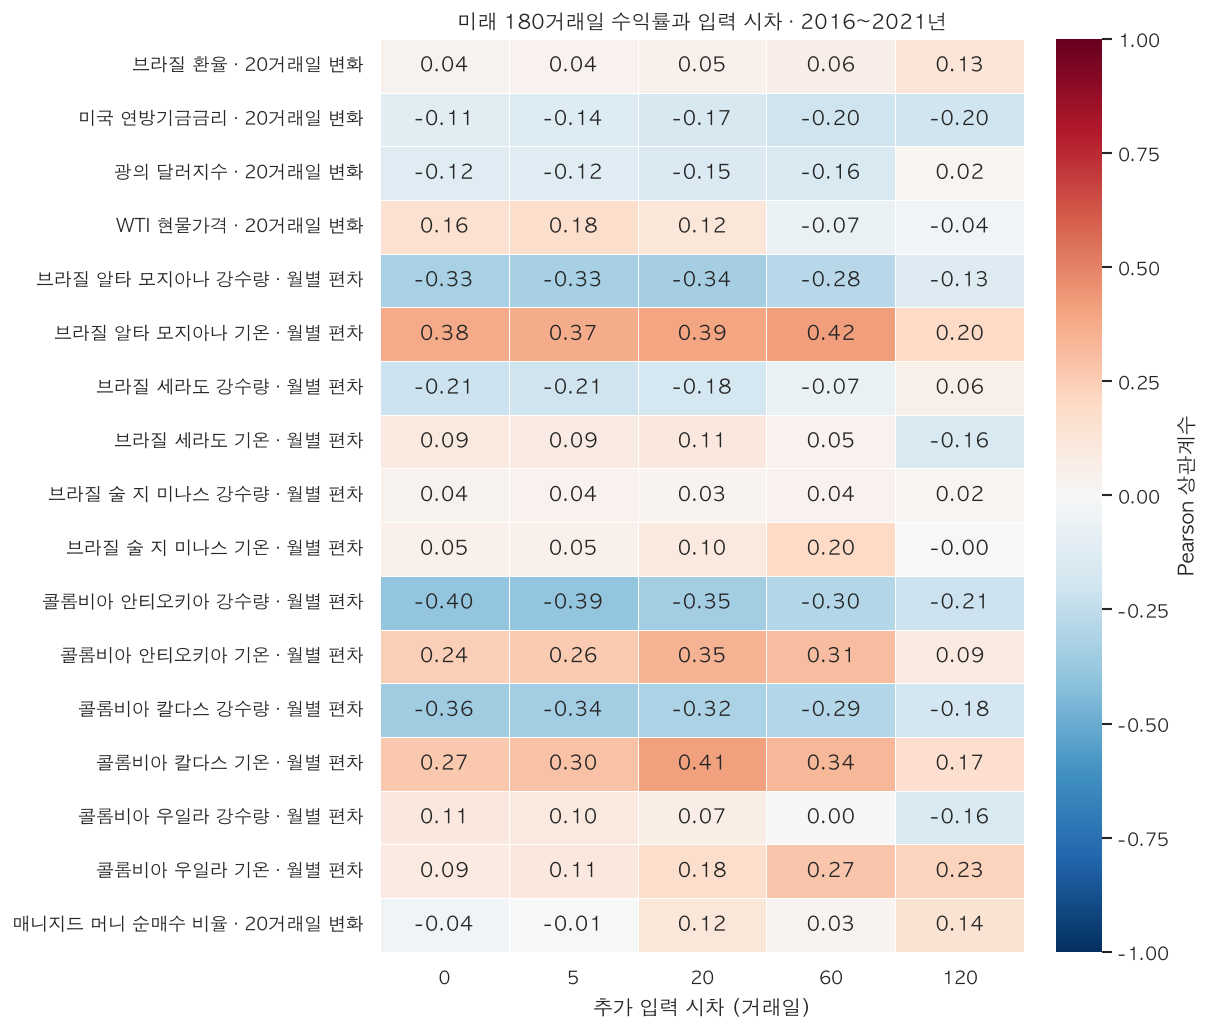

**180거래일 · Spearman으로 다시 확인**

,시차 0일,시차 5일,시차 20일,시차 60일,시차 120일
입력 변수,,,,,
브라질 환율 · 20거래일 변화,0.103,0.101,0.062,0.099,0.161
미국 연방기금금리 · 20거래일 변화,-0.276,-0.298,-0.300,-0.233,-0.124
광의 달러지수 · 20거래일 변화,-0.136,-0.151,-0.173,-0.111,0.088
WTI 현물가격 · 20거래일 변화,0.122,0.123,0.064,-0.068,-0.068
브라질 알타 모지아나 강수량 · 월별 편차,-0.245,-0.253,-0.240,-0.237,-0.098
브라질 알타 모지아나 기온 · 월별 편차,0.349,0.350,0.353,0.358,0.140
브라질 세라도 강수량 · 월별 편차,-0.121,-0.130,-0.105,-0.037,0.092
브라질 세라도 기온 · 월별 편차,0.096,0.101,0.102,0.042,-0.142
브라질 술 지 미나스 강수량 · 월별 편차,0.050,0.059,0.066,-0.019,0.009


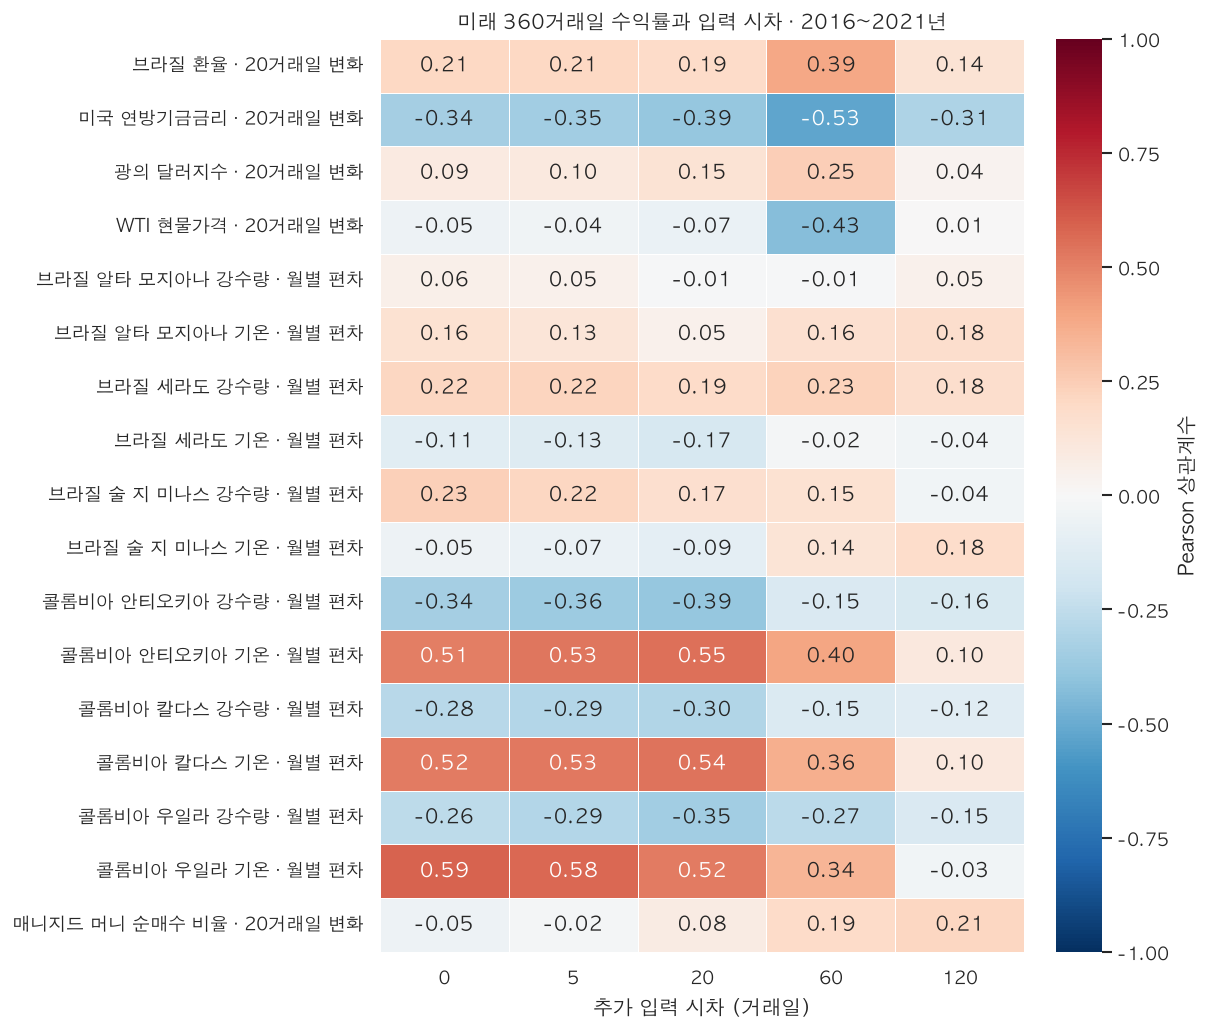

**360거래일 · Spearman으로 다시 확인**

,시차 0일,시차 5일,시차 20일,시차 60일,시차 120일
입력 변수,,,,,
브라질 환율 · 20거래일 변화,0.257,0.259,0.225,0.291,0.168
미국 연방기금금리 · 20거래일 변화,-0.239,-0.254,-0.264,-0.328,-0.156
광의 달러지수 · 20거래일 변화,0.133,0.137,0.165,0.138,0.097
WTI 현물가격 · 20거래일 변화,-0.076,-0.056,-0.073,-0.236,0.044
브라질 알타 모지아나 강수량 · 월별 편차,0.093,0.074,0.018,-0.015,0.107
브라질 알타 모지아나 기온 · 월별 편차,0.153,0.143,0.099,0.192,0.122
브라질 세라도 강수량 · 월별 편차,0.258,0.246,0.201,0.197,0.233
브라질 세라도 기온 · 월별 편차,-0.022,-0.029,-0.059,-0.016,-0.136
브라질 술 지 미나스 강수량 · 월별 편차,0.197,0.181,0.143,0.022,0.054


In [25]:
for horizon in HORIZONS:
    part = lag_corr.loc[lag_corr.horizon.eq(horizon)]
    table = part.pivot(index="feature", columns="lag", values="pearson").reindex(lag_external_features)
    fig, ax = plt.subplots(figsize=(10, 8.5), layout="constrained")
    sns.heatmap(table.rename(index=lag_labels), annot=True, fmt=".2f", cmap="RdBu_r",
                vmin=-1, vmax=1, center=0, linewidths=0.4, ax=ax,
                cbar_kws={"label": "Pearson 상관계수"})
    ax.set(title=f"미래 {horizon}거래일 수익률과 입력 시차 · 2016~2021년",
           xlabel="추가 입력 시차 (거래일)", ylabel="")
    ax.tick_params(axis="y", rotation=0)
    plt.show()
    display(Markdown(f"**{horizon}거래일 · Spearman으로 다시 확인**"))
    display(part.pivot(index="feature", columns="lag", values="spearman")
            .reindex(lag_external_features).rename(index=lag_labels, columns=lambda lag: f"시차 {lag}일")
            .rename_axis("입력 변수").rename_axis(None, axis=1).style.format("{:.3f}"))


### 가격의 최근 움직임을 함께 넣은 분포시차 회귀

회귀 하나에는 **가격 피처 4개 + 외생변수 하나의 시차 5개 + 상수항**만 넣는다. 17개 외생변수와 6개 예측 기간에 대해 따로 계산한다. 105개 피처를 한 모델에 학습시키는 실험은 아니다.

입력은 각 horizon의 공통 Train 표본에서 표준화하고, 타깃은 로그수익률 그대로 둔다. 따라서 시차 계수는 다른 입력을 고정했을 때 해당 입력 1표준편차와 연결된 수익률 차이다. 가까운 시차끼리도 상관이 높아 개별 계수는 흔들릴 수 있다.

HAC 지연 폭은 `max(20, h−1)`로 고정한다. 다섯 시차 계수가 함께 0인지 Wald 검정하고, 102개 공동검정에 FDR 보정을 적용한다. 예측 기간을 추가하면서 보정 대상도 늘었으므로 기존 4개 기간의 보정 p값은 이전 실행과 달라질 수 있다. 다른 외생변수를 모두 통제한 인과분석은 아니다. 특히 긴 중첩 구간에서는 HAC를 적용해도 대표본 근사가 불안정할 수 있어 p값은 탐색용으로만 둔다.


In [26]:
def distributed_lag_results(samples, features, price_features, lags):
    rows, coefficients = [], []
    for horizon, sample in samples.items():
        for name in features:
            columns = [*price_features, *lag_columns(name, lags)]
            x = sample[columns]
            scale = x.std(ddof=0)
            row = {"horizon": horizon, "feature": name, "n": len(sample), "wald": np.nan,
                   "joint_p": np.nan, "status": "추정 불가 · 상수 입력"}
            if scale.gt(0).all():
                design = sm.add_constant((x - x.mean()) / scale, has_constant="add")
                row["status"] = "추정 불가 · 계수 식별"
                if np.linalg.matrix_rank(design) == design.shape[1]:
                    fit = sm.OLS(sample[f"future_log_return_{horizon}d"], design).fit()
                    covariance = calendar_hac(fit, sample.session_id, maxlags=max(20, horizon - 1))
                    restriction = np.zeros((len(lags), design.shape[1]))
                    restriction[:, -len(lags):] = np.eye(len(lags))
                    row["status"] = "추정 불가 · 공동검정 공분산"
                    if np.linalg.matrix_rank(restriction @ covariance @ restriction.T) == len(lags):
                        test_result = fit.wald_test(restriction, cov_p=covariance, use_f=False, scalar=True)
                        row.update(wald=float(test_result.statistic), joint_p=float(test_result.pvalue), status="추정 완료")
                    standard_errors = np.sqrt(np.maximum(np.diag(covariance), 0))
                    for term, beta, se in zip(design.columns, fit.params, standard_errors):
                        coefficients.append({"horizon": horizon, "feature": name, "term": term,
                                             "coefficient": beta, "hac_se": se,
                                             "lower_95": beta - 1.96 * se, "upper_95": beta + 1.96 * se})
            rows.append(row)
    result = pd.DataFrame(rows)
    # 추정 불가 항목도 검정 수에서 빼지 않고, 보정 후 다시 빈칸으로 표시한다.
    result["fdr_p"] = multipletests(result.joint_p.fillna(1), method="fdr_bh")[1]
    result.loc[result.joint_p.isna(), "fdr_p"] = np.nan
    return result, pd.DataFrame(coefficients, columns=[
        "horizon", "feature", "term", "coefficient", "hac_se", "lower_95", "upper_95"
    ])


lag_dlm, lag_dlm_coefficients = distributed_lag_results(
    lag_train_samples, lag_external_features, PRICE_FEATURES, INPUT_LAGS
)
assert len(lag_dlm) == len(lag_external_features) * len(HORIZONS)
lag_summary = lag_peaks.merge(lag_dlm, on=["horizon", "feature", "n"], validate="one_to_one")


In [27]:
for horizon in HORIZONS:
    display(Markdown(f"**{horizon}거래일 · 시차 후보와 공동검정**"))
    table = lag_summary.loc[lag_summary.horizon.eq(horizon)].set_index("feature").reindex(lag_external_features)
    display(table[["n", "lag", "pearson", "spearman", "fdr_p", "status"]]
            .rename(index=lag_labels, columns={"n": "표본 수", "lag": "상관 최대 후보 시차",
                    "pearson": "Pearson", "spearman": "Spearman", "fdr_p": "공동검정 보정 p값", "status": "추정 상태"})
            .rename_axis("입력 변수").style.format({"Pearson": "{:.3f}", "Spearman": "{:.3f}",
                                                     "공동검정 보정 p값": "{:.3g}"}, na_rep="추정 불가"))
    # 상수·가격 통제변수까지 포함한 전체 계수는 lag_dlm_coefficients에 남긴다.
    coef = lag_dlm_coefficients.loc[lag_dlm_coefficients.horizon.eq(horizon)].copy()
    coef = coef.loc[coef.term.str.contains("__lag_")]
    coef["lag"] = coef.term.str.rsplit("_", n=1).str[-1].astype(int)
    display(Markdown("입력을 각각 1표준편차로 맞춘 시차 계수 · 단위: 로그수익률"))
    display(coef.pivot(index="feature", columns="lag", values="coefficient")
            .reindex(index=lag_external_features, columns=INPUT_LAGS)
            .rename(index=lag_labels, columns=lambda lag: f"시차 {lag}일")
            .rename_axis("입력 변수").rename_axis(None, axis=1).style.format("{:+.4f}", na_rep="추정 불가"))


# 다시 열었을 때도 모든 계수를 볼 수 있게 하되 긴 표는 접어 둔다.
coefficient_display = lag_dlm_coefficients.copy()
coefficient_display["feature"] = coefficient_display.feature.map(lag_labels)
coefficient_display["term"] = coefficient_display.term.map(
    lambda term: f"입력 시차 {term.rsplit('_', 1)[-1]}일" if "__lag_" in term
    else ("상수항" if term == "const" else feature_labels[term])
)
coefficient_display = coefficient_display.rename(columns={
    "horizon": "예측 기간 (거래일)", "feature": "입력 변수", "term": "회귀 항",
    "coefficient": "계수", "hac_se": "HAC 표준오차", "lower_95": "95% 구간 하한", "upper_95": "95% 구간 상한",
})
display(HTML("<details><summary>전체 회귀계수 · 상수항·가격 통제변수·입력 시차</summary>"
             "<p>95% 구간은 개별 계수의 HAC 근사 구간이며 다중검정 보정 전입니다.</p>"
             + coefficient_display.to_html(index=False, float_format=lambda value: f"{value:.6f}")
             + "</details>"))


**7거래일 · 시차 후보와 공동검정**

,표본 수,상관 최대 후보 시차,Pearson,Spearman,공동검정 보정 p값,추정 상태
입력 변수,,,,,,
브라질 환율 · 20거래일 변화,1290,60,0.090,0.049,0.714,추정 완료
미국 연방기금금리 · 20거래일 변화,1290,120,0.129,0.011,0.104,추정 완료
광의 달러지수 · 20거래일 변화,1290,60,0.078,0.031,0.686,추정 완료
WTI 현물가격 · 20거래일 변화,1290,20,0.088,0.051,0.292,추정 완료
브라질 알타 모지아나 강수량 · 월별 편차,1290,60,-0.114,-0.130,0.12,추정 완료
브라질 알타 모지아나 기온 · 월별 편차,1290,20,0.125,0.123,0.0867,추정 완료
브라질 세라도 강수량 · 월별 편차,1290,60,-0.087,-0.147,0.114,추정 완료
브라질 세라도 기온 · 월별 편차,1290,5,0.160,0.162,0.104,추정 완료
브라질 술 지 미나스 강수량 · 월별 편차,1290,5,0.100,0.036,0.398,추정 완료


입력을 각각 1표준편차로 맞춘 시차 계수 · 단위: 로그수익률

,시차 0일,시차 5일,시차 20일,시차 60일,시차 120일
입력 변수,,,,,
브라질 환율 · 20거래일 변화,+0.0015,-0.0000,+0.0028,+0.0051,+0.0008
미국 연방기금금리 · 20거래일 변화,+0.0024,-0.0002,-0.0011,-0.0039,+0.0082
광의 달러지수 · 20거래일 변화,-0.0032,+0.0029,-0.0019,+0.0045,+0.0005
WTI 현물가격 · 20거래일 변화,-0.0000,+0.0031,+0.0051,+0.0036,+0.0030
브라질 알타 모지아나 강수량 · 월별 편차,-0.0065,+0.0086,-0.0034,-0.0061,+0.0014
브라질 알타 모지아나 기온 · 월별 편차,-0.0009,+0.0050,+0.0056,+0.0008,+0.0060
브라질 세라도 강수량 · 월별 편차,-0.0065,+0.0043,-0.0013,-0.0052,+0.0034
브라질 세라도 기온 · 월별 편차,+0.0018,+0.0069,+0.0039,+0.0010,+0.0030
브라질 술 지 미나스 강수량 · 월별 편차,-0.0031,+0.0077,-0.0026,-0.0036,+0.0014


**14거래일 · 시차 후보와 공동검정**

...

**360거래일 · 시차 후보와 공동검정**

,표본 수,상관 최대 후보 시차,Pearson,Spearman,공동검정 보정 p값,추정 상태
입력 변수,,,,,,
브라질 환율 · 20거래일 변화,938,60,0.387,0.291,5.37e-12,추정 완료
미국 연방기금금리 · 20거래일 변화,938,60,-0.526,-0.328,1.85e-136,추정 완료
광의 달러지수 · 20거래일 변화,938,60,0.246,0.138,0.0582,추정 완료
WTI 현물가격 · 20거래일 변화,938,60,-0.425,-0.236,0.000944,추정 완료
브라질 알타 모지아나 강수량 · 월별 편차,938,0,0.060,0.093,0.058,추정 완료
브라질 알타 모지아나 기온 · 월별 편차,938,120,0.178,0.122,1.42e-12,추정 완료
브라질 세라도 강수량 · 월별 편차,938,60,0.227,0.197,5.21e-06,추정 완료
브라질 세라도 기온 · 월별 편차,938,20,-0.167,-0.059,0.000944,추정 완료
브라질 술 지 미나스 강수량 · 월별 편차,938,0,0.235,0.197,0.0956,추정 완료


입력을 각각 1표준편차로 맞춘 시차 계수 · 단위: 로그수익률

,시차 0일,시차 5일,시차 20일,시차 60일,시차 120일
입력 변수,,,,,
브라질 환율 · 20거래일 변화,+0.0274,+0.0011,+0.0511,+0.1078,+0.0194
미국 연방기금금리 · 20거래일 변화,-0.0485,+0.0331,-0.0862,-0.1422,+0.0031
광의 달러지수 · 20거래일 변화,-0.0135,+0.0074,+0.0251,+0.0883,+0.0094
WTI 현물가격 · 20거래일 변화,+0.0522,+0.0025,+0.0193,-0.1077,+0.0010
브라질 알타 모지아나 강수량 · 월별 편차,+0.0189,-0.0107,-0.0374,-0.0089,+0.0372
브라질 알타 모지아나 기온 · 월별 편차,+0.0528,+0.0143,+0.0081,+0.0385,+0.0394
브라질 세라도 강수량 · 월별 편차,+0.0150,+0.0016,-0.0159,+0.0448,+0.0656
브라질 세라도 기온 · 월별 편차,+0.0148,-0.0298,-0.0479,-0.0289,-0.0226
브라질 술 지 미나스 강수량 · 월별 편차,+0.0388,-0.0076,-0.0103,+0.0593,-0.0055


예측 기간 (거래일),입력 변수,회귀 항,계수,HAC 표준오차,95% 구간 하한,95% 구간 상한
7,브라질 환율 · 20거래일 변화,상수항,0.002906,0.003634,-0.004215,0.010028
7,브라질 환율 · 20거래일 변화,1거래일 로그수익률,0.001106,0.001190,-0.001227,0.003440
7,브라질 환율 · 20거래일 변화,5거래일 로그수익률,-0.004964,0.003165,-0.011167,0.001239
7,브라질 환율 · 20거래일 변화,20거래일 로그수익률,0.000358,0.004254,-0.007979,0.008695
7,브라질 환율 · 20거래일 변화,20거래일 변동성,-0.000215,0.004014,-0.008084,0.007653
7,브라질 환율 · 20거래일 변화,입력 시차 0일,0.001521,0.005139,-0.008550,0.011593
7,브라질 환율 · 20거래일 변화,입력 시차 5일,-0.000039,0.005771,-0.011351,0.011273
7,브라질 환율 · 20거래일 변화,입력 시차 20일,0.002816,0.004617,-0.006232,0.011864
7,브라질 환율 · 20거래일 변화,입력 시차 60일,0.005123,0.003703,-0.002135,0.012381
7,브라질 환율 · 20거래일 변화,입력 시차 120일,0.000812,0.003941,-0.006911,0.008536


### 겹치는 수익률 때문에 관계가 커 보인 건 아닐까?

120거래일 수익률 두 개를 하루 간격으로 만들면 119일의 가격 변동을 공유한다. 일별 행 수를 독립 관측 수처럼 읽을 수 없는 이유다. 그렇다고 `행 수 / 120`을 모든 회귀의 정확한 유효 표본 수나 자유도로 볼 수도 없다.

앞에서 찾은 시차 후보를 그대로 두고, 이번에는 h거래일마다 한 번씩 뽑아 본다. 원래 거래일 순번 기준 시작점은 `0`, `floor(h/3)`, `floor(2h/3)` 세 개로 고정한다. 결측을 지운 뒤 h행마다 뽑는 방식은 쓰지 않는다. 아래는 시작점에 따른 민감도 확인이며, 서로 다른 시작점의 표본을 합쳐 독립 표본이 늘었다고 계산하지 않는다.

180·360일은 비중첩 표본이 특히 적다. 표본이 3개 미만인 시작점은 상관계수를 계산하지 않고, 3개 이상이어도 표본 수와 함께 읽는다. 계산할 수 없는 시작점을 관계가 없는 것으로 처리하지 않는다.


In [28]:
def nonoverlap_sensitivity(samples, peaks):
    rows = []
    for horizon, sample in samples.items():
        offsets = (0, horizon // 3, 2 * horizon // 3)
        for peak in peaks.loc[peaks.horizon.eq(horizon)].itertuples():
            column = f"{peak.feature}__lag_{peak.lag}"
            for offset in offsets:
                part = sample.loc[sample.session_id.mod(horizon).eq(offset)]
                assert np.all(np.diff(part.session_id) >= horizon)
                assert (part[f"target_date_{horizon}"].iloc[:-1].to_numpy() <= part.date.iloc[1:].to_numpy()).all()
                enough = len(part) >= 3 and part[column].nunique() > 1 and part[f"future_log_return_{horizon}d"].nunique() > 1
                rows.append({"horizon": horizon, "feature": peak.feature, "lag": peak.lag,
                             "offset": offset, "n": len(part), "full_pearson": peak.pearson,
                             "pearson": part[column].corr(part[f"future_log_return_{horizon}d"]) if enough else np.nan})
    return pd.DataFrame(rows)


lag_nonoverlap = nonoverlap_sensitivity(lag_train_samples, lag_peaks)
lag_nonoverlap["same_sign"] = lag_nonoverlap.pearson.notna() & (
    np.sign(lag_nonoverlap.pearson) == np.sign(lag_nonoverlap.full_pearson)
)
lag_sensitivity = lag_nonoverlap.groupby(["horizon", "feature"], sort=False).agg(
    lag=("lag", "first"), full_pearson=("full_pearson", "first"),
    n_min=("n", "min"), n_max=("n", "max"), r_min=("pearson", "min"), r_max=("pearson", "max"),
    sign_matches=("same_sign", "sum"), estimable=("pearson", "count"),
).reset_index()
for horizon in HORIZONS:
    display(Markdown(f"**{horizon}거래일 · 비중첩 시작점 3개를 바꿔 본 결과**"))
    part = lag_sensitivity.loc[lag_sensitivity.horizon.eq(horizon)].set_index("feature").reindex(lag_external_features)
    table = pd.DataFrame({"후보 시차": part.lag, "전체 Pearson": part.full_pearson,
                          "시작점별 표본 수": part.n_min.astype(str) + "~" + part.n_max.astype(str),
                          "비중첩 r 최솟값": part.r_min, "비중첩 r 최댓값": part.r_max,
                          "부호 일치 / 3": part.sign_matches, "계산 가능 / 3": part.estimable})
    display(table.rename(index=lag_labels).rename_axis("입력 변수").style.format(
        {"전체 Pearson": "{:.3f}", "비중첩 r 최솟값": "{:.3f}", "비중첩 r 최댓값": "{:.3f}"}, na_rep="계산 불가"
    ))


**7거래일 · 비중첩 시작점 3개를 바꿔 본 결과**

,후보 시차,전체 Pearson,시작점별 표본 수,비중첩 r 최솟값,비중첩 r 최댓값,부호 일치 / 3,계산 가능 / 3
입력 변수,,,,,,,
브라질 환율 · 20거래일 변화,60,0.090,183~185,0.032,0.140,3,3
미국 연방기금금리 · 20거래일 변화,120,0.129,183~185,0.102,0.140,3,3
광의 달러지수 · 20거래일 변화,60,0.078,183~185,0.073,0.086,3,3
WTI 현물가격 · 20거래일 변화,20,0.088,183~185,0.038,0.109,3,3
브라질 알타 모지아나 강수량 · 월별 편차,60,-0.114,183~185,-0.158,-0.057,3,3
브라질 알타 모지아나 기온 · 월별 편차,20,0.125,183~185,0.069,0.190,3,3
브라질 세라도 강수량 · 월별 편차,60,-0.087,183~185,-0.147,-0.030,3,3
브라질 세라도 기온 · 월별 편차,5,0.160,183~185,0.126,0.151,3,3
브라질 술 지 미나스 강수량 · 월별 편차,5,0.100,183~185,0.091,0.122,3,3


**14거래일 · 비중첩 시작점 3개를 바꿔 본 결과**

,후보 시차,전체 Pearson,시작점별 표본 수,비중첩 r 최솟값,비중첩 r 최댓값,부호 일치 / 3,계산 가능 / 3
입력 변수,,,,,,,
브라질 환율 · 20거래일 변화,60,0.144,90~92,0.126,0.170,3,3
미국 연방기금금리 · 20거래일 변화,120,0.159,90~92,0.115,0.192,3,3
광의 달러지수 · 20거래일 변화,60,0.108,90~92,0.107,0.157,3,3
WTI 현물가격 · 20거래일 변화,5,0.103,90~92,0.098,0.161,3,3
브라질 알타 모지아나 강수량 · 월별 편차,60,-0.153,90~92,-0.232,-0.066,3,3
브라질 알타 모지아나 기온 · 월별 편차,20,0.186,90~92,0.098,0.284,3,3
브라질 세라도 강수량 · 월별 편차,60,-0.136,90~92,-0.265,-0.051,3,3
브라질 세라도 기온 · 월별 편차,0,0.199,90~92,0.169,0.250,3,3
브라질 술 지 미나스 강수량 · 월별 편차,5,0.101,90~92,0.085,0.191,3,3


**30거래일 · 비중첩 시작점 3개를 바꿔 본 결과**

...

,후보 시차,전체 Pearson,시작점별 표본 수,비중첩 r 최솟값,비중첩 r 최댓값,부호 일치 / 3,계산 가능 / 3
입력 변수,,,,,,,
브라질 환율 · 20거래일 변화,60,0.056,9~11,-0.200,0.230,2,3
미국 연방기금금리 · 20거래일 변화,60,-0.190,9~11,-0.489,-0.033,3,3
광의 달러지수 · 20거래일 변화,0,-0.122,9~11,-0.344,0.042,2,3
WTI 현물가격 · 20거래일 변화,5,0.143,9~11,-0.062,0.264,2,3
브라질 알타 모지아나 강수량 · 월별 편차,60,-0.335,9~11,-0.209,-0.076,3,3
브라질 알타 모지아나 기온 · 월별 편차,5,0.426,9~11,0.076,0.645,3,3
브라질 세라도 강수량 · 월별 편차,0,-0.202,9~11,-0.632,-0.258,3,3
브라질 세라도 기온 · 월별 편차,0,0.189,9~11,-0.164,0.146,2,3
브라질 술 지 미나스 강수량 · 월별 편차,20,-0.039,9~11,-0.310,0.362,1,3


**180거래일 · 비중첩 시작점 3개를 바꿔 본 결과**

,후보 시차,전체 Pearson,시작점별 표본 수,비중첩 r 최솟값,비중첩 r 최댓값,부호 일치 / 3,계산 가능 / 3
입력 변수,,,,,,,
브라질 환율 · 20거래일 변화,120,0.126,6~7,0.088,0.737,3,3
미국 연방기금금리 · 20거래일 변화,60,-0.205,6~7,-0.427,-0.257,3,3
광의 달러지수 · 20거래일 변화,60,-0.157,6~7,-0.495,0.114,2,3
WTI 현물가격 · 20거래일 변화,5,0.179,6~7,-0.113,0.223,2,3
브라질 알타 모지아나 강수량 · 월별 편차,20,-0.341,6~7,-0.848,-0.010,3,3
브라질 알타 모지아나 기온 · 월별 편차,60,0.418,6~7,0.464,0.890,3,3
브라질 세라도 강수량 · 월별 편차,0,-0.213,6~7,-0.696,-0.244,3,3
브라질 세라도 기온 · 월별 편차,120,-0.160,6~7,-0.350,0.215,1,3
브라질 술 지 미나스 강수량 · 월별 편차,60,0.044,6~7,-0.412,0.583,1,3


**360거래일 · 비중첩 시작점 3개를 바꿔 본 결과**

,후보 시차,전체 Pearson,시작점별 표본 수,비중첩 r 최솟값,비중첩 r 최댓값,부호 일치 / 3,계산 가능 / 3
입력 변수,,,,,,,
브라질 환율 · 20거래일 변화,60,0.387,2~3,-0.943,0.987,1,2
미국 연방기금금리 · 20거래일 변화,60,-0.526,2~3,-0.978,-0.978,1,1
광의 달러지수 · 20거래일 변화,60,0.246,2~3,-0.681,0.132,1,2
WTI 현물가격 · 20거래일 변화,60,-0.425,2~3,-0.586,-0.332,2,2
브라질 알타 모지아나 강수량 · 월별 편차,0,0.060,2~3,-0.815,0.060,1,2
브라질 알타 모지아나 기온 · 월별 편차,120,0.178,2~3,0.815,0.821,2,2
브라질 세라도 강수량 · 월별 편차,60,0.227,2~3,-0.338,0.657,1,2
브라질 세라도 기온 · 월별 편차,20,-0.167,2~3,-0.529,0.854,1,2
브라질 술 지 미나스 강수량 · 월별 편차,0,0.235,2~3,0.015,0.623,2,2


## 5. 관찰 결과와 다음에 확인할 것

상관이 큰 시차는 다음 예측 실험의 후보로만 남긴다. 같은 Train에서 후보를 찾고 다시 설명했으므로 독립적인 성능 검증은 아니다. 낮은 단순 상관만으로 비선형 정보까지 없다고 판단하지도 않는다.


In [29]:
lag_notes = []
for horizon in HORIZONS:
    part = lag_summary.loc[lag_summary.horizon.eq(horizon)]
    strongest = part.loc[part.pearson.abs().idxmax()]
    sensitivity = lag_sensitivity.loc[lag_sensitivity.horizon.eq(horizon)]
    lag_notes.append(
        f"- **{horizon}거래일**: 공통 표본 {int(strongest.n):,}행. "
        f"가장 큰 |Pearson|은 {lag_labels[strongest.feature]}의 시차 {int(strongest.lag)}일 "
        f"(r={strongest.pearson:+.3f}, Spearman={strongest.spearman:+.3f})였다. "
        f"비중첩 시작점마다 표본은 {int(sensitivity.n_min.min())}~{int(sensitivity.n_max.max())}개이고, "
        f"상관 계산이 가능한 시작점은 변수마다 {int(sensitivity.estimable.min())}~{int(sensitivity.estimable.max())}/3개다. "
        f"세 시작점 모두 계산 가능하고 부호도 같은 변수는 {int(sensitivity.sign_matches.eq(3).sum())}/{len(lag_external_features)}개다."
    )
display(Markdown("\n".join(lag_notes)))


- **7거래일**: 공통 표본 1,290행. 가장 큰 |Pearson|은 매니지드 머니 순매수 비율 · 20거래일 변화의 시차 5일 (r=-0.175, Spearman=-0.176)였다. 비중첩 시작점마다 표본은 183~185개이고, 상관 계산이 가능한 시작점은 변수마다 3~3/3개다. 세 시작점 모두 계산 가능하고 부호도 같은 변수는 17/17개다.
- **14거래일**: 공통 표본 1,283행. 가장 큰 |Pearson|은 매니지드 머니 순매수 비율 · 20거래일 변화의 시차 5일 (r=-0.291, Spearman=-0.250)였다. 비중첩 시작점마다 표본은 90~92개이고, 상관 계산이 가능한 시작점은 변수마다 3~3/3개다. 세 시작점 모두 계산 가능하고 부호도 같은 변수는 16/17개다.
- **30거래일**: 공통 표본 1,266행. 가장 큰 |Pearson|은 콜롬비아 안티오키아 강수량 · 월별 편차의 시차 20일 (r=-0.429, Spearman=-0.439)였다. 비중첩 시작점마다 표본은 41~44개이고, 상관 계산이 가능한 시작점은 변수마다 3~3/3개다. 세 시작점 모두 계산 가능하고 부호도 같은 변수는 14/17개다.
- **120거래일**: 공통 표본 1,178행. 가장 큰 |Pearson|은 콜롬비아 안티오키아 강수량 · 월별 편차의 시차 20일 (r=-0.487, Spearman=-0.471)였다. 비중첩 시작점마다 표본은 9~11개이고, 상관 계산이 가능한 시작점은 변수마다 3~3/3개다. 세 시작점 모두 계산 가능하고 부호도 같은 변수는 9/17개다.
- **180거래일**: 공통 표본 1,118행. 가장 큰 |Pearson|은 브라질 알타 모지아나 기온 · 월별 편차의 시차 60일 (r=+0.418, Spearman=+0.358)였다. 비중첩 시작점마다 표본은 6~7개이고, 상관 계산이 가능한 시작점은 변수마다 3~3/3개다. 세 시작점 모두 계산 가능하고 부호도 같은 변수는 10/17개다.
- **360거래일**: 공통 표본 938행. 가장 큰 |Pearson|은 콜롬비아 우일라 기온 · 월별 편차의 시차 0일 (r=+0.593, Spearman=+0.527)였다. 비중첩 시작점마다 표본은 2~3개이고, 상관 계산이 가능한 시작점은 변수마다 1~2/3개다. 세 시작점 모두 계산 가능하고 부호도 같은 변수는 0/17개다.

180일에서는 알타 모지아나 기온 편차의 시차 60일이 가장 컸다(r=0.418). 360일은 우일라 기온 편차의 시차 0일(r=0.593), 금리 변화의 시차 60일(r=-0.526)이 눈에 띄었다. 예측 기간을 늘리면서 상관 최대 변수와 시차도 바뀌었다. 기간별로 남는 예측 기준일도 다르므로 상관 크기만으로 더 긴 예측이 낫다고 비교하기는 어렵다.

180·360일은 각각 ADF p=0.411·0.802, KPSS p<0.01이었다. 비중첩 표본은 시작점별 6~7개·2~3개다. 360일 환율의 비중첩 상관은 -0.943~0.987로 방향까지 바뀌었다. HAC·FDR 보정 후 작은 p값이 나와도 이 표본으로 장기 예측력을 확정하지 않는다.

다음 모델 비교에서는 예측 기간별로 가격 유지·단변량 기준과 외생변수 추가 효과를 확인한다. 120·180·360일은 같은 6년으로 여러 시차를 찾아낸 결과라는 한계를 함께 둔다. 후속 검증 없이 큰 상관 순으로 모델의 예측 기간을 고르지는 않는다.

CatBoost·XGBoost에는 선택한 시차의 2D 입력, DLinear에는 우선 가격 이력의 3D 입력을 만든다. 공통 As-of 테이블에서 모델마다 예측 날짜·이용 가능한 과거 이력·재학습 규칙을 맞춘다. 학습 정답은 해당 시점까지 확정된 것만 쓰고, 전처리 통계도 각 학습 창에서 다시 구한다. 미래 기상 실측값은 입력에 넣지 않는다. 기존 2024~2025년 Test는 이미 확인한 구간이라는 점도 유지한다.


## 6. 기존 5거래일 모델 실험

아래는 앞서 수행한 5일 예측 실험이다. 기존 Train/Val/Test와 모델 설정을 그대로 사용한다. 새 중장기 시차 후보를 넣은 결과는 아니다. PyCaret과 CatBoost는 학습 이력·갱신 방식이 달라 기존 지표는 참고 비교로 남긴다.

### 피처 하나로 예측한 Validation R²

2016~2021년에 맞춘 단순 회귀를 2022~2023년에 적용한다. 음수인 R²는 검증 구간 실제 평균을 기준으로 한 설명력보다 낮다는 뜻이다. 이 표로 앞쪽 Train 시차 분석의 입력을 고르지는 않는다.


In [30]:
legacy_val_r2 = {}
for name in FEATURES:
    legacy_fit = sm.OLS(train[TARGET], sm.add_constant(train[[name]], has_constant="add")).fit()
    legacy_pred = legacy_fit.predict(sm.add_constant(val[[name]], has_constant="add"))
    legacy_val_r2[name] = r2_score(val[TARGET], legacy_pred)
display(pd.Series(legacy_val_r2, name="검증 수익률 R²").rename(index=short_labels)
        .rename_axis("피처").to_frame().style.format("{:.4f}"))


,검증 수익률 R²
피처,
1거래일 로그수익률,-0.0072
5거래일 로그수익률,-0.0070
20거래일 로그수익률,-0.0111
20거래일 변동성,-0.0079
브라질 환율,-0.0331
미국 연방기금금리,-0.0574
광의 달러지수,-0.0032
WTI 현물가격,-0.0451
브라질 알타 모지아나 강수량,-0.0156


### 6-1. 기준 모델 세 개

Ridge는 alpha 네 개만 비교한다. CatBoost는 깊이 4로 작게 시작하고, 검증 RMSE가 더 좋아지지 않으면 멈춘다. 테스트 결과를 보고 설정을 다시 고르지는 않는다.

방향성 정확도는 `sign(실제 수익률) == sign(예측 수익률)`의 비율이다. **0은 보합**으로 센다. 그래서 항상 0을 내는 Naive는 실제 수익률도 0일 때만 방향을 맞힌다. 이 모델의 주 비교 기준은 MAE·RMSE다.


In [31]:
ridge_trials = []
for alpha in (0.1, 1.0, 10.0, 100.0):
    candidate = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    candidate.fit(train[FEATURES], train[TARGET])
    ridge_trials.append(
        {"alpha": alpha, "val_rmse": root_mean_squared_error(val[TARGET], candidate.predict(val[FEATURES]))}
    )
ridge_trials = pd.DataFrame(ridge_trials).sort_values("val_rmse")
best_alpha = float(ridge_trials.iloc[0]["alpha"])

cat_params = dict(
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=SEED,
    thread_count=4,
    allow_writing_files=False,
    verbose=False,
)
cat_search = CatBoostRegressor(iterations=1000, **cat_params)
cat_search.fit(
    train[FEATURES],
    train[TARGET],
    eval_set=(val[FEATURES], val[TARGET]),
    early_stopping_rounds=100,
    use_best_model=True,
)
best_iterations = int(cat_search.best_iteration_) + 1
val_scores = pd.DataFrame(
    [
        {"model": "가격 유지 (수익률 0)", "val_rmse": root_mean_squared_error(val[TARGET], np.zeros(len(val)))},
        {"model": f"Ridge 회귀 (규제 강도={best_alpha:g})", "val_rmse": ridge_trials.iloc[0]["val_rmse"]},
        {
            "model": f"CatBoost (트리 {best_iterations}개)",
            "val_rmse": root_mean_squared_error(val[TARGET], cat_search.predict(val[FEATURES])),
        },
    ]
).set_index("model")
display(val_scores.round(6).rename_axis("모델").rename(columns={"val_rmse": "검증 오차 (RMSE)"}))

,검증 오차 (RMSE)
모델,
가격 유지 (수익률 0),0.047069
Ridge 회귀 (규제 강도=100),0.050050
CatBoost (트리 31개),0.047154


In [32]:
ridge = make_pipeline(StandardScaler(), Ridge(alpha=best_alpha))
ridge.fit(dev[FEATURES], dev[TARGET])
catboost = CatBoostRegressor(iterations=best_iterations, **cat_params)
catboost.fit(dev[FEATURES], dev[TARGET])

predictions = pd.DataFrame(
    {
        "Naive Persistence": np.zeros(len(test)),
        "Ridge Regression": ridge.predict(test[FEATURES]),
        "CatBoost": catboost.predict(test[FEATURES]),
    },
    index=test.index,
)
assert np.isfinite(predictions.to_numpy()).all()
metrics = pd.DataFrame(
    [
        {
            "model": name,
            "MAE": mean_absolute_error(test[TARGET], pred),
            "RMSE": root_mean_squared_error(test[TARGET], pred),
            "Directional Accuracy (%)": np.mean(np.sign(test[TARGET]) == np.sign(pred)) * 100,
        }
        for name, pred in predictions.items()
    ]
).set_index("model")
display(
    metrics.rename(index=model_labels, columns=metric_labels)
    .rename_axis("모델")
    .style.format(
        {
            metric_labels["MAE"]: "{:.6f}",
            metric_labels["RMSE"]: "{:.6f}",
            metric_labels["Directional Accuracy (%)"]: "{:.2f}",
        }
    )
)
print(f"테스트 예측 {len(test):,}건 | Ridge 규제 강도={best_alpha:g} | CatBoost 트리 {best_iterations}개")

,평균절대오차 (MAE),제곱평균제곱근오차 (RMSE),방향성 정확도 (%)
모델,,,
가격 유지 (Naive),0.042810,0.054442,0.40
Ridge 회귀,0.044329,0.057099,46.79
CatBoost,0.043006,0.054674,47.19


테스트 예측 498건 | Ridge 규제 강도=100 | CatBoost 트리 31개


### 6-2. 모델이 주로 본 피처

CatBoost의 내장 중요도(PredictionValuesChange)를 본다. 전체 피처의 합이 100이 되며, 이 중 상위 10개만 그린다. 학습한 모델이 많이 사용한 피처라는 뜻이지, 그 변수가 가격을 움직였다는 뜻은 아니다.


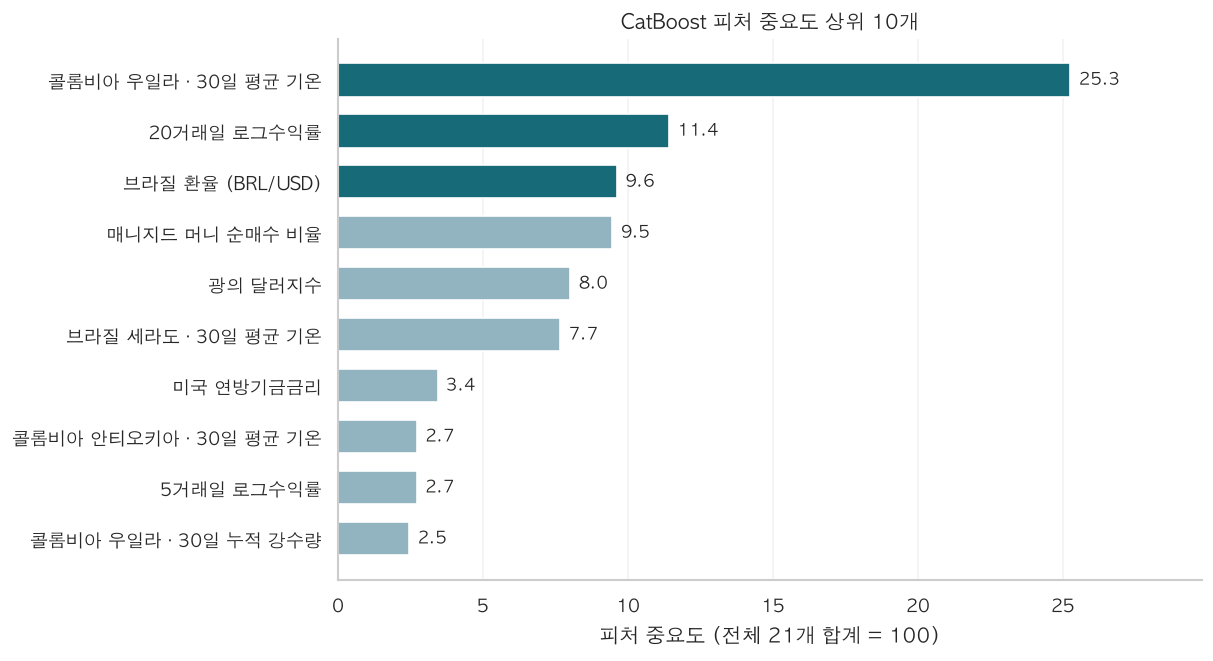

In [33]:
importance = pd.Series(catboost.feature_importances_, index=FEATURES, name="importance").sort_values(ascending=False)
top10 = importance.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5.4), layout="constrained")
bars = ax.barh(top10.index.map(feature_labels), top10.values, color=["#91B4C0"] * 7 + ["#176B78"] * 3, height=0.65)
ax.bar_label(bars, fmt="%.1f", padding=5, fontsize=10)
ax.set(title="CatBoost 피처 중요도 상위 10개", xlabel="피처 중요도 (전체 21개 합계 = 100)", ylabel="")
ax.set_xlim(0, top10.max() * 1.18)
ax.grid(axis="y", visible=False)
plt.show()

### 6-3. 예측 수익률을 가격으로 돌려 보기

예측 가격은 `Close[T] × exp(예측 수익률)`이고, **T가 아니라 T+5 거래일 날짜**에 그린다. 매일 새로 계산한 5일 앞 예측을 이어 그린 것이므로 2년치를 한 번에 예측한 곡선은 아니다. 현재 가격을 출발점으로 쓰기 때문에 선이 비슷하게 보여도, 성능은 위의 수익률 오차와 Naive 비교로 판단한다.


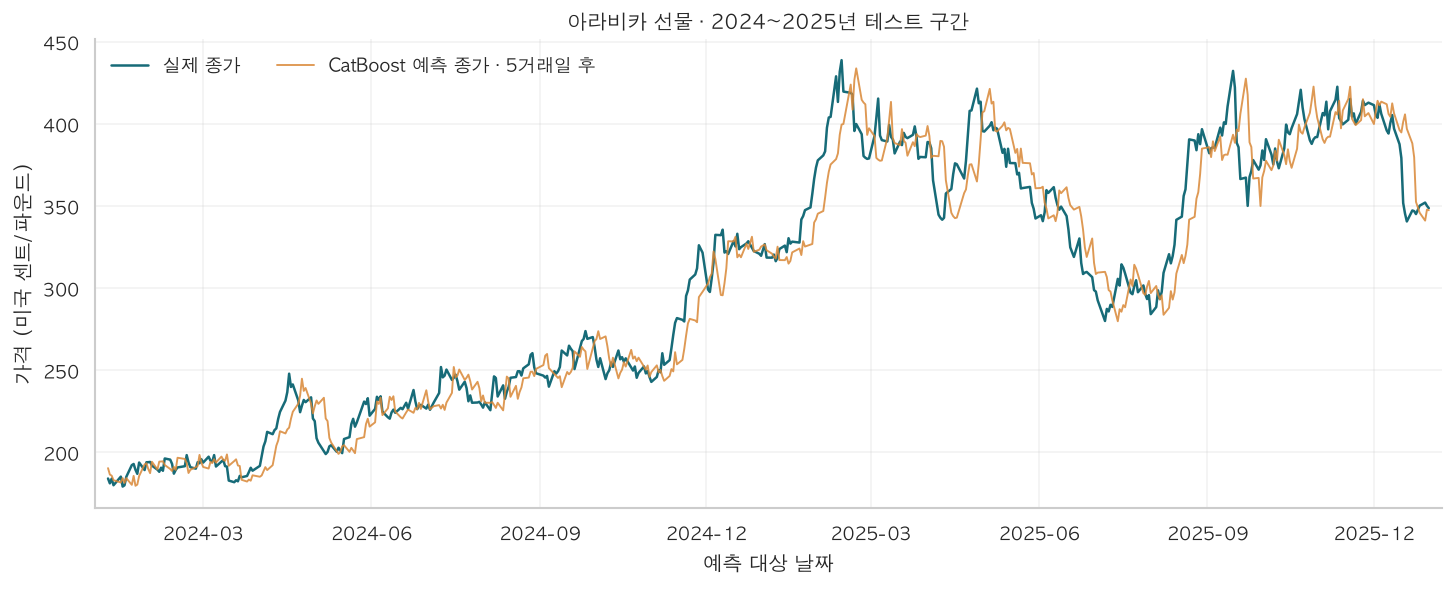

In [34]:
price_comparison = pd.DataFrame(
    {
        "target_date": test["target_date"],
        "Actual close": test["future_close"],
        "CatBoost forecast": test["close"] * np.exp(predictions["CatBoost"]),
    }
).set_index("target_date")
fig, ax = plt.subplots(figsize=(12, 4.8), layout="constrained")
ax.plot(price_comparison.index, price_comparison["Actual close"], label="실제 종가", color="#176B78", linewidth=1.5)
ax.plot(
    price_comparison.index,
    price_comparison["CatBoost forecast"],
    label="CatBoost 예측 종가 · 5거래일 후",
    color="#D98736",
    linewidth=1.15,
    alpha=0.85,
)
ax.set(title="아라비카 선물 · 2024~2025년 테스트 구간", xlabel="예측 대상 날짜", ylabel="가격 (미국 센트/파운드)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(frameon=False, loc="upper left", ncols=2)
ax.margins(x=0.01)
plt.show()

In [35]:
best_model = metrics["RMSE"].idxmin()
top_features = ", ".join(f"{feature_labels[name]} ({value:.1f})" for name, value in importance.head(3).items())
rmse_change = (metrics.loc["CatBoost", "RMSE"] / metrics.loc["Naive Persistence", "RMSE"] - 1) * 100
print(
    f"최저 RMSE 모델: {model_labels[best_model]} | CatBoost의 Naive 대비 RMSE 변화: {rmse_change:+.1f}%\n중요도 상위 피처: {top_features}"
)

최저 RMSE 모델: 가격 유지 (Naive) | CatBoost의 Naive 대비 RMSE 변화: +0.4%
중요도 상위 피처: 콜롬비아 우일라 · 30일 평균 기온 (25.3), 20거래일 로그수익률 (11.4), 브라질 환율 (BRL/USD) (9.6)


기상 버퍼를 추가해 초반 피처를 실제 관측값으로 계산했다. CatBoost는 깊이 4·트리 31개로 학습됐고, 테스트 RMSE는 Naive보다 약 0.4% 컸다.

우일라의 30일 평균 기온이 중요도 25.3으로 가장 높았다. 미래 수익률과의 단순 상관은 거의 없는데 트리 모델에서는 많이 쓰인 셈이다. 비선형 관계인지, 특정 시기의 구분에 쓰인 것인지는 이번 결과만으로 알 수 없다. 다음에는 가격 피처만 쓴 경우와 외부 피처를 더한 경우를 같은 구간에서 비교해보고 싶다.

### 6-4. 피처 그룹별 비교

기상 피처끼리 비슷하게 움직여서, 먼저 브라질 술 지 미나스와 콜롬비아 우일라만 남겨 보기로 했다. 두 곳이 각 나라의 기후를 전부 대표한다는 뜻은 아니다. VIF가 낮아지는 것과 예측 오차가 줄어드는 것도 따로 확인한다.

| 구성 | 사용하는 피처 | 개수 |
|---|---|---:|
| 구성 1 · 가격 | 1·5·20일 로그수익률, 20일 변동성 | 4 |
| 구성 2 · 가격·매크로 | 구성 1 + BRL 환율, 금리, 달러지수, WTI | 8 |
| 구성 3 · 가격·매크로·COT | 구성 2 + 매니지드 머니 순매수 비율 | 9 |
| 구성 4 · 기상 축소 | 구성 3 + 술 지 미나스·우일라의 30일 강수량·기온 | 13 |
| 전체 피처 | 가격·매크로·COT + 기상 6곳 | 21 |

앞에서 만든 `train`, `val`, `dev`, `test`를 그대로 쓴다. 피처가 적은 구성에만 더 많은 날짜를 넣으면 비교 조건이 달라져서, 모든 구성의 행도 같게 맞춘다. 아래 공선성 표는 앞선 EDA의 개발 구간과 달리 **2016~2021년 Train만** 사용한다. VIF는 각 기상 묶음 안에서 계산한다.


In [36]:
from IPython.display import Markdown

macro_features = ["brl_close", "dff", "dtwexbgs", "dcoilwtico"]
price_macro = PRICE_FEATURES + macro_features
price_macro_cot = price_macro + ["cot_net_ratio"]
reduced_weather = [
    "br_sul_minas_rain_30d", "br_sul_minas_temp_30d",
    "co_huila_rain_30d", "co_huila_temp_30d",
]
feature_sets = {
    "full": FEATURES.copy(),
    "price": PRICE_FEATURES.copy(),
    "macro": price_macro,
    "cot": price_macro_cot,
    "reduced_weather": price_macro_cot + reduced_weather,
}
set_labels = {
    "naive": "가격 유지 (Naive)",
    "full": "전체 피처",
    "price": "구성 1 · 가격",
    "macro": "구성 2 · 가격·매크로",
    "cot": "구성 3 · 가격·매크로·COT",
    "reduced_weather": "구성 4 · 기상 축소",
}
assert [len(columns) for columns in feature_sets.values()] == [21, 4, 8, 9, 13]
for columns in feature_sets.values():
    assert len(columns) == len(set(columns)) and set(columns) <= set(FEATURES)

collinearity_rows = []
for label, columns in [("기상 6곳", weather_features), ("기상 2곳", reduced_weather)]:
    x = train[columns]
    design = sm.add_constant(x).to_numpy()
    vif = [variance_inflation_factor(design, i) for i in range(1, design.shape[1])]
    corr = x.corr().to_numpy()
    collinearity_rows.append({
        "기상 구성": label,
        "피처 수": len(columns),
        "최대 VIF": max(vif),
        "최대 |상관계수|": np.abs(corr[np.triu_indices(len(columns), k=1)]).max(),
    })
collinearity_comparison = pd.DataFrame(collinearity_rows).set_index("기상 구성")
display(collinearity_comparison.style.format({"최대 VIF": "{:.2f}", "최대 |상관계수|": "{:.3f}"}))


,피처 수,최대 VIF,최대 |상관계수|
기상 구성,,,
기상 6곳,12,19.33,0.949
기상 2곳,4,2.27,0.624


### Validation에서 먼저 고르기

기존 전체 피처 모델에서 고른 **31개 트리**를 모든 구성에 고정한다. `depth=4`, `learning_rate=0.03`, `l2_leaf_reg=5`, `loss_function="RMSE"`, `seed=42`도 같다. 구성마다 조기 종료하면 트리 개수까지 달라지므로 이번에는 사용하지 않는다.

2016~2021년으로 학습하고 **2022~2023년 Validation RMSE가 가장 낮은 피처 구성**을 고른다. 값이 같으면 피처가 적은 쪽을 택한다. MAE와 방향성 정확도는 함께 보되 선택 기준을 바꾸지는 않는다. Naive보다 나은지도 별도로 확인한다.


In [37]:
ABLATION_ITERATIONS = 31


def ablation_score(frame, pred, n_features):
    assert len(pred) == len(frame) and np.isfinite(pred).all()
    return {
        "n_features": n_features,
        "MAE": mean_absolute_error(frame[TARGET], pred),
        "RMSE": root_mean_squared_error(frame[TARGET], pred),
        "Directional Accuracy (%)": np.mean(np.sign(frame[TARGET]) == np.sign(pred)) * 100,
    }


def show_ablation_table(scores):
    # Markdown 표에 필요한 값만 포맷한다. 계산에는 반올림 전 값을 쓴다.
    lines = [
        "| 구성 | 피처 수 | MAE | RMSE | 방향성 정확도 (%) |",
        "|---|---:|---:|---:|---:|",
    ]
    for name, row in scores.iterrows():
        lines.append(
            f"| {set_labels[name]} | {int(row['n_features'])} | {row['MAE']:.6f} | "
            f"{row['RMSE']:.6f} | {row['Directional Accuracy (%)']:.2f} |"
        )
    display(Markdown("\n".join(lines)))


ablation_val_models = {}
ablation_val_rows = {"naive": ablation_score(val, np.zeros(len(val)), 0)}
for name, columns in feature_sets.items():
    model = CatBoostRegressor(iterations=ABLATION_ITERATIONS, **cat_params)
    model.fit(train[columns], train[TARGET], use_best_model=False)
    assert model.tree_count_ == ABLATION_ITERATIONS
    ablation_val_models[name] = model
    ablation_val_rows[name] = ablation_score(val, model.predict(val[columns]), len(columns))
ablation_val = pd.DataFrame.from_dict(ablation_val_rows, orient="index")

selected_set = (
    ablation_val.loc[list(feature_sets)]
    .sort_values(["RMSE", "n_features"])
    .index[0]
)
selected_features = feature_sets[selected_set].copy()
show_ablation_table(ablation_val)
print(f"검증 RMSE로 선택: {set_labels[selected_set]} · {len(selected_features)}개 피처")


| 구성 | 피처 수 | MAE | RMSE | 방향성 정확도 (%) |
|---|---:|---:|---:|---:|
| 가격 유지 (Naive) | 0 | 0.037751 | 0.047069 | 0.20 |
| 전체 피처 | 21 | 0.037995 | 0.047154 | 46.17 |
| 구성 1 · 가격 | 4 | 0.038215 | 0.047334 | 46.57 |
| 구성 2 · 가격·매크로 | 8 | 0.039042 | 0.048123 | 46.17 |
| 구성 3 · 가격·매크로·COT | 9 | 0.039783 | 0.049051 | 47.38 |
| 구성 4 · 기상 축소 | 13 | 0.038572 | 0.047745 | 46.17 |

검증 RMSE로 선택: 전체 피처 · 21개 피처


### 선택을 고정한 뒤 Test 비교

위에서 고른 구성은 그대로 두고, 다섯 CatBoost를 각각 **2016~2023년 Dev 전체로 다시 학습**한다. 기존 전체 피처 모델도 같은 31개 트리로 다시 계산한다. 아래는 2024~2025년 Test 결과이며, 이 표를 보고 피처 구성을 다시 고르지 않는다. 앞선 분석에서 이미 확인한 기간이라 새로운 미사용 검증 구간은 아니다.

방향성 정확도는 앞과 같이 `sign(실제) == sign(예측)`으로 계산한다. **0은 보합**이어서 Naive는 실제 수익률도 0일 때만 맞힌다. Naive의 방향성 정확도는 50% 기준선이 아니다.


In [38]:
ablation_test_models = {}
ablation_test_predictions = pd.DataFrame({"naive": np.zeros(len(test))}, index=test.index)
ablation_test_rows = {"naive": ablation_score(test, ablation_test_predictions["naive"], 0)}
for name, columns in feature_sets.items():
    model = CatBoostRegressor(iterations=ABLATION_ITERATIONS, **cat_params)
    model.fit(dev[columns], dev[TARGET], use_best_model=False)
    assert model.tree_count_ == ABLATION_ITERATIONS
    ablation_test_models[name] = model
    ablation_test_predictions[name] = model.predict(test[columns])
    ablation_test_rows[name] = ablation_score(test, ablation_test_predictions[name], len(columns))
ablation_test = pd.DataFrame.from_dict(ablation_test_rows, orient="index")
show_ablation_table(ablation_test)
print(f"선택 구성 유지: {set_labels[selected_set]} | 재학습 {len(dev):,}행 · 테스트 {len(test):,}행")


| 구성 | 피처 수 | MAE | RMSE | 방향성 정확도 (%) |
|---|---:|---:|---:|---:|
| 가격 유지 (Naive) | 0 | 0.042810 | 0.054442 | 0.40 |
| 전체 피처 | 21 | 0.043006 | 0.054674 | 47.19 |
| 구성 1 · 가격 | 4 | 0.042743 | 0.054201 | 52.61 |
| 구성 2 · 가격·매크로 | 8 | 0.043123 | 0.054809 | 50.60 |
| 구성 3 · 가격·매크로·COT | 9 | 0.043830 | 0.055653 | 44.78 |
| 구성 4 · 기상 축소 | 13 | 0.043277 | 0.055074 | 45.78 |

선택 구성 유지: 전체 피처 | 재학습 1,923행 · 테스트 498행


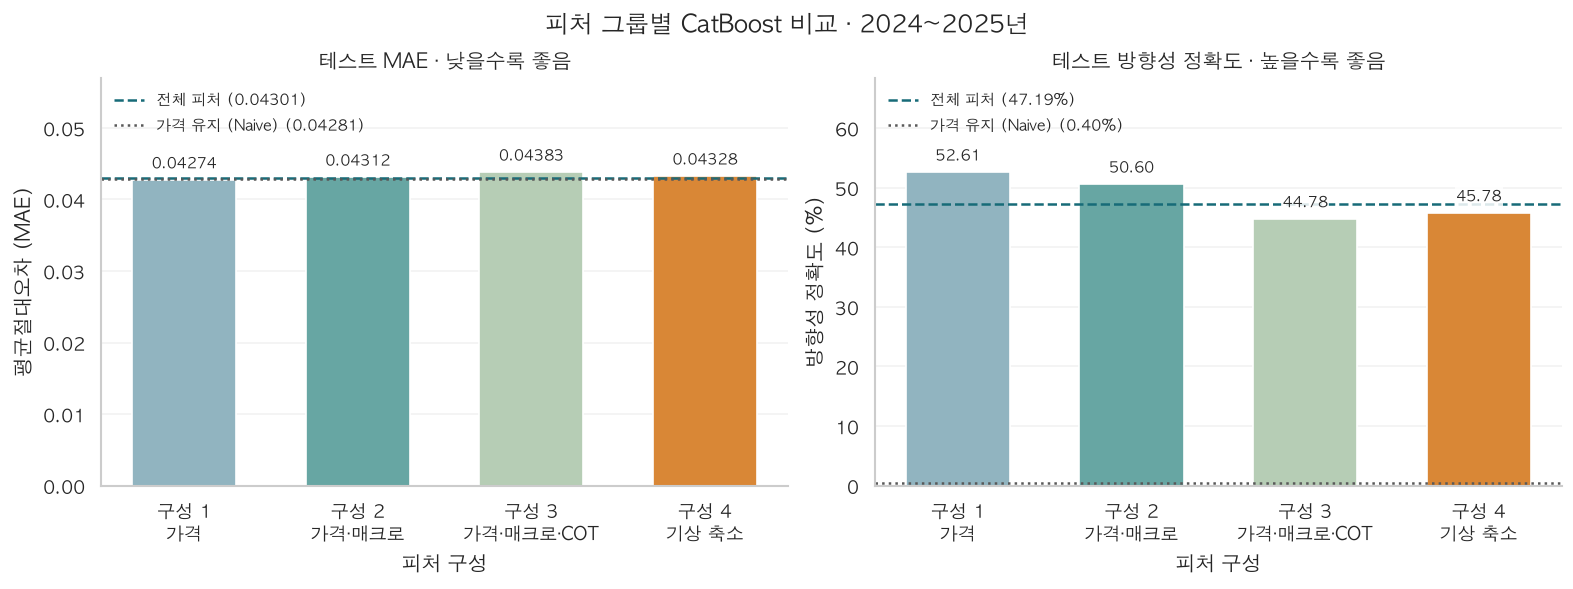

In [39]:
subset_names = ["price", "macro", "cot", "reduced_weather"]
chart_labels = ["구성 1\n가격", "구성 2\n가격·매크로", "구성 3\n가격·매크로·COT", "구성 4\n기상 축소"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout="constrained")
for ax, metric, title in zip(
    axes,
    ["MAE", "Directional Accuracy (%)"],
    ["테스트 MAE · 낮을수록 좋음", "테스트 방향성 정확도 · 높을수록 좋음"],
):
    values = ablation_test.loc[subset_names, metric]
    bars = ax.bar(chart_labels, values, color=["#91B4C0", "#67A6A3", "#B6CDB5", "#D98736"], width=0.6)
    ax.bar_label(
        bars, fmt="%.5f" if metric == "MAE" else "%.2f", padding=4, fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1},
    )
    for reference, color, linestyle in [("full", "#176B78", "--"), ("naive", "#595959", ":")]:
        value = ablation_test.loc[reference, metric]
        label = f"{set_labels[reference]} ({value:.5f})" if metric == "MAE" else f"{set_labels[reference]} ({value:.2f}%)"
        ax.axhline(value, label=label, color=color, linestyle=linestyle, linewidth=1.5)
    ax.set(title=title, xlabel="피처 구성", ylabel=metric_labels[metric])
    upper = max(values.max(), ablation_test.loc[["full", "naive"], metric].max())
    ax.set_ylim(0, upper * 1.30)
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.suptitle("피처 그룹별 CatBoost 비교 · 2024~2025년")
plt.show()


### 기상 축소 효과 읽기

구성 4와 전체 피처를 비교하면 기상 8개를 제외한 효과를, 구성 4와 구성 3을 비교하면 남긴 기상 4개의 추가 효과를 볼 수 있다. 아래 **오차 개선율은 양수면 개선, 음수면 악화**다. 방향성 정확도의 차이는 퍼센트포인트(%p)로 적는다.


In [40]:
weather_effect_rows = []
for split, scores in [("검증", ablation_val), ("테스트", ablation_test)]:
    for reference, label in [("full", "전체 → 구성 4 · 기상 8개 제외"), ("cot", "구성 3 → 구성 4 · 기상 4개 추가")]:
        base = scores.loc[reference]
        reduced = scores.loc["reduced_weather"]
        weather_effect_rows.append({
            "구간": split,
            "비교": label,
            "MAE 개선율 (%)": (base["MAE"] - reduced["MAE"]) / base["MAE"] * 100,
            "RMSE 개선율 (%)": (base["RMSE"] - reduced["RMSE"]) / base["RMSE"] * 100,
            "방향성 정확도 차이 (%p)": reduced["Directional Accuracy (%)"] - base["Directional Accuracy (%)"],
        })
weather_effects = pd.DataFrame(weather_effect_rows).set_index(["구간", "비교"])
display(weather_effects.style.format("{:+.2f}"))

selection_notes = [
    "### 이번 비교에서 고른 구성",
    f"CatBoost 구성 중 Validation RMSE가 가장 낮은 **{set_labels[selected_set]} ({len(selected_features)}개)**를 선택했다.",
]
for split, scores in [("검증", ablation_val), ("테스트", ablation_test)]:
    selected_rmse = scores.loc[selected_set, "RMSE"]
    naive_rmse = scores.loc["naive", "RMSE"]
    change = (selected_rmse / naive_rmse - 1) * 100
    comparison = "낮았다" if change < 0 else "높았다" if change > 0 else "같았다"
    selection_notes.append(
        f"{split} RMSE는 {selected_rmse:.6f}로, Naive {naive_rmse:.6f}와 비교해 "
        f"{abs(change):.2f}% {comparison}."
    )
selection_notes.append("Test 결과로 구성을 바꾸지는 않았다. 이번 선택은 이 기간과 31개 트리 설정에서의 비교 결과다.")
display(Markdown("\n\n".join(selection_notes)))


### 이번 비교에서 고른 구성

CatBoost 구성 중 Validation RMSE가 가장 낮은 **전체 피처 (21개)**를 선택했다.

검증 RMSE는 0.047154로, Naive 0.047069와 비교해 0.18% 높았다.

테스트 RMSE는 0.054674로, Naive 0.054442와 비교해 0.43% 높았다.

Test 결과로 구성을 바꾸지는 않았다. 이번 선택은 이 기간과 31개 트리 설정에서의 비교 결과다.

기상을 12개에서 4개로 줄이니 최대 VIF는 **19.33 → 2.27**, 최대 |상관계수|는 **0.949 → 0.624**로 낮아졌다. 그런데 전체 21개 피처와 비교하면 구성 4의 RMSE는 검증에서 **1.25%**, 테스트에서 **0.73%** 커졌다. 기상 중복은 줄었지만, 이번 설정에서는 오차 개선으로 이어지지 않았다.

그렇다고 남긴 기상 4개가 도움이 없었던 것은 아니다. 기상이 없는 구성 3에 더했을 때 RMSE는 검증에서 **2.66%**, 테스트에서 **1.04%** 줄었다. 기상 축소로 중복과 정보가 함께 달라졌으니, VIF 변화만으로 성능 차이의 원인을 설명하기는 어렵다.

가격만 쓴 구성 1은 테스트 RMSE **0.054201**, 방향성 정확도 **52.61%**로 가장 좋았다. 다만 검증 RMSE는 0.047334로 전체 피처의 0.047154보다 컸다. 검증 기준으로 고른 전체 21개를 유지하되, 이 모델도 두 구간 모두 Naive를 이기지 못했다는 점을 남겨둔다. 이번에는 그룹 비교까지만 하고 개별 변수 제거와 추가 튜닝은 하지 않았다.


### 6-5. 상관관계까지 같이 보고 피처 줄이기

앞에서는 산지 두 곳을 정해 줄였다. 이번에는 **학습 구간의 VIF > 5이면서 미래 수익률과의 Pearson·Spearman 상관이 모두 |r| < 0.05**인 피처만 후보로 삼는다. 후보 중 타깃과 가장 약하게 연결된 것을 하나 빼고 VIF를 다시 계산한다. 0.05는 이번 탐색 기준이지 유의확률이 아니다.

타깃과 단순 상관이 작아도 비선형 정보는 남아 있을 수 있다. 그래서 제거를 정답으로 정하지 않고, 전체 피처와 같은 날짜·31개 트리로 비교한다. 이 규칙은 Train에서만 계산하고 Validation에서 결과를 확인한다.


In [41]:
def feature_vif(frame):
    standardized = (frame - frame.mean()) / frame.std()
    matrix = sm.add_constant(standardized, has_constant="add")
    return pd.Series([variance_inflation_factor(matrix.to_numpy(), i + 1)
                      for i in range(len(frame.columns))], index=frame.columns)

selection_corr = pd.DataFrame({
    "Pearson": train[FEATURES].corrwith(train[TARGET], method="pearson"),
    "Spearman": train[FEATURES].corrwith(train[TARGET], method="spearman"),
})
weakness = selection_corr.abs().max(axis=1)
retained_features = FEATURES.copy()
removed_rows = []
while True:
    current_vif = feature_vif(train[retained_features])
    candidates = current_vif.index[(current_vif > 5) & (weakness.loc[current_vif.index] < 0.05)]
    if len(candidates) == 0:
        break
    removed = min(candidates, key=lambda name: (weakness[name], -current_vif[name]))
    removed_rows.append({"제외한 피처": feature_labels[removed], "제외 당시 VIF": current_vif[removed],
                         **selection_corr.loc[removed].to_dict()})
    retained_features.remove(removed)

display(pd.DataFrame(removed_rows).round(3))
selection_summary = pd.DataFrame({
    "전체": {"피처 수": len(FEATURES), "최대 VIF": feature_vif(train[FEATURES]).max()},
    "선택 후": {"피처 수": len(retained_features), "최대 VIF": current_vif.max()},
}).T.rename_axis("구성")
display(selection_summary.round(3))
print("전체 피처를 함께 넣은 VIF라서, 앞의 기상 12개만 계산한 VIF와는 다르다.")
print("남긴 피처:", ", ".join(feature_labels[name] for name in retained_features))

,제외한 피처,제외 당시 VIF,Pearson,Spearman
0,콜롬비아 안티오키아 · 30일 누적 강수량,5.130,0.000,0.000
1,브라질 알타 모지아나 · 30일 평균 기온,31.372,0.001,0.019
2,브라질 세라도 · 30일 평균 기온,15.190,0.015,0.036
3,콜롬비아 칼다스 · 30일 평균 기온,6.758,-0.023,-0.040
4,브라질 술 지 미나스 · 30일 누적 강수량,7.796,-0.040,-0.042


,피처 수,최대 VIF
구성,,
전체,21.0,32.581
선택 후,16.0,10.999


전체 피처를 함께 넣은 VIF라서, 앞의 기상 12개만 계산한 VIF와는 다르다.
남긴 피처: 1거래일 로그수익률, 5거래일 로그수익률, 20거래일 로그수익률, 20거래일 변동성, 브라질 환율 (BRL/USD), 미국 연방기금금리, 광의 달러지수, WTI 현물가격, 브라질 알타 모지아나 · 30일 누적 강수량, 브라질 세라도 · 30일 누적 강수량, 브라질 술 지 미나스 · 30일 평균 기온, 콜롬비아 안티오키아 · 30일 평균 기온, 콜롬비아 칼다스 · 30일 누적 강수량, 콜롬비아 우일라 · 30일 누적 강수량, 콜롬비아 우일라 · 30일 평균 기온, 매니지드 머니 순매수 비율


### 분포와 변화량에서 파생 피처 만들기

변동성은 오른쪽 꼬리가 길어서 로그로 바꿔 본다. 다만 트리 모델은 값의 순서를 주로 보니 변환 하나만으로 큰 개선을 기대하지는 않는다. 남은 기온은 학습 기간의 같은 달 평균을 빼서 평소보다 덥거나 추운 정도로 바꾼다. 월은 예측일이 아니라 기상 관측일 기준이다.

환율과 COT에는 최근 5거래일 변화, 가격에는 5일/20일 변동성 비율을 더한다. 모두 예측일 이전 값으로 계산하며, 월별 평균은 학습 데이터에서만 구한다. 날씨의 계절성을 없애는 게 항상 유리한지도 검증 결과로 판단한다.

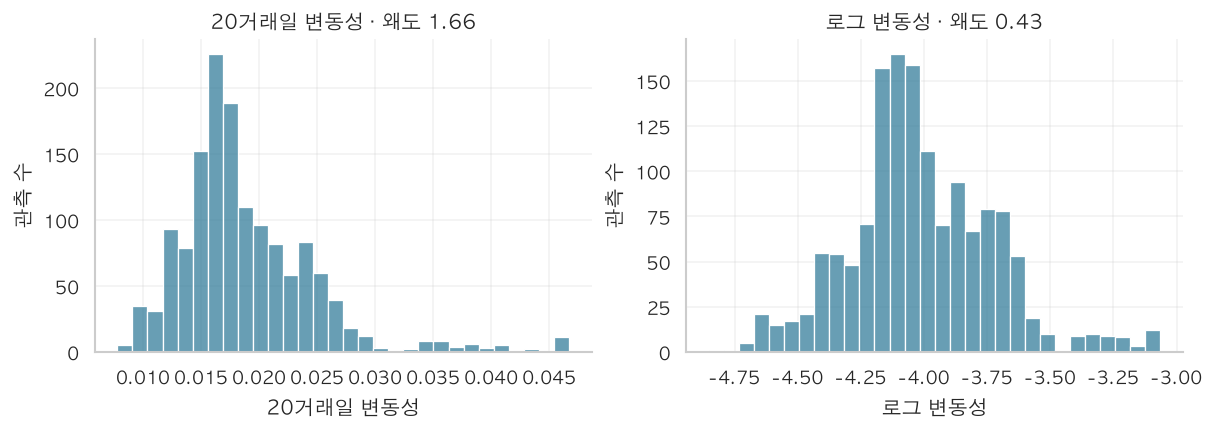

In [42]:
# 거래일이 빠진 행을 지우기 전에 변화량을 계산해야 5일 간격이 유지된다.
derived = joined.copy()
derived["brl_change_5d"] = np.log(derived.brl_close).diff(5)
derived["cot_change_5d"] = derived.cot_net_ratio.diff(5)
derived["volatility_ratio"] = derived.log_return_1d.rolling(5, min_periods=5).std() / derived.volatility_20d
new_feature_labels = {"brl_change_5d": "환율 5거래일 로그변화", "cot_change_5d": "COT 5거래일 변화",
                      "volatility_ratio": "5일/20일 변동성 비율"}

def engineer_features(reference, frame):
    output = frame[retained_features].copy()
    if "volatility_20d" in output:
        output["volatility_20d"] = np.log(output["volatility_20d"])
    for name in retained_features:
        if name.endswith("_temp_30d"):
            region = name.removesuffix("_temp_30d")
            observed = f"weather_{region}_observed_at"
            monthly_mean = reference.groupby(reference[observed].dt.month)[name].mean()
            output[name] = frame[name] - frame[observed].dt.month.map(monthly_mean)
    for name in new_feature_labels:
        output[name] = derived.loc[frame.index, name]
    assert np.isfinite(output.to_numpy()).all()
    return output

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
for ax, values, label in [(axes[0], train.volatility_20d, "20거래일 변동성"),
                           (axes[1], np.log(train.volatility_20d), "로그 변동성")]:
    sns.histplot(x=values, bins=30, ax=ax, color="#357e9b")
    ax.set(title=f"{label} · 왜도 {values.skew():.2f}", xlabel=label, ylabel="관측 수")
plt.show()

In [43]:
selection_val_rows, selection_models = {}, {}
for name in ["전체 피처", "피처 선택", "선택 + 파생"]:
    columns = FEATURES if name == "전체 피처" else retained_features
    x_train = engineer_features(train, train) if name == "선택 + 파생" else train[columns]
    x_val = engineer_features(train, val) if name == "선택 + 파생" else val[columns]
    model = CatBoostRegressor(iterations=31, **cat_params).fit(x_train, train[TARGET])
    selection_models[name] = model
    selection_val_rows[name] = ablation_score(val, model.predict(x_val), x_train.shape[1])
selection_val = pd.DataFrame(selection_val_rows).T
selection_winner = min(selection_val.index, key=lambda name: (selection_val.loc[name, "RMSE"], selection_val.loc[name, "n_features"]))
selection_test_rows = {}
for name in selection_val.index:
    columns = FEATURES if name == "전체 피처" else retained_features
    x_dev = engineer_features(dev, dev) if name == "선택 + 파생" else dev[columns]
    x_test = engineer_features(dev, test) if name == "선택 + 파생" else test[columns]
    model = CatBoostRegressor(iterations=31, **cat_params).fit(x_dev, dev[TARGET])
    selection_test_rows[name] = ablation_score(test, model.predict(x_test), x_dev.shape[1])
selection_test = pd.DataFrame(selection_test_rows).T
for label, scores in [("검증", selection_val), ("테스트", selection_test)]:
    display(Markdown(f"**{label} · 동일한 날짜, 같은 CatBoost 설정**"))
    display(scores.rename(columns={"n_features": "피처 수", **metric_labels}).round(6).rename_axis("구성"))
print(f"검증 RMSE로 선택: {selection_winner}")

**검증 · 동일한 날짜, 같은 CatBoost 설정**

,피처 수,평균절대오차 (MAE),제곱평균제곱근오차 (RMSE),방향성 정확도 (%)
구성,,,,
전체 피처,21.0,0.037995,0.047154,46.169355
피처 선택,16.0,0.038245,0.047441,46.370968
선택 + 파생,19.0,0.039119,0.048274,46.774194


**테스트 · 동일한 날짜, 같은 CatBoost 설정**

,피처 수,평균절대오차 (MAE),제곱평균제곱근오차 (RMSE),방향성 정확도 (%)
구성,,,,
전체 피처,21.0,0.043006,0.054674,47.188755
피처 선택,16.0,0.043205,0.054911,44.176707
선택 + 파생,19.0,0.042900,0.054663,50.803213


검증 RMSE로 선택: 전체 피처


In [44]:
val_change = (1 - selection_val.loc["선택 + 파생", "RMSE"] / selection_val.loc["전체 피처", "RMSE"]) * 100
test_change = (1 - selection_test.loc["선택 + 파생", "RMSE"] / selection_test.loc["전체 피처", "RMSE"]) * 100
display(Markdown(
    f"전체 {len(FEATURES)}개에서 {len(retained_features)}개를 남겼다. 파생 피처까지 적용한 구성의 RMSE 개선율은 "
    f"검증 **{val_change:+.2f}%**, 테스트 **{test_change:+.2f}%**다. 양수면 개선, 음수면 악화다. "
    f"검증 기준 선택은 **{selection_winner}**이며 테스트를 보고 바꾸지 않는다. "
    "낮아진 VIF와 예측 성능은 별개이고, 파생 피처 묶음의 효과를 특정 변수 하나의 효과로 볼 수도 없다."
))

전체 21개에서 16개를 남겼다. 파생 피처까지 적용한 구성의 RMSE 개선율은 검증 **-2.38%**, 테스트 **+0.02%**다. 양수면 개선, 음수면 악화다. 검증 기준 선택은 **전체 피처**이며 테스트를 보고 바꾸지 않는다. 낮아진 VIF와 예측 성능은 별개이고, 파생 피처 묶음의 효과를 특정 변수 하나의 효과로 볼 수도 없다.

### 6-6. PyCaret 4로 외생변수 없는 기준 모델 비교

[참고 글](https://teddylee777.github.io/machine-learning/pycaret-timeseries/)처럼 가격 하나만 넣고 간단한 모델부터 비교한다. **Python 3.12 / PyCaret 4.0.0a8**에서 `TimeSeriesExperiment(...).fit(...)`와 `create_model()`을 사용했다. 외생변수는 넣지 않는다.

가격이 없는 거래일을 임의로 채우지 않으려고 마지막 누락일 다음인 **2018-12-06**부터 연속된 가격을 쓴다. 앞의 CatBoost보다 학습 이력이 짧다. 달력 날짜 대신 거래일 순번으로 학습하고, 로그 종가의 **5거래일 뒤 한 점**을 예측한다. 예측 로그 종가에서 현재 로그 종가를 빼면 기존 타깃과 같은 5일 로그수익률이 된다.

2022~2023년에 5거래일 간격으로 학습 창을 늘려 검증하고, 모은 예측의 RMSE로 모델을 고른다. `4.0.0a8`의 내장 CV는 `alpha=0.05`로 분위수 예측을 평가하는 것을 확인했다. 이번에는 점예측이 필요하므로 PyCaret이 만든 모델에 검증 창을 직접 적용한다. 한 창에 정답이 하나라 창별 RMSE를 단순 평균하지도 않는다.


In [45]:
import os

# 임시 실행 로그 파일은 남기지 않는다.
os.environ["PYCARET_CUSTOM_LOGGING_PATH"] = os.devnull

from pycaret.time_series import TimeSeriesExperiment
from sktime.split import ExpandingWindowSplitter
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.arima import ARIMA

last_missing = prices.index[prices.close.isna()].max()
ts_prices = prices.loc[last_missing + 1:].reset_index(drop=True)
ts_y = np.log(ts_prices.close).rename("log_close")
ts_dev = ts_y.loc[ts_prices.date < TEST_START]
initial_window = int((ts_prices.date <= val.date.min()).sum())
ts_cv = ExpandingWindowSplitter(initial_window=initial_window, step_length=5, fh=[5])
ts_folds = list(ts_cv.split(ts_dev))
assert ts_y.notna().all() and ts_prices.date.iloc[0] == pd.Timestamp("2018-12-06")
for train_idx, target_idx in ts_folds:
    assert target_idx[0] - train_idx[-1] == 5
    assert VAL_START <= ts_prices.date.iloc[train_idx[-1]] < TEST_START
    assert ts_prices.date.iloc[target_idx[0]] < TEST_START

ts_experiment = TimeSeriesExperiment(fh=[5], seasonal_period=1, session_id=SEED, n_jobs=1).fit(ts_dev)
ts_candidates = {
    "가격 유지": NaiveForecaster(strategy="last"),
    "과거 평균": NaiveForecaster(strategy="mean"),
    "추세 연장": NaiveForecaster(strategy="drift"),
    "단순 지수평활": ExponentialSmoothing(trend=None, seasonal=None),
    "ARIMA(1,1,0)": ARIMA(order=(1, 1, 0), with_intercept=False, suppress_warnings=True),
}
ts_created, ts_predictions = {}, {}
ts_actual = np.array([ts_dev.iloc[te[0]] - ts_dev.iloc[tr[-1]] for tr, te in ts_folds])
for name, candidate in ts_candidates.items():
    created = ts_experiment.create_model(candidate, cross_validation=False)
    ts_created[name] = created
    predicted = []
    for train_idx, target_idx in ts_folds:
        model = created.pipeline.clone().fit(ts_dev.iloc[train_idx], fh=[5])
        forecast = model.predict(fh=[5])  # 분위수가 아닌 점예측
        assert forecast.index.equals(ts_dev.iloc[target_idx].index)
        predicted.append(forecast.iloc[0] - ts_dev.iloc[train_idx[-1]])
    ts_predictions[name] = np.array(predicted)
np.testing.assert_allclose(ts_predictions["가격 유지"], 0, atol=1e-12)

def return_metrics(actual, predicted):
    assert len(actual) == len(predicted) and np.isfinite(predicted).all()
    return {"MAE": mean_absolute_error(actual, predicted), "RMSE": root_mean_squared_error(actual, predicted),
            "Directional Accuracy (%)": np.mean(np.sign(actual) == np.sign(predicted)) * 100}

ts_val_metrics = pd.DataFrame({name: return_metrics(ts_actual, pred) for name, pred in ts_predictions.items()}).T.sort_values("RMSE")
ts_winner = ts_val_metrics.index[0]
display(ts_val_metrics.rename(columns=metric_labels).round(6).rename_axis("단변량 모델"))
print(f"검증 {len(ts_folds)}건 · 5거래일 간격 · 선택: {ts_winner}")

,평균절대오차 (MAE),제곱평균제곱근오차 (RMSE),방향성 정확도 (%)
단변량 모델,,,
가격 유지,0.036193,0.045156,1.0
단순 지수평활,0.036198,0.045159,43.0
"ARIMA(1,1,0)",0.036205,0.045162,37.0
추세 연장,0.036828,0.045549,42.0
과거 평균,0.328505,0.382973,57.0


검증 100건 · 5거래일 간격 · 선택: 가격 유지


### 고른 모델로 기존 Test 구간 확인

선택한 모델은 2023년 말까지 재학습한다. 테스트에서는 각 예측일에 도착한 가격까지만 반영하고 파라미터는 다시 고르지 않는다. 매일 계산하는 5거래일 앞 예측이며, 앞의 모델과 동일한 498개 정답에 맞춘다. 가격 유지의 방향성 정확도는 ‘실제 보합 비율’이라서 50% 기준선으로 읽지 않는다. 이 Test는 앞에서 이미 본 기간이다.

,평균절대오차 (MAE),제곱평균제곱근오차 (RMSE),방향성 정확도 (%)
모델,,,
가격 유지 (기준),0.042810,0.054442,0.401606
PyCaret 선택 · 가격 유지,0.042810,0.054442,0.401606
전체 피처 CatBoost (참고),0.043006,0.054674,47.188755


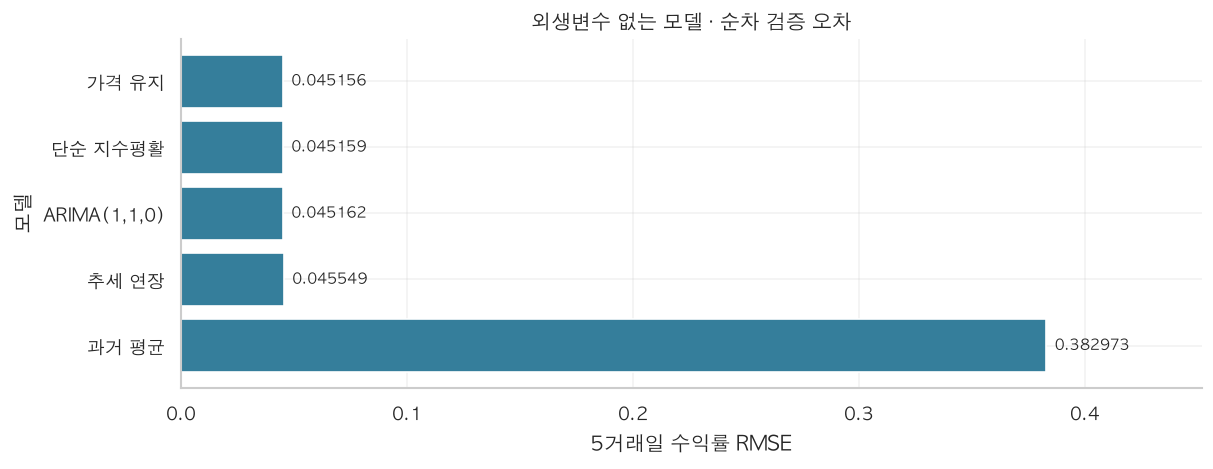

검증에서 고른 모델은 **가격 유지**다. 테스트 RMSE는 **0.054442**로 가격 유지 기준과 비교하면 같았다. 복잡한 모델을 더하기 전에 넘어야 할 기준으로 남겨 둔다. 앞의 CatBoost는 학습 이력과 갱신 방식이 달라 참고 비교다.

In [46]:
ts_final = ts_experiment.finalize_model(ts_created[ts_winner].pipeline).pipeline
positions = pd.Series(ts_prices.index, index=ts_prices.date)
last_seen = len(ts_dev) - 1
ts_test_pred = []
for row in test.itertuples():
    origin = int(positions.loc[row.date])
    target_position = int(positions.loc[row.target_date])
    assert target_position == origin + 5
    if origin > last_seen:
        ts_final.update(ts_y.iloc[last_seen + 1:origin + 1], update_params=False)
    forecast = ts_final.predict(fh=[5])
    assert int(forecast.index[0]) == target_position
    ts_test_pred.append(float(forecast.iloc[0] - ts_y.iloc[origin]))
    last_seen = origin

ts_test_pred = np.array(ts_test_pred)
ts_test_metrics = pd.DataFrame({
    "가격 유지 (기준)": return_metrics(test[TARGET], np.zeros(len(test))),
    f"PyCaret 선택 · {ts_winner}": return_metrics(test[TARGET], ts_test_pred),
    "전체 피처 CatBoost (참고)": return_metrics(test[TARGET], predictions["CatBoost"]),
}).T
display(ts_test_metrics.rename(columns=metric_labels).round(6).rename_axis("모델"))
fig, ax = plt.subplots(figsize=(10, 3.8), layout="constrained")
bars = ax.barh(ts_val_metrics.index[::-1], ts_val_metrics.RMSE.iloc[::-1], color="#357e9b")
ax.bar_label(bars, fmt="%.6f", padding=5, fontsize=9)
ax.set_xlim(0, ts_val_metrics.RMSE.max() * 1.18)
ax.set(title="외생변수 없는 모델 · 순차 검증 오차", xlabel="5거래일 수익률 RMSE", ylabel="모델")
plt.show()
if np.isclose(ts_test_metrics.iloc[1].RMSE, ts_test_metrics.iloc[0].RMSE):
    relation = "같았다"
else:
    relation = "낮았다" if ts_test_metrics.iloc[1].RMSE < ts_test_metrics.iloc[0].RMSE else "높았다"
display(Markdown(
    f"검증에서 고른 모델은 **{ts_winner}**다. 테스트 RMSE는 **{ts_test_metrics.iloc[1].RMSE:.6f}**로 가격 유지 기준과 비교하면 {relation}. "
    "복잡한 모델을 더하기 전에 넘어야 할 기준으로 남겨 둔다. 앞의 CatBoost는 학습 이력과 갱신 방식이 달라 참고 비교다."
))